<h1 style="color:red; text-align:center;">
TOPOLOGY-PRESERVING IMAGE SEGMENTATION WITH SPATIAL-AWARE PERSISTENT FEATURE MATCHING
</h1>

---

## **Project Overview**

This project investigates the segmentation of **road networks from satellite imagery**, with a focus not only on pixel-wise accuracy but also on preserving the **underlying topological structure** of roads.

Standard deep learning segmentation models often achieve high accuracy but fail to maintain structural integrity, leading to:

- Broken road segments  
- Missing connections  
- Incorrect loop formations  

To overcome these limitations, this work integrates **topological learning** into deep neural networks using a combination of classical loss functions and an advanced **Spatial-Aware Topological Loss (SATLoss)** based on **persistent homology**.

---

## **Objective**

The objective is to design a segmentation framework that:

- Accurately classifies road and background pixels  
- Preserves **connectivity (β₀)** of road networks  
- Maintains correct **loop structures (β₁)**  
- Produces outputs that are both **visually accurate and topologically consistent**

---

## **Methodology**

### **1. Deep Learning Backbone**

- A **U-Net architecture** is used as the core segmentation model  
- It follows an encoder–decoder structure:
  - The **encoder** extracts hierarchical features  
  - The **decoder** reconstructs spatial details  
- **Skip connections** ensure preservation of fine road structures and edges  

---

### **2. Data Processing**

- Input: RGB satellite images  
- Output: Binary segmentation masks  

Preprocessing steps include:

- Resizing images into **96×96 patches**  
- Normalizing pixel values  
- Converting masks to binary format (0: background, 1: road)  

---

### **3. Loss Functions (Hybrid Learning Framework)**

Four complementary losses are used:

---

#### **a. Binary Cross-Entropy (BCE) Loss**

- Handles pixel-wise classification  
- Encourages correct labeling of road vs background  

---

#### **b. Dice Loss**

- Measures overlap between prediction and ground truth  
- Effective for **class imbalance** (thin roads vs large background)  

---

#### **c. soft-clDice Loss**

- Skeleton-based loss  
- Preserves **local connectivity**  
- Prevents broken road segments  

---

### **d. SATLoss (Topology-Aware Loss)**

SATLoss introduces topology-aware supervision using persistent homology. Instead of evaluating only pixel overlap, it compares topological structures between the predicted probability map and the ground-truth mask.

In this work, each probability map is represented as a cubical complex. Persistent homology is then used to extract birth–death pairs that describe important topological structures in the segmentation.

Each topological feature contains:

- **Creator location**: the pixel where a topological feature appears
- **Destroyer location**: the pixel where the feature disappears
- **Persistence value**: the strength or importance of the feature

---

### **Spatial-Aware Persistent Feature Matching**

The SATLoss formulation uses spatial-aware matching so that topological features are compared not only by their persistence values, but also by their locations in the image.

This is important for road segmentation because two road junctions may have similar persistence values but occur in different spatial locations. Spatial-aware matching helps the model preserve road structures at the correct positions.

---

### **SATLoss Variants Investigated**

This project evaluates two SATLoss variants:

#### **1. SATLoss with Creators Only**

This version focuses on matching creator features between prediction and ground truth. It encourages the model to recover missing road structures and maintain connected components.

#### **2. SATLoss with Creators + Destroyers**

This version includes both creator and destroyer information. It was investigated to test whether removing unmatched or noisy topological features could further improve topology preservation.

However, the Creator-Destroyer variant produced stronger numerical metrics but showed unstable blob-like artifacts in some complex visual predictions. Therefore, the **Hybrid + SATLoss Creator model** was selected as the most reliable model for transfer learning because it provided the best balance between quantitative performance and stable visual road structure.

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [3]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
#!{sys.executable} -m pip install torch==2.2.0+cu118 torchvision==0.17.0+cu118 --index-url https://download.pytorch.org/whl/cu118 -q

In [5]:
# ============================================================
# STEP 1: Install libraries, import packages, and set settings
# ============================================================
# This step prepares the full environment for all experiments:
# BCE only, BCE + SATLoss, Hybrid + SATLoss, and Creator-Destroyer SATLoss.
# We also fix random seeds so that the experiments are reproducible.
# ============================================================

!pip install gudhi -q

import os
import random
import zipfile
import copy
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import gudhi
from scipy.optimize import linear_sum_assignment
from skimage.morphology import skeletonize
from skimage.measure import label
from scipy.ndimage import binary_fill_holes

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Main experiment settings
# ----------------------------
PATCH_SIZE = 96
BATCH_SIZE = 8

# ----------------------------
# Output folders
# ----------------------------
SAVE_DIR = "final_thesis_models"
RESULTS_DIR = "final_thesis_results"
FIGURE_DIR = "final_thesis_figures"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Gudhi version:", gudhi.__version__)
print("Device:", device)
print("Patch size:", PATCH_SIZE)
print("Batch size:", BATCH_SIZE)
print("Model folder:", SAVE_DIR)
print("Results folder:", RESULTS_DIR)
print("Figures folder:", FIGURE_DIR)


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Gudhi version: 3.12.0
Device: cuda
Patch size: 96
Batch size: 8
Model folder: final_thesis_models
Results folder: final_thesis_results
Figures folder: final_thesis_figures


In [6]:
# ============================================================
# STEP 2: Download Roads dataset from Google Drive
# ============================================================
# This step downloads the Roads dataset zip file.
# We download only once. If the zip file already exists, the code skips downloading.
# ============================================================

import sys
!{sys.executable} -m pip install gdown -q

import gdown
import os

# ----------------------------
# Google Drive file information
# ----------------------------
file_id = "1koyNkQvWfj-SfMC3KlG5koXbhoPAcTwg"
url = f"https://drive.google.com/uc?id={file_id}"

zip_path = "road_dataset.zip"

# ----------------------------
# Download dataset
# ----------------------------
if not os.path.exists(zip_path):
    print("Downloading Roads dataset...")
    gdown.download(url, zip_path, quiet=False)
else:
    print("Dataset zip already exists:", zip_path)

# ----------------------------
# Check downloaded file
# ----------------------------
if os.path.exists(zip_path):
    zip_size_gb = os.path.getsize(zip_path) / (1024 ** 3)

    print("Zip exists:", True)
    print(f"Zip size: {zip_size_gb:.3f} GB")
else:
    raise FileNotFoundError("Dataset zip was not downloaded correctly.")

Dataset zip already exists: road_dataset.zip
Zip exists: True
Zip size: 5.764 GB


In [7]:
# ============================================================
# STEP 3: Extract dataset and inspect folders
# ============================================================
# This step extracts the Roads dataset and checks that the expected folders exist.
# We extract only once. If the tiff folder already exists, extraction is skipped.
# ============================================================

import os
import zipfile

extract_dir = "."
base_dir = "tiff"

# ----------------------------
# Extract dataset
# ----------------------------
if not os.path.exists(base_dir):
    print("Extracting Roads dataset...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    print("Extraction finished.")
else:
    print("Dataset already extracted.")

# ----------------------------
# Inspect extracted folders
# ----------------------------
if not os.path.exists(base_dir):
    raise FileNotFoundError("The 'tiff' folder was not found after extraction.")

folders = sorted(os.listdir(base_dir))

print("Base directory exists:", os.path.exists(base_dir))
print("Folders inside tiff:", folders)

# ----------------------------
# Expected folder structure
# ----------------------------
expected_folders = [
    "train",
    "train_labels",
    "val",
    "val_labels",
    "test",
    "test_labels"
]

missing_folders = [
    folder for folder in expected_folders
    if folder not in folders
]

if len(missing_folders) == 0:
    print("All expected folders are available.")
else:
    print("Missing folders:", missing_folders)

Dataset already extracted.
Base directory exists: True
Folders inside tiff: ['test', 'test_labels', 'train', 'train_labels', 'val', 'val_labels']
All expected folders are available.


In [8]:
# ============================================================
# STEP 4: Create image-mask pairs and make a new image-level split
# ============================================================
# This step creates image-mask pairs safely using file names.
#
# Important:
# We split at the full-image level, not at the patch level.
# This avoids data leakage, because patches from the same full image
# must not appear in both training and testing.
#
# Original dataset split:
#     train / val / test
#
# Final thesis split:
#     We combine all original pairs and create a new 70/15/15 split.
#     After this split, patches will be extracted separately from each group.
# ============================================================

base_dir = "tiff"

train_img_dir = os.path.join(base_dir, "train")
train_mask_dir = os.path.join(base_dir, "train_labels")

val_img_dir = os.path.join(base_dir, "val")
val_mask_dir = os.path.join(base_dir, "val_labels")

test_img_dir = os.path.join(base_dir, "test")
test_mask_dir = os.path.join(base_dir, "test_labels")


def create_pairs_by_stem(img_dir, mask_dir):
    """
    Create image-mask pairs by matching file stems.

    Example:
        image: area_1.tiff
        mask : area_1.tif

    Returns:
        pairs   : list of (image_path, mask_path)
        missing : image files without matching masks
    """

    image_files = sorted([
        f for f in os.listdir(img_dir)
        if f.lower().endswith(".tiff")
    ])

    mask_files = sorted([
        f for f in os.listdir(mask_dir)
        if f.lower().endswith(".tif")
    ])

    mask_dict = {
        os.path.splitext(mask_name)[0]: os.path.join(mask_dir, mask_name)
        for mask_name in mask_files
    }

    pairs = []
    missing = []

    for img_name in image_files:
        stem = os.path.splitext(img_name)[0]
        img_path = os.path.join(img_dir, img_name)

        if stem in mask_dict:
            pairs.append((img_path, mask_dict[stem]))
        else:
            missing.append(img_name)

    return pairs, missing


# ----------------------------
# Create pairs from original folders
# ----------------------------
original_train_pairs, train_missing = create_pairs_by_stem(train_img_dir, train_mask_dir)
original_val_pairs, val_missing = create_pairs_by_stem(val_img_dir, val_mask_dir)
original_test_pairs, test_missing = create_pairs_by_stem(test_img_dir, test_mask_dir)

print("Original split")
print("--------------")
print("Train pairs:", len(original_train_pairs), "Missing:", len(train_missing))
print("Val pairs  :", len(original_val_pairs), "Missing:", len(val_missing))
print("Test pairs :", len(original_test_pairs), "Missing:", len(test_missing))

# Stop if any image has no mask
total_missing = len(train_missing) + len(val_missing) + len(test_missing)

if total_missing > 0:
    raise ValueError("Some images do not have matching masks. Check missing lists before continuing.")

# ----------------------------
# Combine all pairs before re-splitting
# ----------------------------
all_pairs = original_train_pairs + original_val_pairs + original_test_pairs

print("\nTotal full image-mask pairs:", len(all_pairs))

# ----------------------------
# New image-level split: 70% train, 15% validation, 15% test
# ----------------------------
random.seed(SEED)
random.shuffle(all_pairs)

n_total = len(all_pairs)

n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_pairs = all_pairs[:n_train]
val_pairs = all_pairs[n_train:n_train + n_val]
test_pairs = all_pairs[n_train + n_val:]

print("\nNew thesis split")
print("----------------")
print("Train pairs:", len(train_pairs))
print("Val pairs  :", len(val_pairs))
print("Test pairs :", len(test_pairs))

print("\nSplit percentages")
print("-----------------")
print(f"Train: {100 * len(train_pairs) / n_total:.2f}%")
print(f"Val  : {100 * len(val_pairs) / n_total:.2f}%")
print(f"Test : {100 * len(test_pairs) / n_total:.2f}%")

print("\nExample new training pair:")
print(train_pairs[0])

Original split
--------------
Train pairs: 1108 Missing: 0
Val pairs  : 14 Missing: 0
Test pairs : 49 Missing: 0

Total full image-mask pairs: 1171

New thesis split
----------------
Train pairs: 819
Val pairs  : 175
Test pairs : 177

Split percentages
-----------------
Train: 69.94%
Val  : 14.94%
Test : 15.12%

Example new training pair:
('tiff/train/23428525_15.tiff', 'tiff/train_labels/23428525_15.tif')


Image file: 23428525_15.tiff
Mask file : 23428525_15.tif
Image path: tiff/train/23428525_15.tiff
Mask path : tiff/train_labels/23428525_15.tif
Image shape: (1500, 1500, 3)
Mask shape : (1500, 1500)
Original mask unique values: [  0 255]
Binary mask unique values: [0 1]
Road pixel ratio: 0.066794


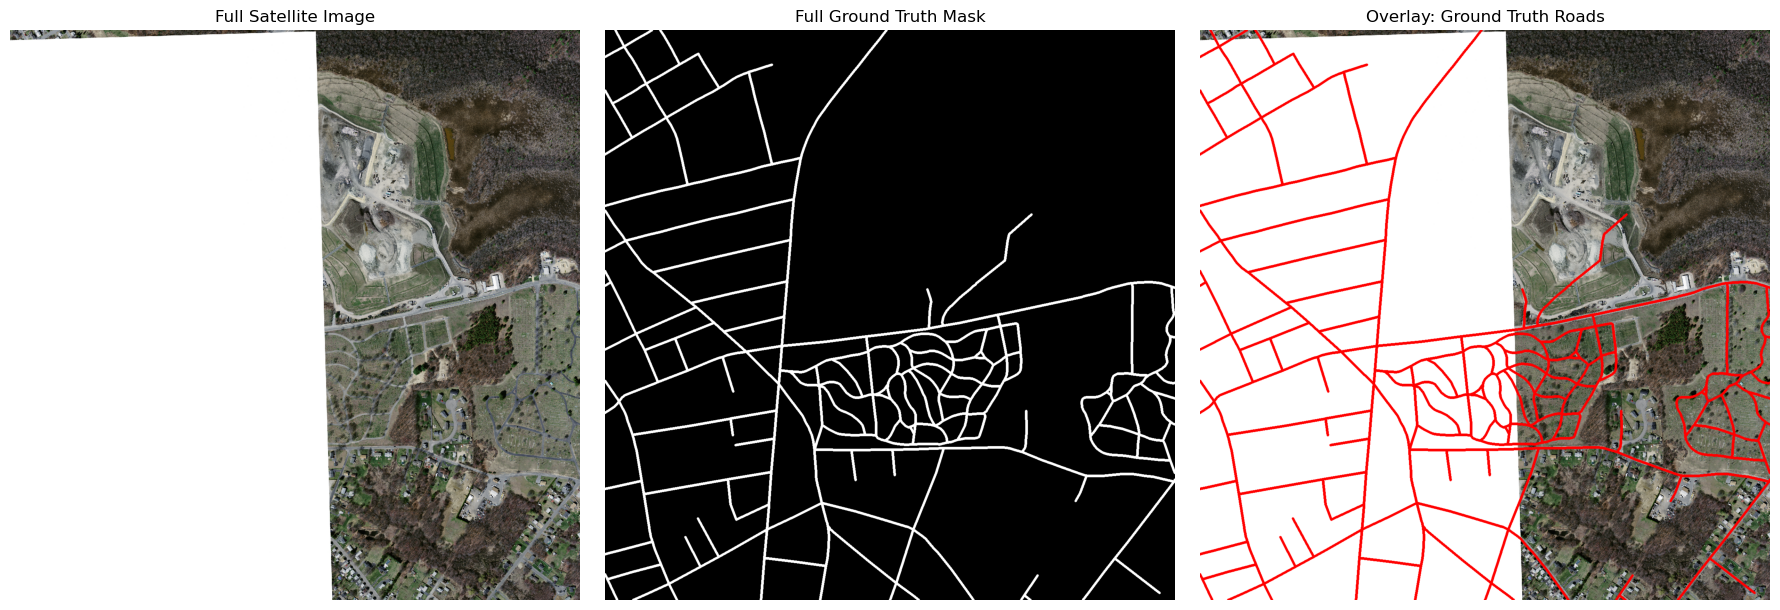

Saved figure: final_thesis_figures/step5_full_image_mask_overlay.png


In [9]:
# ============================================================
# STEP 5: Visualize full image, full mask, and overlay
# ============================================================
# This step checks whether image-mask pairs are correctly matched.
#
# We visualize:
#   1. Full satellite image
#   2. Full binary ground-truth road mask
#   3. Overlay of mask on image
#
# Red overlay = true road pixels.
#
# If the red mask lies on actual roads, then the image and mask are aligned.
# This step is only for dataset verification. It does not train the model.
# ============================================================

# ----------------------------
# Choose one image from the new training split
# ----------------------------
sample_index = 0
img_path, mask_path = train_pairs[sample_index]

# ----------------------------
# Load full image and full mask
# ----------------------------
image = np.array(Image.open(img_path).convert("RGB"))
mask = np.array(Image.open(mask_path).convert("L"))

# ----------------------------
# Convert mask to binary
# ----------------------------
# Original mask usually contains values 0 and 255.
# We convert it to:
#   0 = background
#   1 = road
mask_binary = (mask > 0).astype(np.uint8)

# Normalize image for display
image_display = image.astype(np.float32) / 255.0

# ----------------------------
# Create overlay
# ----------------------------
overlay = image_display.copy()
overlay[mask_binary == 1] = [1, 0, 0]

# ----------------------------
# Print useful information
# ----------------------------
print("Image file:", os.path.basename(img_path))
print("Mask file :", os.path.basename(mask_path))
print("Image path:", img_path)
print("Mask path :", mask_path)
print("Image shape:", image.shape)
print("Mask shape :", mask.shape)
print("Original mask unique values:", np.unique(mask))
print("Binary mask unique values:", np.unique(mask_binary))
print(f"Road pixel ratio: {mask_binary.mean():.6f}")

# ----------------------------
# Visualize image, mask, and overlay
# ----------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_display)
plt.title("Full Satellite Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_binary, cmap="gray")
plt.title("Full Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay: Ground Truth Roads")
plt.axis("off")

plt.tight_layout()

# Save figure for thesis documentation
save_path = os.path.join(FIGURE_DIR, "step5_full_image_mask_overlay.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure:", save_path)

In [10]:
# ============================================================
# STEP 6: Extract 96x96 patches and filter useful patches
# ============================================================
# This step cuts each full 1500x1500 image into smaller 96x96 patches.
#
# Important:
# We use overlapping patches with stride 48.
# This is useful for road segmentation because roads often cross patch borders.
# Overlap gives the model more examples of road continuity and intersections.
#
# Filtering:
# Roads occupy a small percentage of pixels, so we keep:
#   1. all patches with enough road pixels
#   2. a small percentage of almost-empty background patches
#
# This prevents the model from learning only background.
# ============================================================

MIN_ROAD_RATIO = 0.02       # keep patches with at least 2% road pixels
EMPTY_KEEP_RATIO = 0.05     # keep 5% of mostly empty patches
STRIDE = PATCH_SIZE // 2    # 48 for 96x96 patches


def extract_filtered_patches(
    pairs,
    patch_size=96,
    stride=48,
    min_road_ratio=0.02,
    empty_keep_ratio=0.05,
    split_name="train"
):
    """
    Extract filtered image-mask patches from full-size road images.

    Parameters
    ----------
    pairs:
        List of (image_path, mask_path).

    patch_size:
        Size of each square patch.

    stride:
        Step size for sliding window.
        stride < patch_size gives overlapping patches.

    min_road_ratio:
        Minimum fraction of road pixels required to keep a road patch.

    empty_keep_ratio:
        Probability of keeping a mostly background patch.

    split_name:
        Name of the split, used only for progress display.

    Returns
    -------
    patches:
        List of dictionaries. Each dictionary stores:
            image_patch : RGB image patch
            mask_patch  : binary road mask patch
            road_ratio  : fraction of road pixels
            image_path   : source full image path
            mask_path    : source mask path
            top, left    : patch location in the full image
    """

    patches = []
    kept_road = 0
    kept_empty = 0
    total_candidates = 0

    for img_path, mask_path in tqdm(pairs, desc=f"Extracting {split_name} patches"):
        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))

        # Convert mask from {0,255} to {0,1}
        mask = (mask > 0).astype(np.float32)

        H, W = image.shape[:2]

        for top in range(0, H - patch_size + 1, stride):
            for left in range(0, W - patch_size + 1, stride):

                total_candidates += 1

                image_patch = image[
                    top:top + patch_size,
                    left:left + patch_size
                ]

                mask_patch = mask[
                    top:top + patch_size,
                    left:left + patch_size
                ]

                road_ratio = float(mask_patch.mean())

                keep_patch = False
                patch_type = None

                # Keep patches with enough road pixels
                if road_ratio >= min_road_ratio:
                    keep_patch = True
                    patch_type = "road"
                    kept_road += 1

                # Keep a small number of mostly background patches
                elif random.random() < empty_keep_ratio:
                    keep_patch = True
                    patch_type = "background"
                    kept_empty += 1

                if keep_patch:
                    patches.append({
                        "image_patch": image_patch,
                        "mask_patch": mask_patch,
                        "road_ratio": road_ratio,
                        "patch_type": patch_type,
                        "image_path": img_path,
                        "mask_path": mask_path,
                        "top": top,
                        "left": left
                    })

    print(f"\n{split_name.upper()} PATCH SUMMARY")
    print("-" * 40)
    print("Full images          :", len(pairs))
    print("Candidate patches    :", total_candidates)
    print("Kept road patches    :", kept_road)
    print("Kept background      :", kept_empty)
    print("Total kept patches   :", len(patches))

    if len(patches) > 0:
        ratios = [p["road_ratio"] for p in patches]
        print(f"Mean road ratio      : {np.mean(ratios):.4f}")
        print(f"Max road ratio       : {np.max(ratios):.4f}")
        print(f"Min road ratio       : {np.min(ratios):.4f}")

    return patches


# ----------------------------
# Extract patches from the new image-level split
# ----------------------------
train_patches = extract_filtered_patches(
    train_pairs,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    min_road_ratio=MIN_ROAD_RATIO,
    empty_keep_ratio=EMPTY_KEEP_RATIO,
    split_name="train"
)

val_patches = extract_filtered_patches(
    val_pairs,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    min_road_ratio=MIN_ROAD_RATIO,
    empty_keep_ratio=EMPTY_KEEP_RATIO,
    split_name="validation"
)

test_patches = extract_filtered_patches(
    test_pairs,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    min_road_ratio=MIN_ROAD_RATIO,
    empty_keep_ratio=EMPTY_KEEP_RATIO,
    split_name="test"
)

print("\nFINAL PATCH COUNTS")
print("------------------")
print("Train patches     :", len(train_patches))
print("Validation patches:", len(val_patches))
print("Test patches      :", len(test_patches))

Extracting train patches: 100%|██████████| 819/819 [00:36<00:00, 22.25it/s]



TRAIN PATCH SUMMARY
----------------------------------------
Full images          : 819
Candidate patches    : 737100
Kept road patches    : 363360
Kept background      : 18553
Total kept patches   : 381913
Mean road ratio      : 0.0924
Max road ratio       : 0.6927
Min road ratio       : 0.0000


Extracting validation patches: 100%|██████████| 175/175 [00:09<00:00, 17.73it/s]



VALIDATION PATCH SUMMARY
----------------------------------------
Full images          : 175
Candidate patches    : 157500
Kept road patches    : 75264
Kept background      : 4052
Total kept patches   : 79316
Mean road ratio      : 0.0916
Max road ratio       : 0.5814
Min road ratio       : 0.0000


Extracting test patches: 100%|██████████| 177/177 [00:09<00:00, 18.42it/s]


TEST PATCH SUMMARY
----------------------------------------
Full images          : 177
Candidate patches    : 159300
Kept road patches    : 77842
Kept background      : 4065
Total kept patches   : 81907
Mean road ratio      : 0.0916
Max road ratio       : 0.6184
Min road ratio       : 0.0000

FINAL PATCH COUNTS
------------------
Train patches     : 381913
Validation patches: 79316
Test patches      : 81907


In [11]:
# ============================================================
# STEP 7: Limit patch numbers for practical training
# ============================================================
# The full extracted patch set can be very large.
# To make training practical, we select a fixed number of patches.
#
# Important:
# The split was already done at image level before patch extraction.
# Therefore, reducing the number of patches here does not cause leakage.
#
# For thesis experiments, we use the same patch limits for all models
# so that model comparisons are fair.
# ============================================================

MAX_TRAIN = 30000
MAX_VAL = 5000
MAX_TEST = 5000

# If GPU memory
# MAX_TRAIN = 20000
# MAX_VAL = 3000
# MAX_TEST = 3000

random.seed(SEED)

random.shuffle(train_patches)
random.shuffle(val_patches)
random.shuffle(test_patches)

train_patches = train_patches[:min(MAX_TRAIN, len(train_patches))]
val_patches = val_patches[:min(MAX_VAL, len(val_patches))]
test_patches = test_patches[:min(MAX_TEST, len(test_patches))]

print("Final selected patches")
print("----------------------")
print("Train patches     :", len(train_patches))
print("Validation patches:", len(val_patches))
print("Test patches      :", len(test_patches))

# Check road ratio after selection
def summarize_selected_patches(patches, name):
    ratios = [p["road_ratio"] for p in patches]

    print(f"\n{name} patch summary")
    print("-" * 30)
    print("Number of patches:", len(patches))
    print(f"Mean road ratio  : {np.mean(ratios):.4f}")
    print(f"Min road ratio   : {np.min(ratios):.4f}")
    print(f"Max road ratio   : {np.max(ratios):.4f}")

summarize_selected_patches(train_patches, "Train")
summarize_selected_patches(val_patches, "Validation")
summarize_selected_patches(test_patches, "Test")

Final selected patches
----------------------
Train patches     : 30000
Validation patches: 5000
Test patches      : 5000

Train patch summary
------------------------------
Number of patches: 30000
Mean road ratio  : 0.0932
Min road ratio   : 0.0000
Max road ratio   : 0.5780

Validation patch summary
------------------------------
Number of patches: 5000
Mean road ratio  : 0.0916
Min road ratio   : 0.0000
Max road ratio   : 0.4169

Test patch summary
------------------------------
Number of patches: 5000
Mean road ratio  : 0.0903
Min road ratio   : 0.0000
Max road ratio   : 0.4555


Patch 1
Source image: 23278945_15.tiff
Patch location: top = 1344 , left = 528
Image min: 1
Image max: 186
Image mean: 74.76012731481481
Road ratio: 15.77%
----------------------------------------
Patch 2
Source image: 10978810_15.tiff
Patch location: top = 96 , left = 288
Image min: 23
Image max: 237
Image mean: 91.53005642361111
Road ratio: 8.11%
----------------------------------------
Patch 3
Source image: 19978915_15.tiff
Patch location: top = 816 , left = 0
Image min: 0
Image max: 246
Image mean: 95.81973379629629
Road ratio: 10.99%
----------------------------------------
Patch 4
Source image: 10978735_15.tiff
Patch location: top = 1392 , left = 1008
Image min: 0
Image max: 255
Image mean: 107.68283420138889
Road ratio: 11.08%
----------------------------------------
Patch 5
Source image: 25079230_15.tiff
Patch location: top = 240 , left = 1344
Image min: 0
Image max: 241
Image mean: 87.98111979166667
Road ratio: 13.60%
----------------------------------------
Patch 6
Source ima

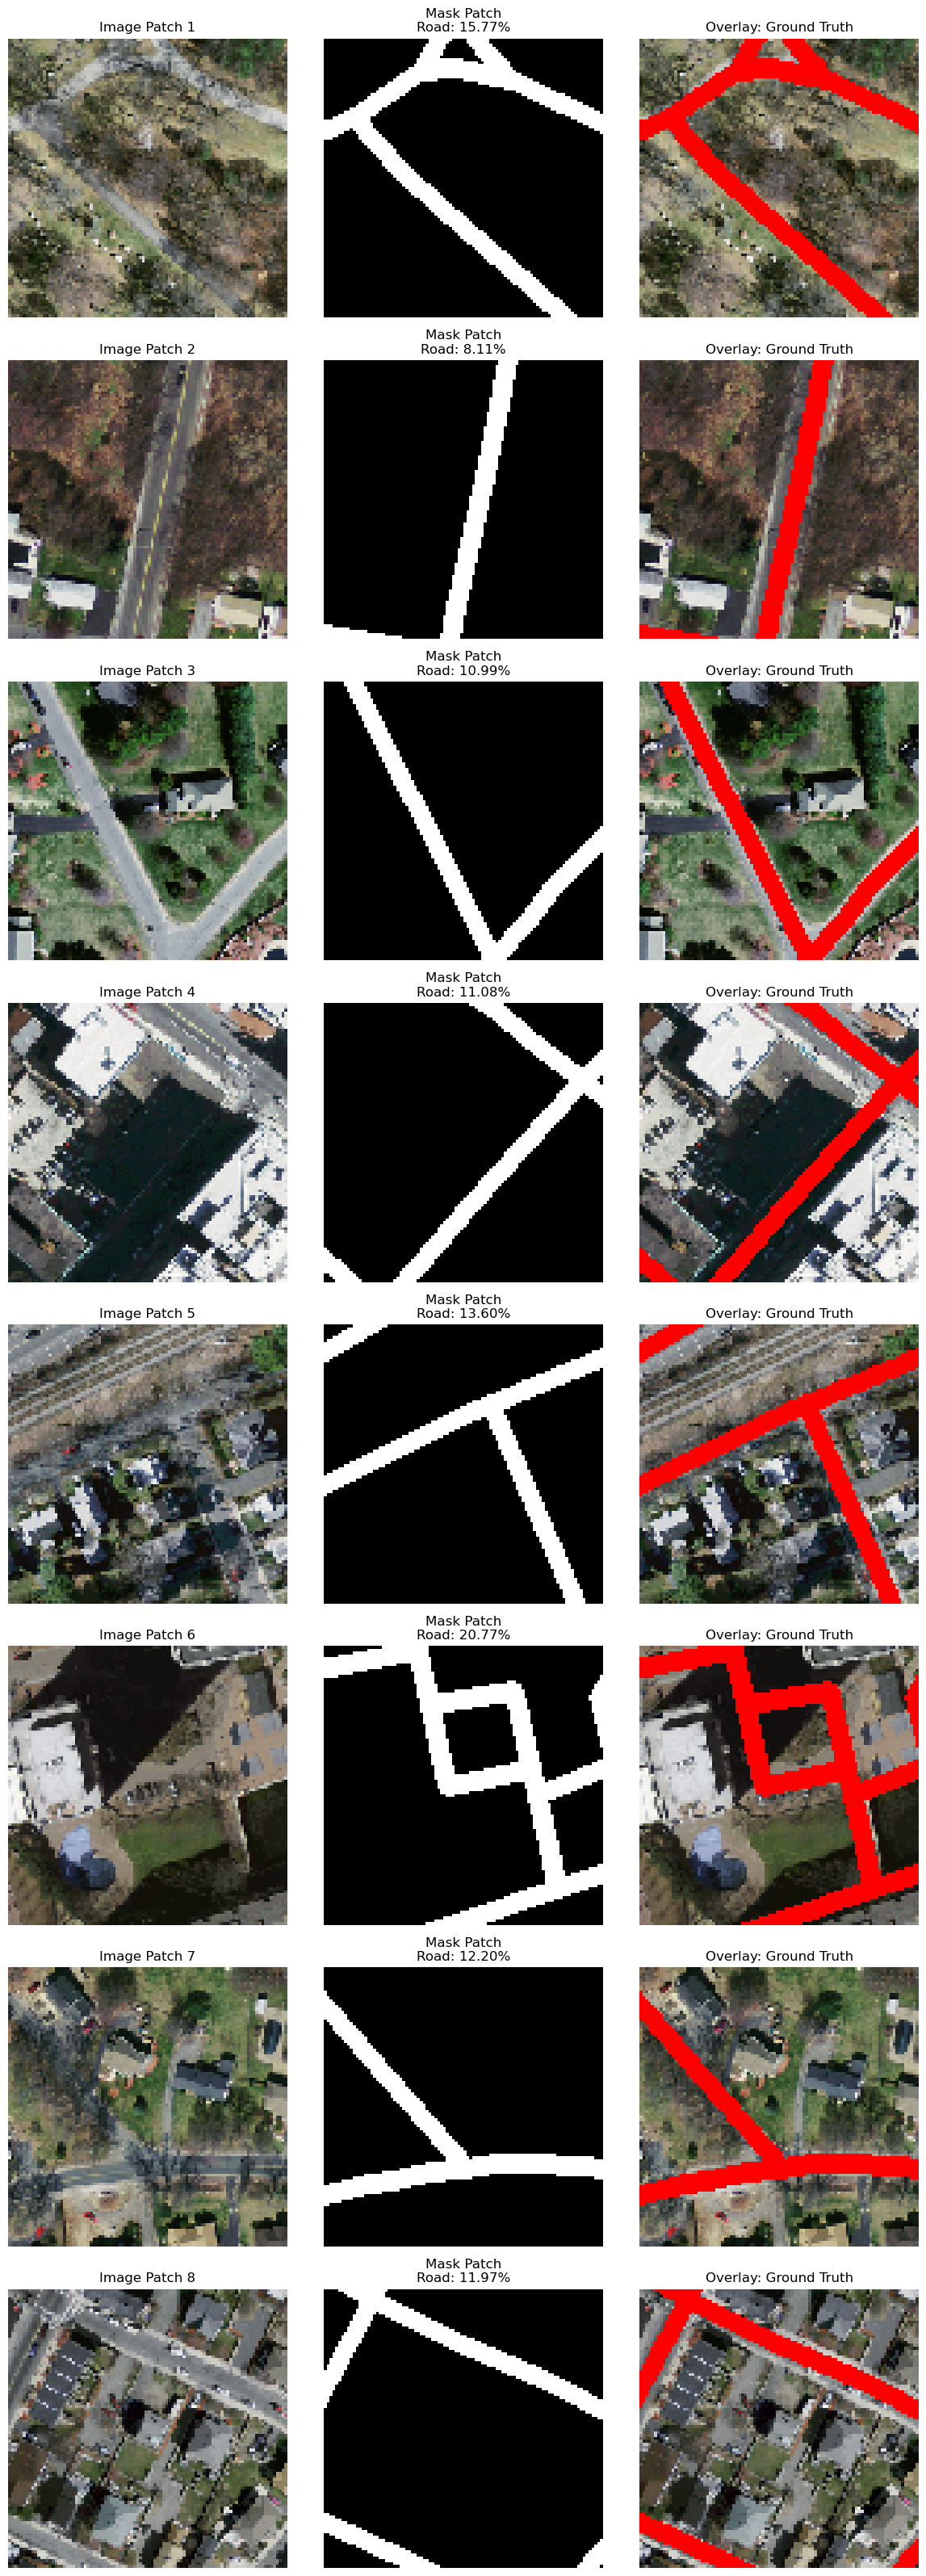

Saved figure: final_thesis_figures/step8_selected_complex_patches.png


In [12]:
# ============================================================
# STEP 8: Visualize selected patches, masks, and overlays
# ============================================================
# This step checks whether the extracted 96x96 patches are correct.
#
# We visualize:
#   1. Image patch
#   2. Ground-truth mask patch
#   3. Overlay of mask on image patch
#
# Red overlay = true road pixels.
#
# Some image patches may be dark or low contrast.
# The function enhance_for_display improves visibility only for plotting.
# It does not change the training data.
# ============================================================

def enhance_for_display(img):
    """
    Improve image visibility for plotting only.

    This rescales pixel values inside one patch to [0, 1].
    It does not affect the data used for training.
    """

    img = img.astype(np.float32)

    min_val = img.min()
    max_val = img.max()

    if max_val > min_val:
        img = (img - min_val) / (max_val - min_val)
    else:
        img = np.zeros_like(img)

    return img


# ----------------------------
# Select patches with relatively complex road structures
# ----------------------------
# We prefer patches with enough road pixels so the visualization is meaningful.
complex_indices = [
    i for i, p in enumerate(train_patches)
    if p["road_ratio"] >= 0.08
]

num_samples = min(8, len(complex_indices))

if num_samples == 0:
    sample_indices = random.sample(range(len(train_patches)), min(8, len(train_patches)))
else:
    sample_indices = random.sample(complex_indices, num_samples)

plt.figure(figsize=(12, 4 * num_samples))

for row, idx in enumerate(sample_indices):
    patch = train_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]
    road_ratio = patch["road_ratio"] * 100

    image_display = enhance_for_display(image_patch)

    overlay = image_display.copy()
    overlay[mask_patch == 1] = [1, 0, 0]

    print(f"Patch {row + 1}")
    print("Source image:", os.path.basename(patch["image_path"]))
    print("Patch location: top =", patch["top"], ", left =", patch["left"])
    print("Image min:", image_patch.min())
    print("Image max:", image_patch.max())
    print("Image mean:", image_patch.mean())
    print(f"Road ratio: {road_ratio:.2f}%")
    print("-" * 40)

    plt.subplot(num_samples, 3, 3 * row + 1)
    plt.imshow(image_display)
    plt.title(f"Image Patch {row + 1}")
    plt.axis("off")

    plt.subplot(num_samples, 3, 3 * row + 2)
    plt.imshow(mask_patch, cmap="gray")
    plt.title(f"Mask Patch\nRoad: {road_ratio:.2f}%")
    plt.axis("off")

    plt.subplot(num_samples, 3, 3 * row + 3)
    plt.imshow(overlay)
    plt.title("Overlay: Ground Truth")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(FIGURE_DIR, "step8_selected_complex_patches.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure:", save_path)

In [13]:
# ============================================================
# STEP 9: Create PyTorch Dataset and DataLoaders
# ============================================================
# This step converts selected image-mask patches into PyTorch tensors.
#
# Input patch format:
#   image_patch: [96, 96, 3]
#   mask_patch : [96, 96]
#
# Output tensor format:
#   image_tensor: [3, 96, 96]
#   mask_tensor : [1, 96, 96]
#
# The image is normalized from [0,255] to [0,1].
# The mask remains binary: 0 = background, 1 = road.
# ============================================================

class RoadsPatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch = self.patches[idx]

        image_patch = patch["image_patch"]
        mask_patch = patch["mask_patch"]

        image_patch = image_patch.astype(np.float32) / 255.0
        mask_patch = mask_patch.astype(np.float32)

        image_tensor = torch.from_numpy(image_patch).permute(2, 0, 1)
        mask_tensor = torch.from_numpy(mask_patch).unsqueeze(0)

        return image_tensor, mask_tensor


# ----------------------------
# Create dataset objects
# ----------------------------
train_dataset = RoadsPatchDataset(train_patches)
val_dataset = RoadsPatchDataset(val_patches)
test_dataset = RoadsPatchDataset(test_patches)

# ----------------------------
# Create DataLoaders
# ----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# ----------------------------
# Check one batch
# ----------------------------
images, masks = next(iter(train_loader))

print("Train dataset size     :", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size      :", len(test_dataset))

print("\nTrain batches     :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches      :", len(test_loader))

print("\nImage batch shape:", images.shape)
print("Mask batch shape :", masks.shape)

print("\nImage min:", images.min().item())
print("Image max:", images.max().item())
print("Mask unique values:", torch.unique(masks))
print("Batch road ratio:", masks.mean().item())

Train dataset size     : 30000
Validation dataset size: 5000
Test dataset size      : 5000

Train batches     : 3750
Validation batches: 625
Test batches      : 625

Image batch shape: torch.Size([8, 3, 96, 96])
Mask batch shape : torch.Size([8, 1, 96, 96])

Image min: 0.0
Image max: 1.0
Mask unique values: tensor([0., 1.])
Batch road ratio: 0.0893419086933136


In [14]:
# ============================================================
# STEP 10: Define U-Net model and test one forward pass
# ============================================================
# This step defines the U-Net model for binary segmentation.
#
# Input:
#   [B, 3, 96, 96]
#
# Output:
#   [B, 1, 96, 96]
#
# The model outputs raw logits.
# Sigmoid is applied later during evaluation or prediction.
# ============================================================

import gc
import torch
import torch.nn as nn

# ----------------------------
# Safe device selection
# ----------------------------
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Number of GPUs visible to PyTorch:", num_gpus)

    for i in range(num_gpus):
        print(f"cuda:{i} -> {torch.cuda.get_device_name(i)}")

    # Use cuda:2 only if PyTorch can see it.
    # Otherwise use cuda:0, which may already represent the assigned GPU.
    if num_gpus > 2:
        device = torch.device("cuda:2")
    else:
        device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

print("Using device:", device)


# ----------------------------
# U-Net convolution block
# ----------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


# ----------------------------
# U-Net model
# ----------------------------
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )
        self.conv1 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        c4 = self.down4(p3)
        p4 = self.pool4(c4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv4(u4)

        u3 = self.up3(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv3(u3)

        u2 = self.up2(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv2(u2)

        u1 = self.up1(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv1(u1)

        return self.final_conv(c8)


# ----------------------------
# Forward-pass check
# ----------------------------
test_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

test_model.eval()

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = test_model(images)

print("Input image shape :", images.shape)
print("Output logits shape:", logits.shape)
print("Expected mask shape:", masks.shape)

assert logits.shape == masks.shape, "Model output shape does not match mask shape."

num_params = sum(
    p.numel()
    for p in test_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", num_params)


# ----------------------------
# Remove only local test objects
# ----------------------------
del test_model
del images
del masks
del logits

gc.collect()

print("Step 10 completed successfully.")

Number of GPUs visible to PyTorch: 1
cuda:0 -> NVIDIA GeForce RTX 3090
Using device: cuda:0
Input image shape : torch.Size([8, 3, 96, 96])
Output logits shape: torch.Size([8, 1, 96, 96])
Expected mask shape: torch.Size([8, 1, 96, 96])
Trainable parameters: 31037633
Step 10 completed successfully.


In [15]:
# ============================================================
# STEP 11: Define losses, learnable threshold, and metrics
# ============================================================
# This step defines all losses and evaluation metrics used in the thesis.
#
# Training losses:
#   1. BCE loss
#   2. Dice loss
#   3. soft-clDice loss
#   4. threshold Dice loss
#
# Evaluation metrics:
#   1. BCE loss
#   2. Accuracy
#   3. Dice
#   4. clDice
#   5. beta0 error
#   6. beta1 error
#
# Important:
# During training, the threshold is learned using a differentiable soft threshold.
# During validation/testing, we use the learned threshold as a hard threshold.
# ============================================================

# ----------------------------
# BCE loss
# ----------------------------
bce_loss_fn = nn.BCEWithLogitsLoss()


# ----------------------------
# Learnable threshold
# ----------------------------
class LearnableThreshold(nn.Module):
    """
    Learn a global threshold instead of using a fixed threshold such as 0.5.

    The threshold is parametrized using a logit value.
    This keeps the threshold inside the interval (0, 1).
    """

    def __init__(self, init_value=0.5):
        super().__init__()

        init_value = torch.tensor(init_value, dtype=torch.float32)
        init_logit = torch.log(init_value / (1.0 - init_value))

        self.threshold_logit = nn.Parameter(init_logit)

    def forward(self):
        return torch.sigmoid(self.threshold_logit)


def soft_threshold_prediction(probs, threshold_module, sharpness=20.0):
    """
    Differentiable approximation of hard thresholding.

    Hard threshold:
        pred = probs > threshold

    Soft threshold:
        pred_soft = sigmoid(k * (probs - threshold))

    A larger sharpness value makes the soft threshold closer to a hard threshold.
    """

    threshold = threshold_module()
    soft_preds = torch.sigmoid(sharpness * (probs - threshold))

    return soft_preds


def threshold_dice_loss(probs, masks, threshold_module, sharpness=20.0, eps=1e-8):
    """
    Dice loss after soft thresholding.

    This allows the threshold parameter to receive gradients during training.
    """

    soft_preds = soft_threshold_prediction(
        probs,
        threshold_module,
        sharpness=sharpness
    )

    intersection = (soft_preds * masks).sum(dim=(1, 2, 3))
    union = soft_preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)

    return 1.0 - dice.mean()


# ----------------------------
# Dice loss and Dice score
# ----------------------------
def dice_loss(probs, targets, eps=1e-8):
    """
    Differentiable Dice loss computed on probability maps.
    Used during training.
    """

    probs = probs.float()
    targets = targets.float()

    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)

    return 1.0 - dice.mean()


def dice_score(preds, targets, eps=1e-8):
    """
    Dice score computed on binary predictions.
    Used during validation and testing.
    """

    preds = preds.float()
    targets = targets.float()

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()

    dice = (2.0 * intersection + eps) / (union + eps)

    return dice.item()


# ----------------------------
# Pixel accuracy
# ----------------------------
def accuracy_score(preds, targets):
    """
    Pixel-wise accuracy.
    This can be high even when roads are broken because background dominates.
    """

    correct = (preds == targets).float().sum()
    total = torch.numel(targets)

    return (correct / total).item()


# ----------------------------
# soft-clDice loss
# ----------------------------
CLDICE_ITERATIONS = 3

def soft_erode(img):
    p1 = -F.max_pool2d(
        -img,
        kernel_size=(3, 1),
        stride=1,
        padding=(1, 0)
    )

    p2 = -F.max_pool2d(
        -img,
        kernel_size=(1, 3),
        stride=1,
        padding=(0, 1)
    )

    return torch.min(p1, p2)


def soft_dilate(img):
    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):
    return soft_dilate(soft_erode(img))


def soft_skeletonize(img, iterations=3):
    """
    Differentiable skeleton approximation.
    Used for soft-clDice training loss.
    """

    img = img.float()

    opened = soft_open(img)
    skeleton = F.relu(img - opened)

    for _ in range(iterations):
        img = soft_erode(img)
        opened = soft_open(img)

        delta = F.relu(img - opened)
        skeleton = skeleton + F.relu(delta - skeleton * delta)

    return skeleton


def soft_cldice_loss(probs, targets, iterations=3, eps=1e-8):
    """
    Differentiable clDice loss.
    This encourages road centerline connectivity during training.
    """

    probs = probs.float()
    targets = targets.float()

    skel_pred = soft_skeletonize(probs, iterations=iterations)
    skel_true = soft_skeletonize(targets, iterations=iterations)

    tprec = (skel_pred * targets).sum(dim=(1, 2, 3)) / (
        skel_pred.sum(dim=(1, 2, 3)) + eps
    )

    tsens = (skel_true * probs).sum(dim=(1, 2, 3)) / (
        skel_true.sum(dim=(1, 2, 3)) + eps
    )

    cldice = (2.0 * tprec * tsens + eps) / (tprec + tsens + eps)

    return 1.0 - cldice.mean()


# ----------------------------
# clDice score for evaluation
# ----------------------------
def cldice_score(pred_np, target_np, eps=1e-8):
    """
    Non-differentiable clDice score computed using skeletonization.
    Used only for evaluation.
    """

    pred_np = pred_np.astype(bool)
    target_np = target_np.astype(bool)

    skel_pred = skeletonize(pred_np)
    skel_target = skeletonize(target_np)

    if skel_pred.sum() == 0 and skel_target.sum() == 0:
        return 1.0

    if skel_pred.sum() == 0 or skel_target.sum() == 0:
        return 0.0

    tprec = (skel_pred * target_np).sum() / (skel_pred.sum() + eps)
    tsens = (skel_target * pred_np).sum() / (skel_target.sum() + eps)

    return float((2.0 * tprec * tsens) / (tprec + tsens + eps))


# ----------------------------
# Betti numbers and topology errors
# ----------------------------
def betti_numbers(binary_np):
    """
    Compute simple Betti numbers from a binary mask.

    beta0:
        number of connected foreground components.

    beta1:
        number of holes inside foreground structures.
    """

    binary_np = binary_np.astype(bool)

    labeled_fg = label(binary_np, connectivity=2)
    beta0 = labeled_fg.max()

    filled = binary_fill_holes(binary_np)
    holes = filled & (~binary_np)

    labeled_holes = label(holes, connectivity=2)
    beta1 = labeled_holes.max()

    return beta0, beta1


def betti_error(pred_np, target_np):
    """
    Absolute error between predicted and target Betti numbers.
    """

    b0_pred, b1_pred = betti_numbers(pred_np)
    b0_true, b1_true = betti_numbers(target_np)

    beta0_error = abs(b0_pred - b0_true)
    beta1_error = abs(b1_pred - b1_true)

    return beta0_error, beta1_error


# ----------------------------
# Validation / testing function
# ----------------------------
def evaluate_model(model, threshold_module, loader, device):
    """
    Evaluate a segmentation model using the learned threshold.

    This function is used for validation and final testing.
    """

    model.eval()
    threshold_module.eval()

    loss_values = []
    acc_values = []
    dice_values = []
    cldice_values = []
    beta0_values = []
    beta1_values = []

    with torch.no_grad():
        threshold = threshold_module()

        for images, masks in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)

            preds = (probs > threshold).float()

            loss = bce_loss_fn(logits, masks)

            loss_values.append(loss.item())
            acc_values.append(accuracy_score(preds.cpu(), masks.cpu()))
            dice_values.append(dice_score(preds.cpu(), masks.cpu()))

            for i in range(images.shape[0]):
                pred_np = preds[i, 0].cpu().numpy().astype(np.uint8)
                mask_np = masks[i, 0].cpu().numpy().astype(np.uint8)

                cldice_values.append(cldice_score(pred_np, mask_np))

                b0_err, b1_err = betti_error(pred_np, mask_np)
                beta0_values.append(b0_err)
                beta1_values.append(b1_err)

    return {
        "loss": float(np.mean(loss_values)),
        "accuracy": float(np.mean(acc_values)),
        "dice": float(np.mean(dice_values)),
        "cldice": float(np.mean(cldice_values)),
        "beta0_error": float(np.mean(beta0_values)),
        "beta1_error": float(np.mean(beta1_values)),
        "threshold": float(threshold.item())
    }


# ----------------------------
# Quick test on one batch before training
# ----------------------------
quick_model = UNet(in_channels=3, out_channels=1).to(device)
quick_threshold = LearnableThreshold(init_value=0.5).to(device)

quick_model.eval()
quick_threshold.eval()

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = quick_model(images)
    probs = torch.sigmoid(logits)

    threshold = quick_threshold()
    preds = (probs > threshold).float()

batch_acc = accuracy_score(preds.cpu(), masks.cpu())
batch_dice = dice_score(preds.cpu(), masks.cpu())

cldice_values = []
beta0_errors = []
beta1_errors = []

for i in range(preds.shape[0]):
    pred_np = preds[i, 0].cpu().numpy().astype(np.uint8)
    mask_np = masks[i, 0].cpu().numpy().astype(np.uint8)

    cldice_values.append(cldice_score(pred_np, mask_np))

    b0_err, b1_err = betti_error(pred_np, mask_np)
    beta0_errors.append(b0_err)
    beta1_errors.append(b1_err)

print("Quick metric test before training")
print("---------------------------------")
print("Initial threshold:", threshold.item())
print("BCE loss         :", bce_loss_fn(logits, masks).item())
print("Accuracy         :", batch_acc)
print("Dice             :", batch_dice)
print("clDice           :", np.mean(cldice_values))
print("beta0 error      :", np.mean(beta0_errors))
print("beta1 error      :", np.mean(beta1_errors))

Quick metric test before training
---------------------------------
Initial threshold: 0.5
BCE loss         : 0.7167301774024963
Accuracy         : 0.0961642786860466
Dice             : 0.1754559576511383
clDice           : 0.12499999916296844
beta0 error      : 0.625
beta1 error      : 0.0


# 1: Train BCE loss only

In [33]:
# ============================================================
# STEP 12: Train baseline U-Net using BCE loss only
# ============================================================
# This is the first segmentation model used in the thesis.
#
# Training loss:
#     L = BCE
#
# This model does NOT use:
#   - Dice loss
#   - clDice loss
#   - SATLoss
#
# It serves as the baseline for comparison with topology-aware models.
#
# Important:
# - BCEWithLogitsLoss expects raw logits.
# - The learnable threshold is used during validation/testing.
# ============================================================

BASE_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# ----------------------------
# Create baseline model
# ----------------------------
baseline_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

# ----------------------------
# Learnable threshold
# ----------------------------
baseline_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

# ----------------------------
# Optimizer
# ----------------------------
baseline_optimizer = optim.Adam(
    list(baseline_model.parameters()) +
    list(baseline_threshold.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ----------------------------
# Learning-rate scheduler
# ----------------------------
baseline_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

# ----------------------------
# Mixed precision scaler
# ----------------------------
scaler = torch.cuda.amp.GradScaler()

# ----------------------------
# Training history
# ----------------------------
baseline_history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": [],
    "threshold": []
}


def train_one_epoch_bce(
    model,
    threshold_module,
    loader,
    optimizer,
    scaler,
    device
):
    """
    Train one epoch using BCE loss only.
    """

    model.train()
    threshold_module.train()

    total_loss = 0.0

    for images, masks in tqdm(loader, desc="Training BCE baseline"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(images)

            loss = bce_loss_fn(logits, masks)

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    return avg_loss


# ----------------------------
# Best model tracking
# ----------------------------
best_baseline_dice = -1.0

best_baseline_state = None
best_baseline_threshold_state = None

# ----------------------------
# Training loop
# ----------------------------
for epoch in range(BASE_EPOCHS):

    print(f"\nBaseline BCE Epoch {epoch + 1}/{BASE_EPOCHS}")
    print("-" * 50)

    train_loss = train_one_epoch_bce(
        baseline_model,
        baseline_threshold,
        train_loader,
        baseline_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_model(
        baseline_model,
        baseline_threshold,
        val_loader,
        device
    )

    baseline_scheduler.step(val_metrics["dice"])

    # ----------------------------
    # Save history
    # ----------------------------
    baseline_history["train_loss"].append(train_loss)

    baseline_history["val_loss"].append(val_metrics["loss"])
    baseline_history["val_accuracy"].append(val_metrics["accuracy"])
    baseline_history["val_dice"].append(val_metrics["dice"])
    baseline_history["val_cldice"].append(val_metrics["cldice"])
    baseline_history["val_beta0_error"].append(val_metrics["beta0_error"])
    baseline_history["val_beta1_error"].append(val_metrics["beta1_error"])
    baseline_history["threshold"].append(val_metrics["threshold"])

    # ----------------------------
    # Print metrics
    # ----------------------------
    print(f"Train BCE Loss : {train_loss:.4f}")

    print(f"Val BCE Loss   : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy   : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice       : {val_metrics['dice']:.4f}")
    print(f"Val clDice     : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err  : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err  : {val_metrics['beta1_error']:.4f}")
    print(f"Learned thresh : {val_metrics['threshold']:.4f}")

    current_lr = baseline_optimizer.param_groups[0]["lr"]
    print(f"Learning rate  : {current_lr:.6f}")

    # ----------------------------
    # Save best model
    # ----------------------------
    if val_metrics["dice"] > best_baseline_dice:

        best_baseline_dice = val_metrics["dice"]

        best_baseline_state = copy.deepcopy(
            baseline_model.state_dict()
        )

        best_baseline_threshold_state = copy.deepcopy(
            baseline_threshold.state_dict()
        )

        torch.save(
            best_baseline_state,
            os.path.join(
                SAVE_DIR,
                "best_baseline_model.pth"
            )
        )

        torch.save(
            best_baseline_threshold_state,
            os.path.join(
                SAVE_DIR,
                "best_baseline_threshold.pth"
            )
        )

        print("Best baseline model updated and saved.")

print("\nBaseline BCE training finished.")
print("Best validation Dice:", best_baseline_dice)


Baseline BCE Epoch 1/20
--------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 38.03it/s]


Train BCE Loss : 0.2057
Val BCE Loss   : 0.1491
Val Accuracy   : 0.9476
Val Dice       : 0.6741
Val clDice     : 0.6834
Val beta0 err  : 0.9370
Val beta1 err  : 0.0868
Learned thresh : 0.5000
Learning rate  : 0.000100
Best baseline model updated and saved.

Baseline BCE Epoch 2/20
--------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 38.47it/s]


Train BCE Loss : 0.1525
Val BCE Loss   : 0.1429
Val Accuracy   : 0.9500
Val Dice       : 0.6869
Val clDice     : 0.6960
Val beta0 err  : 0.8884
Val beta1 err  : 0.0870
Learned thresh : 0.5000
Learning rate  : 0.000100
Best baseline model updated and saved.

Baseline BCE Epoch 3/20
--------------------------------------------------


...

Evaluating: 100%|██████████| 625/625 [00:16<00:00, 38.25it/s]


Train BCE Loss : 0.1354
Val BCE Loss   : 0.1360
Val Accuracy   : 0.9523
Val Dice       : 0.7008
Val clDice     : 0.7106
Val beta0 err  : 0.8774
Val beta1 err  : 0.1004
Learned thresh : 0.5000
Learning rate  : 0.000100

Baseline BCE Epoch 8/20
--------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 38.14it/s]


Train BCE Loss : 0.1334
Val BCE Loss   : 0.1357
Val Accuracy   : 0.9527
Val Dice       : 0.6961
Val clDice     : 0.7027
Val beta0 err  : 0.7382
Val beta1 err  : 0.0944
Learned thresh : 0.5000
Learning rate  : 0.000100

Baseline BCE Epoch 9/20
--------------------------------------------------


Training BCE baseline:  11%|█         | 394/3750 [00:08<01:12, 46.01it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [34]:
# ============================================================
# STEP 13: Final evaluation of BCE baseline model
# ============================================================
# This step evaluates the best saved BCE-only baseline model on the test set.
#
# The BCE baseline is important because it shows what the U-Net can achieve
# without topology-aware losses.
#
# Later, all SATLoss models will be compared against this baseline.
# ============================================================

# ----------------------------
# Load best BCE baseline model
# ----------------------------
final_baseline_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_baseline_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_baseline_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best learned threshold
# ----------------------------
final_baseline_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_baseline_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_baseline_threshold.pth"),
        map_location=device
    )
)

final_baseline_model.eval()
final_baseline_threshold.eval()

# ----------------------------
# Evaluate on test set
# ----------------------------
baseline_test_metrics = evaluate_model(
    final_baseline_model,
    final_baseline_threshold,
    test_loader,
    device
)

# ----------------------------
# Print final test results
# ----------------------------
print("FINAL TEST RESULTS: BCE BASELINE")
print("--------------------------------")
print(f"Test BCE Loss   : {baseline_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {baseline_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {baseline_test_metrics['dice']:.4f}")
print(f"Test clDice     : {baseline_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {baseline_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {baseline_test_metrics['beta1_error']:.4f}")
print(f"Learned thresh  : {baseline_test_metrics['threshold']:.4f}")

# ----------------------------
# Save metrics for later comparison table
# ----------------------------
all_results = []

all_results.append({
    "Model": "BCE only",
    "Loss": baseline_test_metrics["loss"],
    "Accuracy": baseline_test_metrics["accuracy"],
    "Dice": baseline_test_metrics["dice"],
    "clDice": baseline_test_metrics["cldice"],
    "beta0_error": baseline_test_metrics["beta0_error"],
    "beta1_error": baseline_test_metrics["beta1_error"],
    "Threshold": baseline_test_metrics["threshold"]
})

baseline_results_df = pd.DataFrame(all_results)

baseline_results_path = os.path.join(
    RESULTS_DIR,
    "baseline_bce_test_results.csv"
)

baseline_results_df.to_csv(
    baseline_results_path,
    index=False
)

print("\nSaved BCE baseline results to:")
print(baseline_results_path)

Evaluating: 100%|██████████| 625/625 [00:17<00:00, 35.88it/s]

FINAL TEST RESULTS: BCE BASELINE
--------------------------------
Test BCE Loss   : 0.1331
Test Accuracy   : 0.9545
Test Dice       : 0.7204
Test clDice     : 0.7310
Test beta0 err  : 0.7322
Test beta1 err  : 0.1150
Learned thresh  : 0.5000

Saved BCE baseline results to:
final_thesis_results/baseline_bce_test_results.csv


Number of visible complex patches: 2241
Selected test patch indices: [2764, 969, 103, 2839, 2447, 1608, 2924, 46]
Learned threshold used: 0.5

Patch 1
Source image: 24628840_15.tiff
Location: top = 240 , left = 672
Image mean               : 112.67
Image std                : 45.69
Ground-truth road ratio  : 12.13%
Predicted road ratio     : 13.99%

Patch 2
Source image: 11428765_15.tiff
Location: top = 336 , left = 0
Image mean               : 133.94
Image std                : 48.90
Ground-truth road ratio  : 9.81%
Predicted road ratio     : 14.00%

Patch 3
Source image: 11128795_15.tiff
Location: top = 1296 , left = 1104
Image mean               : 100.42
Image std                : 51.99
Ground-truth road ratio  : 9.72%
Predicted road ratio     : 9.79%

Patch 4
Source image: 22979050_15.tiff
Location: top = 1248 , left = 912
Image mean               : 100.28
Image std                : 38.37
Ground-truth road ratio  : 15.49%
Predicted road ratio     : 4.58%

Patch 5
Source image: 237284

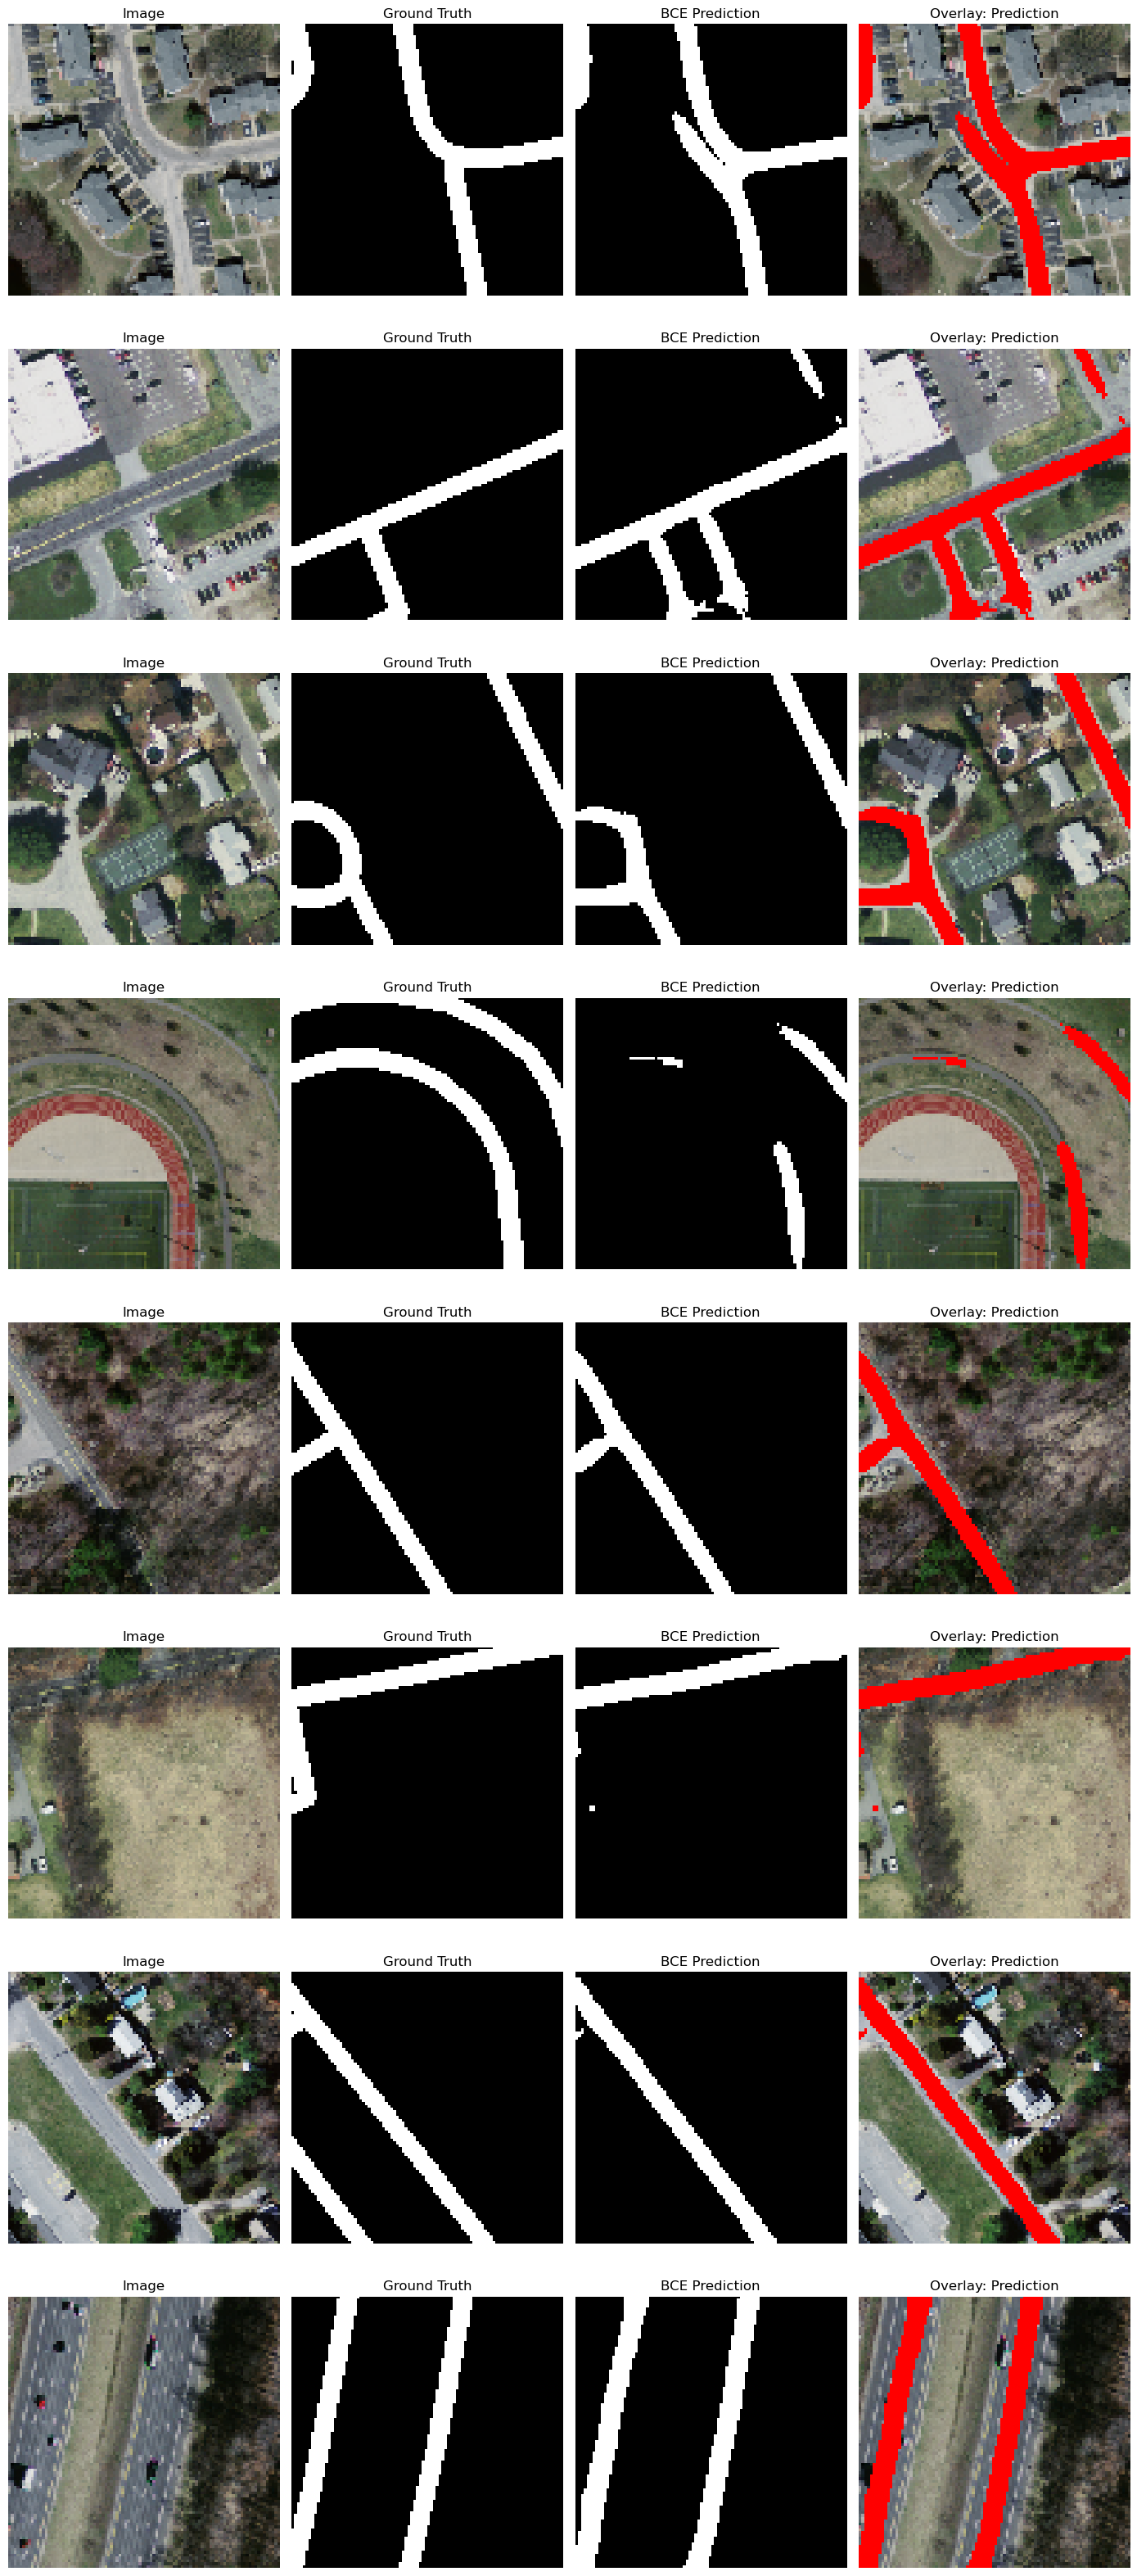


Saved BCE baseline visualization to:
final_thesis_figures/step14_bce_baseline_visible_complex_predictions.png


In [35]:
# ============================================================
# STEP 14: Visualize BCE baseline predictions on visible complex road patches
# ============================================================
# This step visualizes predictions from the BCE-only baseline model.
#
# We intentionally choose complex and visible road patches from the test set.
# This helps us see whether the baseline model can preserve:
#   - road branches
#   - intersections
#   - curved roads
#   - connectivity
#
# Complex patch selection uses:
#   1. road_ratio >= 0.08       -> enough road pixels
#   2. image mean > 40          -> avoid very dark patches
#   3. image std > 10           -> avoid almost blank/constant patches
#
# Columns:
#   Image | Ground Truth | BCE Prediction | Overlay
#
# Red overlay = predicted road pixels.
# ============================================================

# ----------------------------
# Load best BCE baseline model
# ----------------------------
final_baseline_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_baseline_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_baseline_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best BCE threshold
# ----------------------------
final_baseline_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_baseline_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_baseline_threshold.pth"),
        map_location=device
    )
)

final_baseline_model.eval()
final_baseline_threshold.eval()


# ----------------------------
# Select visible complex road patches from test set
# ----------------------------
complex_test_indices = []

for i, p in enumerate(test_patches):
    image_mean = p["image_patch"].mean()
    image_std = p["image_patch"].std()

    if (
        p["road_ratio"] >= 0.08
        and image_mean > 40
        and image_std > 10
    ):
        complex_test_indices.append(i)

num_samples = 8

if len(complex_test_indices) >= num_samples:
    selected_indices = random.sample(complex_test_indices, num_samples)
else:
    print("Not enough visible complex patches found.")
    print("Using fallback selection based only on road ratio.")

    fallback_indices = [
        i for i, p in enumerate(test_patches)
        if p["road_ratio"] >= 0.08
    ]

    selected_indices = random.sample(
        fallback_indices,
        min(num_samples, len(fallback_indices))
    )

print("Number of visible complex patches:", len(complex_test_indices))
print("Selected test patch indices:", selected_indices)


# ----------------------------
# Visualize predictions
# ----------------------------
plt.figure(figsize=(14, 4 * len(selected_indices)))

threshold_value = final_baseline_threshold().item()
print("Learned threshold used:", threshold_value)

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    # Prepare model input
    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        logits = final_baseline_model(image_tensor)
        probs = torch.sigmoid(logits)
        threshold = final_baseline_threshold()
        pred = (probs > threshold).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    # Use normal display, not contrast-stretched display
    image_display = image_patch.astype(np.float32) / 255.0
    mask_np = mask_patch.astype(np.uint8)

    # Create prediction overlay
    overlay = image_display.copy()
    overlay[pred_np == 1] = [1, 0, 0]

    print(f"\nPatch {row + 1}")
    print("Source image:", os.path.basename(patch["image_path"]))
    print("Location: top =", patch["top"], ", left =", patch["left"])
    print(f"Image mean               : {image_patch.mean():.2f}")
    print(f"Image std                : {image_patch.std():.2f}")
    print(f"Ground-truth road ratio  : {patch['road_ratio'] * 100:.2f}%")
    print(f"Predicted road ratio     : {pred_np.mean() * 100:.2f}%")

    # Image
    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display)
    plt.title("Image")
    plt.axis("off")

    # Ground truth
    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("BCE Prediction")
    plt.axis("off")

    # Overlay
    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay: Prediction")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step14_bce_baseline_visible_complex_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved BCE baseline visualization to:")
print(save_path)

# SATLoss implementation for topology-aware training

In [16]:
# ============================================================
# STEP 15: SATLoss implementation for topology-aware training
# ============================================================
# This step defines the topology-aware loss used in the thesis.
#
# We implement:
#
# 1. Creator-only SATLoss
#    - Encourages important missing structures to appear
#    - Matches predicted and true persistence features
#
# 2. Creator + Destroyer SATLoss
#    - Creator term preserves true topology
#    - Destroyer term removes unwanted topological noise
#
# 3. Learnable topology weight lambda
#    - Instead of using a fixed lambda value,
#      the model automatically learns how much importance
#      should be given to SATLoss during training.
#
# Important:
# - GUDHI persistence extraction is not differentiable.
# - Gradients flow only through selected birth/death pixels.
# - This follows practical topology-aware training approaches.
#
# This updated version is fully backward compatible with
# the next notebook steps.
# ============================================================


# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import torch
import torch.nn as nn
import gudhi


# ============================================================
# SATLoss GLOBAL SETTINGS
# ============================================================
# Fixed fallback lambda
# (still kept for compatibility/debugging)
# ============================================================

LAMBDA_TOPO = 1e-4

TOPO_BATCH_LIMIT = 4
MAX_TOPO_FEATURES = 30
SPATIAL_MIN_WEIGHT = 0.05


# ============================================================
# LEARNABLE TOPOLOGY WEIGHT
# ============================================================
# Instead of manually fixing lambda_topo,
# we learn it automatically.
#
# We do NOT learn lambda directly because:
#   - lambda could become negative
#   - lambda could explode
#   - training may become unstable
#
# Therefore:
#
#   lambda = max_value * sigmoid(alpha)
#
# This guarantees:
#
#   0 < lambda < max_value
#
# Recommended:
#   init_value = 1e-4
#   max_value  = 1e-3
# ============================================================

class LearnableLambda(nn.Module):

    def __init__(
        self,
        init_value=1e-4,
        max_value=1e-3
    ):
        super().__init__()

        self.max_value = float(max_value)

        init_ratio = init_value / max_value

        init_ratio = min(
            max(init_ratio, 1e-6),
            1.0 - 1e-6
        )

        init_alpha = np.log(
            init_ratio / (1.0 - init_ratio)
        )

        self.alpha = nn.Parameter(
            torch.tensor(
                init_alpha,
                dtype=torch.float32
            )
        )

    def forward(self):

        return (
            self.max_value *
            torch.sigmoid(self.alpha)
        )


# ============================================================
# GLOBAL LEARNABLE LAMBDA OBJECT
# ============================================================
# This object will automatically be reused
# in later notebook steps.
# ============================================================

learnable_lambda = LearnableLambda(
    init_value=1e-4,
    max_value=1e-3
).to(device)


print("Learnable lambda initialized")
print("--------------------------------")
print(
    "Initial lambda value:",
    learnable_lambda().item()
)


# ============================================================
# HELPER:
# Flat persistence index -> image coordinate
# ============================================================

def flat_to_xy(index, width):

    y = index // width
    x = index % width

    return int(y), int(x)


# ============================================================
# EXTRACT PERSISTENCE FEATURES
# ============================================================

def get_persistence_features_2d(
    prob_np,
    max_features=50
):

    H, W = prob_np.shape

    prob_np = prob_np.astype(np.float64)

    cubical_complex = gudhi.CubicalComplex(
        top_dimensional_cells=-prob_np
    )

    cubical_complex.persistence()

    pairs, _ = (
        cubical_complex.cofaces_of_persistence_pairs()
    )

    features = []

    for dim in [0, 1]:

        if dim >= len(pairs):
            continue

        for pair in pairs[dim]:

            if len(pair) < 2:
                continue

            birth_idx = int(pair[0])
            death_idx = int(pair[1])

            by, bx = flat_to_xy(birth_idx, W)
            dy, dx = flat_to_xy(death_idx, W)

            if by < 0 or by >= H:
                continue

            if bx < 0 or bx >= W:
                continue

            if dy < 0 or dy >= H:
                continue

            if dx < 0 or dx >= W:
                continue

            birth_value = float(prob_np[by, bx])
            death_value = float(prob_np[dy, dx])

            persistence = abs(
                birth_value - death_value
            )

            features.append({

                "dim": dim,

                "birth_xy": (by, bx),

                "death_xy": (dy, dx),

                "birth": birth_value,

                "death": death_value,

                "persistence": persistence
            })

    features = sorted(
        features,
        key=lambda item: item["persistence"],
        reverse=True
    )

    return features[:max_features]


# ============================================================
# SPATIAL-AWARE COST
# ============================================================

def spatial_aware_cost(
    pred_feature,
    true_feature,
    H,
    W
):

    by, bx = pred_feature["birth_xy"]

    tby, tbx = true_feature["birth_xy"]

    spatial_dist = (

        ((by / H) - (tby / H)) ** 2 +

        ((bx / W) - (tbx / W)) ** 2
    )

    spatial_weight = max(
        spatial_dist,
        SPATIAL_MIN_WEIGHT
    )

    diagram_cost = (

        (pred_feature["birth"] -
         true_feature["birth"]) ** 2 +

        (pred_feature["death"] -
         true_feature["death"]) ** 2
    )

    return spatial_weight * diagram_cost


# ============================================================
# GREEDY FEATURE MATCHING
# ============================================================

def match_features_greedy(
    pred_features,
    true_features,
    H,
    W
):

    matched_pairs = []

    unmatched_pred = []

    used_true_indices = set()

    for pred_feature in pred_features:

        best_cost = None
        best_index = None

        for j, true_feature in enumerate(true_features):

            if j in used_true_indices:
                continue

            if pred_feature["dim"] != true_feature["dim"]:
                continue

            cost = spatial_aware_cost(
                pred_feature,
                true_feature,
                H,
                W
            )

            if best_cost is None or cost < best_cost:

                best_cost = cost

                best_index = j

        if best_index is not None:

            matched_pairs.append(

                (
                    pred_feature,
                    true_features[best_index]
                )
            )

            used_true_indices.add(best_index)

        else:

            unmatched_pred.append(pred_feature)

    return matched_pairs, unmatched_pred


# ============================================================
# CREATOR LOSS
# ============================================================

def creator_loss_from_matches(
    prob_tensor,
    matched_pairs,
    H,
    W
):

    device = prob_tensor.device

    total_loss = torch.tensor(
        0.0,
        device=device
    )

    if len(matched_pairs) == 0:
        return total_loss

    for pred_feature, true_feature in matched_pairs:

        by, bx = pred_feature["birth_xy"]

        dy, dx = pred_feature["death_xy"]

        pred_birth = prob_tensor[by, bx]

        pred_death = prob_tensor[dy, dx]

        true_birth = torch.tensor(

            true_feature["birth"],

            device=device,

            dtype=prob_tensor.dtype
        )

        true_death = torch.tensor(

            true_feature["death"],

            device=device,

            dtype=prob_tensor.dtype
        )

        spatial_weight = spatial_aware_cost(

            pred_feature,

            true_feature,

            H,

            W
        )

        total_loss = total_loss + spatial_weight * (

            (pred_birth - true_birth) ** 2 +

            (pred_death - true_death) ** 2
        )

    return total_loss / len(matched_pairs)


# ============================================================
# DESTROYER LOSS
# ============================================================

def destroyer_loss_from_unmatched(
    prob_tensor,
    unmatched_features
):

    device = prob_tensor.device

    total_loss = torch.tensor(
        0.0,
        device=device
    )

    if len(unmatched_features) == 0:
        return total_loss

    for feature in unmatched_features:

        by, bx = feature["birth_xy"]

        dy, dx = feature["death_xy"]

        pred_birth = prob_tensor[by, bx]

        pred_death = prob_tensor[dy, dx]

        midpoint = 0.5 * (
            pred_birth + pred_death
        )

        total_loss = total_loss + (

            (pred_birth - midpoint) ** 2 +

            (pred_death - midpoint) ** 2
        )

    return total_loss / len(unmatched_features)


# ============================================================
# SATLOSS FOR ONE IMAGE
# ============================================================

def satloss_single(

    prob_tensor,

    mask_tensor,

    mode="creator",

    max_features=50
):

    H, W = prob_tensor.shape

    device = prob_tensor.device

    prob_np = (
        prob_tensor
        .detach()
        .cpu()
        .numpy()
    )

    mask_np = (
        mask_tensor
        .detach()
        .cpu()
        .numpy()
    )

    pred_features = get_persistence_features_2d(

        prob_np,

        max_features=max_features
    )

    true_features = get_persistence_features_2d(

        mask_np,

        max_features=max_features
    )

    if len(pred_features) == 0:

        return torch.tensor(
            0.0,
            device=device
        )

    matched_pairs, unmatched_pred = (

        match_features_greedy(

            pred_features,

            true_features,

            H,

            W
        )
    )

    creator_loss = creator_loss_from_matches(

        prob_tensor,

        matched_pairs,

        H,

        W
    )

    if mode == "creator":

        return creator_loss

    elif mode == "creator_destroyer":

        destroyer_loss = (

            destroyer_loss_from_unmatched(

                prob_tensor,

                unmatched_pred
            )
        )

        return creator_loss + destroyer_loss

    else:

        raise ValueError(

            "mode must be either "

            "'creator' or "

            "'creator_destroyer'"
        )


# ============================================================
# SATLOSS FOR MINI-BATCH
# ============================================================

def satloss_batch(

    probs,

    masks,

    mode="creator",

    batch_limit=2,

    max_features=50
):

    B = probs.shape[0]

    use_B = min(B, batch_limit)

    losses = []

    for i in range(use_B):

        prob_i = probs[i, 0]

        mask_i = masks[i, 0]

        loss_i = satloss_single(

            prob_i,

            mask_i,

            mode=mode,

            max_features=max_features
        )

        losses.append(loss_i)

    if len(losses) == 0:

        return torch.tensor(
            0.0,
            device=probs.device
        )

    return torch.stack(losses).mean()


# ============================================================
# TOTAL LOSS HELPER
# ============================================================
# This helper makes future notebook steps easier.
#
# If use_learnable_lambda=True:
#   uses learned topology weight
#
# Else:
#   uses fixed LAMBDA_TOPO
# ============================================================

def compute_total_topology_loss(

    bce,

    dloss,

    closs,

    sat,

    use_learnable_lambda=True
):

    if use_learnable_lambda:

        lambda_topo = learnable_lambda()

    else:

        lambda_topo = torch.tensor(
            LAMBDA_TOPO,
            device=sat.device
        )

    total_loss = (

        bce +

        dloss +

        closs +

        lambda_topo * sat
    )

    return total_loss, lambda_topo


# ============================================================
# QUICK SATLOSS TEST
# ============================================================

sat_test_model = UNet(

    in_channels=3,

    out_channels=1
).to(device)

sat_test_model.eval()

images, masks = next(iter(train_loader))

images = images.to(device)

masks = masks.to(device)

with torch.no_grad():

    logits = sat_test_model(images)

    probs = torch.sigmoid(logits)

sat_creator_value = satloss_batch(

    probs,

    masks,

    mode="creator",

    batch_limit=TOPO_BATCH_LIMIT,

    max_features=MAX_TOPO_FEATURES
)

sat_creator_destroyer_value = satloss_batch(

    probs,

    masks,

    mode="creator_destroyer",

    batch_limit=TOPO_BATCH_LIMIT,

    max_features=MAX_TOPO_FEATURES
)

print("\nSATLoss quick test")
print("---------------------------")

print(
    "Creator-only SATLoss       :",
    sat_creator_value.item()
)

print(
    "Creator + Destroyer SATLoss:",
    sat_creator_destroyer_value.item()
)

print(
    "Current learned lambda     :",
    learnable_lambda().item()
)

Learnable lambda initialized
--------------------------------
Initial lambda value: 0.00010000000474974513

SATLoss quick test
---------------------------
Creator-only SATLoss       : 0.16147738695144653
Creator + Destroyer SATLoss: 0.1614781767129898
Current learned lambda     : 0.00010000000474974513


# 2: Train U-Net with BCE + SATLoss creators only

In [17]:
# ============================================================
# STEP 16: Train U-Net with BCE + SATLoss Creator
# ============================================================
# This is the first topology-aware road segmentation model.
#
# Training loss:
#     L = BCE + lambda_topo * SATLoss_creator
#
# Here, lambda_topo is learnable:
#     lambda_topo = lambda_max * sigmoid(alpha)
#
# This allows the model to learn how strongly SATLoss should
# contribute during training.
# ============================================================

BCE_SAT_CREATOR_EPOCHS = 20
BCE_SAT_CREATOR_LR = 1e-4
BCE_SAT_CREATOR_WEIGHT_DECAY = 1e-4

TOPO_BATCH_LIMIT = 4
MAX_TOPO_FEATURES = 30

# ----------------------------
# Create model and threshold
# ----------------------------
bce_sat_creator_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

bce_sat_creator_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

# ----------------------------
# Create separate learnable lambda for this model
# ----------------------------
bce_sat_creator_lambda = LearnableLambda(
    init_value=1e-4,
    max_value=1e-3
).to(device)

print("Initial topology lambda:", bce_sat_creator_lambda().item())


# ----------------------------
# Optimizer
# ----------------------------
bce_sat_creator_optimizer = optim.Adam(
    list(bce_sat_creator_model.parameters()) +
    list(bce_sat_creator_threshold.parameters()) +
    list(bce_sat_creator_lambda.parameters()),
    lr=BCE_SAT_CREATOR_LR,
    weight_decay=BCE_SAT_CREATOR_WEIGHT_DECAY
)


# ----------------------------
# Scheduler
# ----------------------------
bce_sat_creator_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    bce_sat_creator_optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ----------------------------
# Mixed precision scaler
# ----------------------------
scaler = torch.cuda.amp.GradScaler()


# ----------------------------
# Training history
# ----------------------------
bce_sat_creator_history = {
    "train_total_loss": [],
    "train_bce_loss": [],
    "train_sat_loss": [],
    "lambda_topo": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": [],
    "threshold": []
}


def train_one_epoch_bce_sat_creator(
    model,
    threshold_module,
    lambda_module,
    loader,
    optimizer,
    scaler,
    device
):
    """
    Train one epoch using:
        BCE + learnable_lambda * SATLoss Creator
    """

    model.train()
    threshold_module.train()
    lambda_module.train()

    total_loss = 0.0
    total_bce = 0.0
    total_sat = 0.0

    for images, masks in tqdm(loader, desc="Training BCE + SATLoss Creator"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            logits = model(images)
            probs = torch.sigmoid(logits)
            bce = bce_loss_fn(logits, masks)

        sat = satloss_batch(
            probs.float(),
            masks.float(),
            mode="creator",
            batch_limit=TOPO_BATCH_LIMIT,
            max_features=MAX_TOPO_FEATURES
        )

        lambda_topo = lambda_module()

        loss = bce + lambda_topo * sat

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_bce += bce.item()
        total_sat += sat.item()

    return {
        "loss": total_loss / len(loader),
        "bce": total_bce / len(loader),
        "sat": total_sat / len(loader),
        "lambda_topo": lambda_module().item()
    }


# ----------------------------
# Best model tracking
# ----------------------------
best_bce_sat_creator_dice = -1.0


# ----------------------------
# Training loop
# ----------------------------
for epoch in range(BCE_SAT_CREATOR_EPOCHS):

    print(f"\nBCE + SATLoss Creator Epoch {epoch + 1}/{BCE_SAT_CREATOR_EPOCHS}")
    print("-" * 65)

    train_metrics = train_one_epoch_bce_sat_creator(
        bce_sat_creator_model,
        bce_sat_creator_threshold,
        bce_sat_creator_lambda,
        train_loader,
        bce_sat_creator_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_model(
        bce_sat_creator_model,
        bce_sat_creator_threshold,
        val_loader,
        device
    )

    bce_sat_creator_scheduler.step(val_metrics["dice"])

    # ----------------------------
    # Save history
    # ----------------------------
    bce_sat_creator_history["train_total_loss"].append(train_metrics["loss"])
    bce_sat_creator_history["train_bce_loss"].append(train_metrics["bce"])
    bce_sat_creator_history["train_sat_loss"].append(train_metrics["sat"])
    bce_sat_creator_history["lambda_topo"].append(train_metrics["lambda_topo"])

    bce_sat_creator_history["val_loss"].append(val_metrics["loss"])
    bce_sat_creator_history["val_accuracy"].append(val_metrics["accuracy"])
    bce_sat_creator_history["val_dice"].append(val_metrics["dice"])
    bce_sat_creator_history["val_cldice"].append(val_metrics["cldice"])
    bce_sat_creator_history["val_beta0_error"].append(val_metrics["beta0_error"])
    bce_sat_creator_history["val_beta1_error"].append(val_metrics["beta1_error"])
    bce_sat_creator_history["threshold"].append(val_metrics["threshold"])

    # ----------------------------
    # Print metrics
    # ----------------------------
    print(f"Train Total Loss : {train_metrics['loss']:.4f}")
    print(f"Train BCE Loss   : {train_metrics['bce']:.4f}")
    print(f"Train SATLoss    : {train_metrics['sat']:.4f}")
    print(f"Learned lambda   : {train_metrics['lambda_topo']:.8f}")

    print(f"Val BCE Loss     : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice         : {val_metrics['dice']:.4f}")
    print(f"Val clDice       : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err    : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err    : {val_metrics['beta1_error']:.4f}")
    print(f"Learned thresh   : {val_metrics['threshold']:.4f}")

    current_lr = bce_sat_creator_optimizer.param_groups[0]["lr"]
    print(f"Learning rate    : {current_lr:.6f}")

    # ----------------------------
    # Save best model
    # ----------------------------
    if val_metrics["dice"] > best_bce_sat_creator_dice:

        best_bce_sat_creator_dice = val_metrics["dice"]

        torch.save(
            copy.deepcopy(bce_sat_creator_model.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_bce_sat_creator_model.pth"
            )
        )

        torch.save(
            copy.deepcopy(bce_sat_creator_threshold.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_bce_sat_creator_threshold.pth"
            )
        )

        torch.save(
            copy.deepcopy(bce_sat_creator_lambda.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_bce_sat_creator_lambda.pth"
            )
        )

        print("Best BCE + SATLoss Creator model, threshold, and lambda saved.")

print("\nBCE + SATLoss Creator training finished.")
print("Best validation Dice:", best_bce_sat_creator_dice)
print("Final learned lambda:", bce_sat_creator_lambda().item())

Initial topology lambda: 0.00010000000474974513

BCE + SATLoss Creator Epoch 1/20
-----------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 37.32it/s]


Train Total Loss : 0.1967
Train BCE Loss   : 0.1966
Train SATLoss    : 0.0875
Learned lambda   : 0.00013751
Val BCE Loss     : 0.1562
Val Accuracy     : 0.9473
Val Dice         : 0.6555
Val clDice       : 0.6649
Val beta0 err    : 0.9520
Val beta1 err    : 0.0864
Learned thresh   : 0.5000
Learning rate    : 0.000100
Best BCE + SATLoss Creator model, threshold, and lambda saved.

BCE + SATLoss Creator Epoch 2/20
-----------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 38.03it/s]


Train Total Loss : 0.1516
Train BCE Loss   : 0.1516
Train SATLoss    : 0.1108
Learned lambda   : 0.00018407
Val BCE Loss     : 0.1473
Val Accuracy     : 0.9498
Val Dice         : 0.6775
Val clDice       : 0.6936
Val beta0 err    : 0.9224
Val beta1 err    : 0.0900
Learned thresh   : 0.5000
Learning rate    : 0.000100
Best BCE + SATLoss Creator model, threshold, and lambda saved.

BCE + SATLoss Creator Epoch 3/20
-----------------------------------------------------------------


...

Train Total Loss : 0.1054
Train BCE Loss   : 0.1053
Train SATLoss    : 0.1387
Learned lambda   : 0.00041956
Val BCE Loss     : 0.1373
Val Accuracy     : 0.9541
Val Dice         : 0.7169
Val clDice       : 0.7310
Val beta0 err    : 0.7194
Val beta1 err    : 0.0932
Learned thresh   : 0.5000
Learning rate    : 0.000050

BCE + SATLoss Creator Epoch 19/20
-----------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 38.53it/s]


Train Total Loss : 0.1028
Train BCE Loss   : 0.1027
Train SATLoss    : 0.1410
Learned lambda   : 0.00041828
Val BCE Loss     : 0.1386
Val Accuracy     : 0.9539
Val Dice         : 0.7152
Val clDice       : 0.7279
Val beta0 err    : 0.7454
Val beta1 err    : 0.0930
Learned thresh   : 0.5000
Learning rate    : 0.000050

BCE + SATLoss Creator Epoch 20/20
-----------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.64it/s]

Train Total Loss : 0.1002
Train BCE Loss   : 0.1001
Train SATLoss    : 0.1459
Learned lambda   : 0.00041651
Val BCE Loss     : 0.1427
Val Accuracy     : 0.9539
Val Dice         : 0.7102
Val clDice       : 0.7238
Val beta0 err    : 0.7564
Val beta1 err    : 0.0966
Learned thresh   : 0.5000
Learning rate    : 0.000050

BCE + SATLoss Creator training finished.
Best validation Dice: 0.7174006135940552
Final learned lambda: 0.00041651399806141853


In [18]:
# ============================================================
# STEP 17: Final evaluation of BCE + SATLoss creators-only model
# ============================================================
# This step evaluates the best BCE + SATLoss Creator model on the test set.
#
# This model is compared with:
#   1. BCE only baseline
#   2. BCE + SATLoss Creator + Destroyer
#   3. Hybrid + SATLoss models
# ============================================================

# ----------------------------
# Load best model
# ----------------------------
final_bce_sat_creator_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_bce_sat_creator_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_bce_sat_creator_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best threshold
# ----------------------------
final_bce_sat_creator_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_bce_sat_creator_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_bce_sat_creator_threshold.pth"),
        map_location=device
    )
)

final_bce_sat_creator_model.eval()
final_bce_sat_creator_threshold.eval()

# ----------------------------
# Evaluate on test set
# ----------------------------
bce_sat_creator_test_metrics = evaluate_model(
    final_bce_sat_creator_model,
    final_bce_sat_creator_threshold,
    test_loader,
    device
)

# ----------------------------
# Print final test results
# ----------------------------
print("FINAL TEST RESULTS: BCE + SATLoss Creator")
print("-----------------------------------------")
print(f"Test BCE Loss   : {bce_sat_creator_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {bce_sat_creator_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {bce_sat_creator_test_metrics['dice']:.4f}")
print(f"Test clDice     : {bce_sat_creator_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {bce_sat_creator_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {bce_sat_creator_test_metrics['beta1_error']:.4f}")
print(f"Learned thresh  : {bce_sat_creator_test_metrics['threshold']:.4f}")

# ----------------------------
# Save result for comparison table
# ----------------------------
bce_sat_creator_result = {
    "Model": "BCE + SATLoss Creator",
    "Loss": bce_sat_creator_test_metrics["loss"],
    "Accuracy": bce_sat_creator_test_metrics["accuracy"],
    "Dice": bce_sat_creator_test_metrics["dice"],
    "clDice": bce_sat_creator_test_metrics["cldice"],
    "beta0_error": bce_sat_creator_test_metrics["beta0_error"],
    "beta1_error": bce_sat_creator_test_metrics["beta1_error"],
    "Threshold": bce_sat_creator_test_metrics["threshold"]
}

bce_sat_creator_results_df = pd.DataFrame([bce_sat_creator_result])

bce_sat_creator_results_path = os.path.join(
    RESULTS_DIR,
    "bce_sat_creator_test_results.csv"
)

bce_sat_creator_results_df.to_csv(
    bce_sat_creator_results_path,
    index=False
)

print("\nSaved BCE + SATLoss Creator results to:")
print(bce_sat_creator_results_path)

Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.18it/s]

FINAL TEST RESULTS: BCE + SATLoss Creator
-----------------------------------------
Test BCE Loss   : 0.1360
Test Accuracy   : 0.9543
Test Dice       : 0.7182
Test clDice     : 0.7291
Test beta0 err  : 0.7534
Test beta1 err  : 0.1062
Learned thresh  : 0.5000

Saved BCE + SATLoss Creator results to:
final_thesis_results/bce_sat_creator_test_results.csv


Number of visible complex patches: 2241
Selected test patch indices: [3515, 2186, 1732, 1974, 2529, 1472, 462, 1689]
Learned threshold used: 0.5

Patch 1
Source image: 22829410_15.tiff
Location: top = 240 , left = 0
Image mean               : 77.37
Image std                : 44.30
Ground-truth road ratio  : 16.08%
Predicted road ratio     : 17.02%

Patch 2
Source image: 20728945_15.tiff
Location: top = 768 , left = 720
Image mean               : 80.59
Image std                : 42.32
Ground-truth road ratio  : 10.97%
Predicted road ratio     : 11.19%

Patch 3
Source image: 22228990_15.tiff
Location: top = 1248 , left = 624
Image mean               : 79.62
Image std                : 48.05
Ground-truth road ratio  : 12.30%
Predicted road ratio     : 11.47%

Patch 4
Source image: 24629200_15.tiff
Location: top = 720 , left = 1248
Image mean               : 79.26
Image std                : 50.66
Ground-truth road ratio  : 11.33%
Predicted road ratio     : 11.08%

Patch 5
Source image: 2267

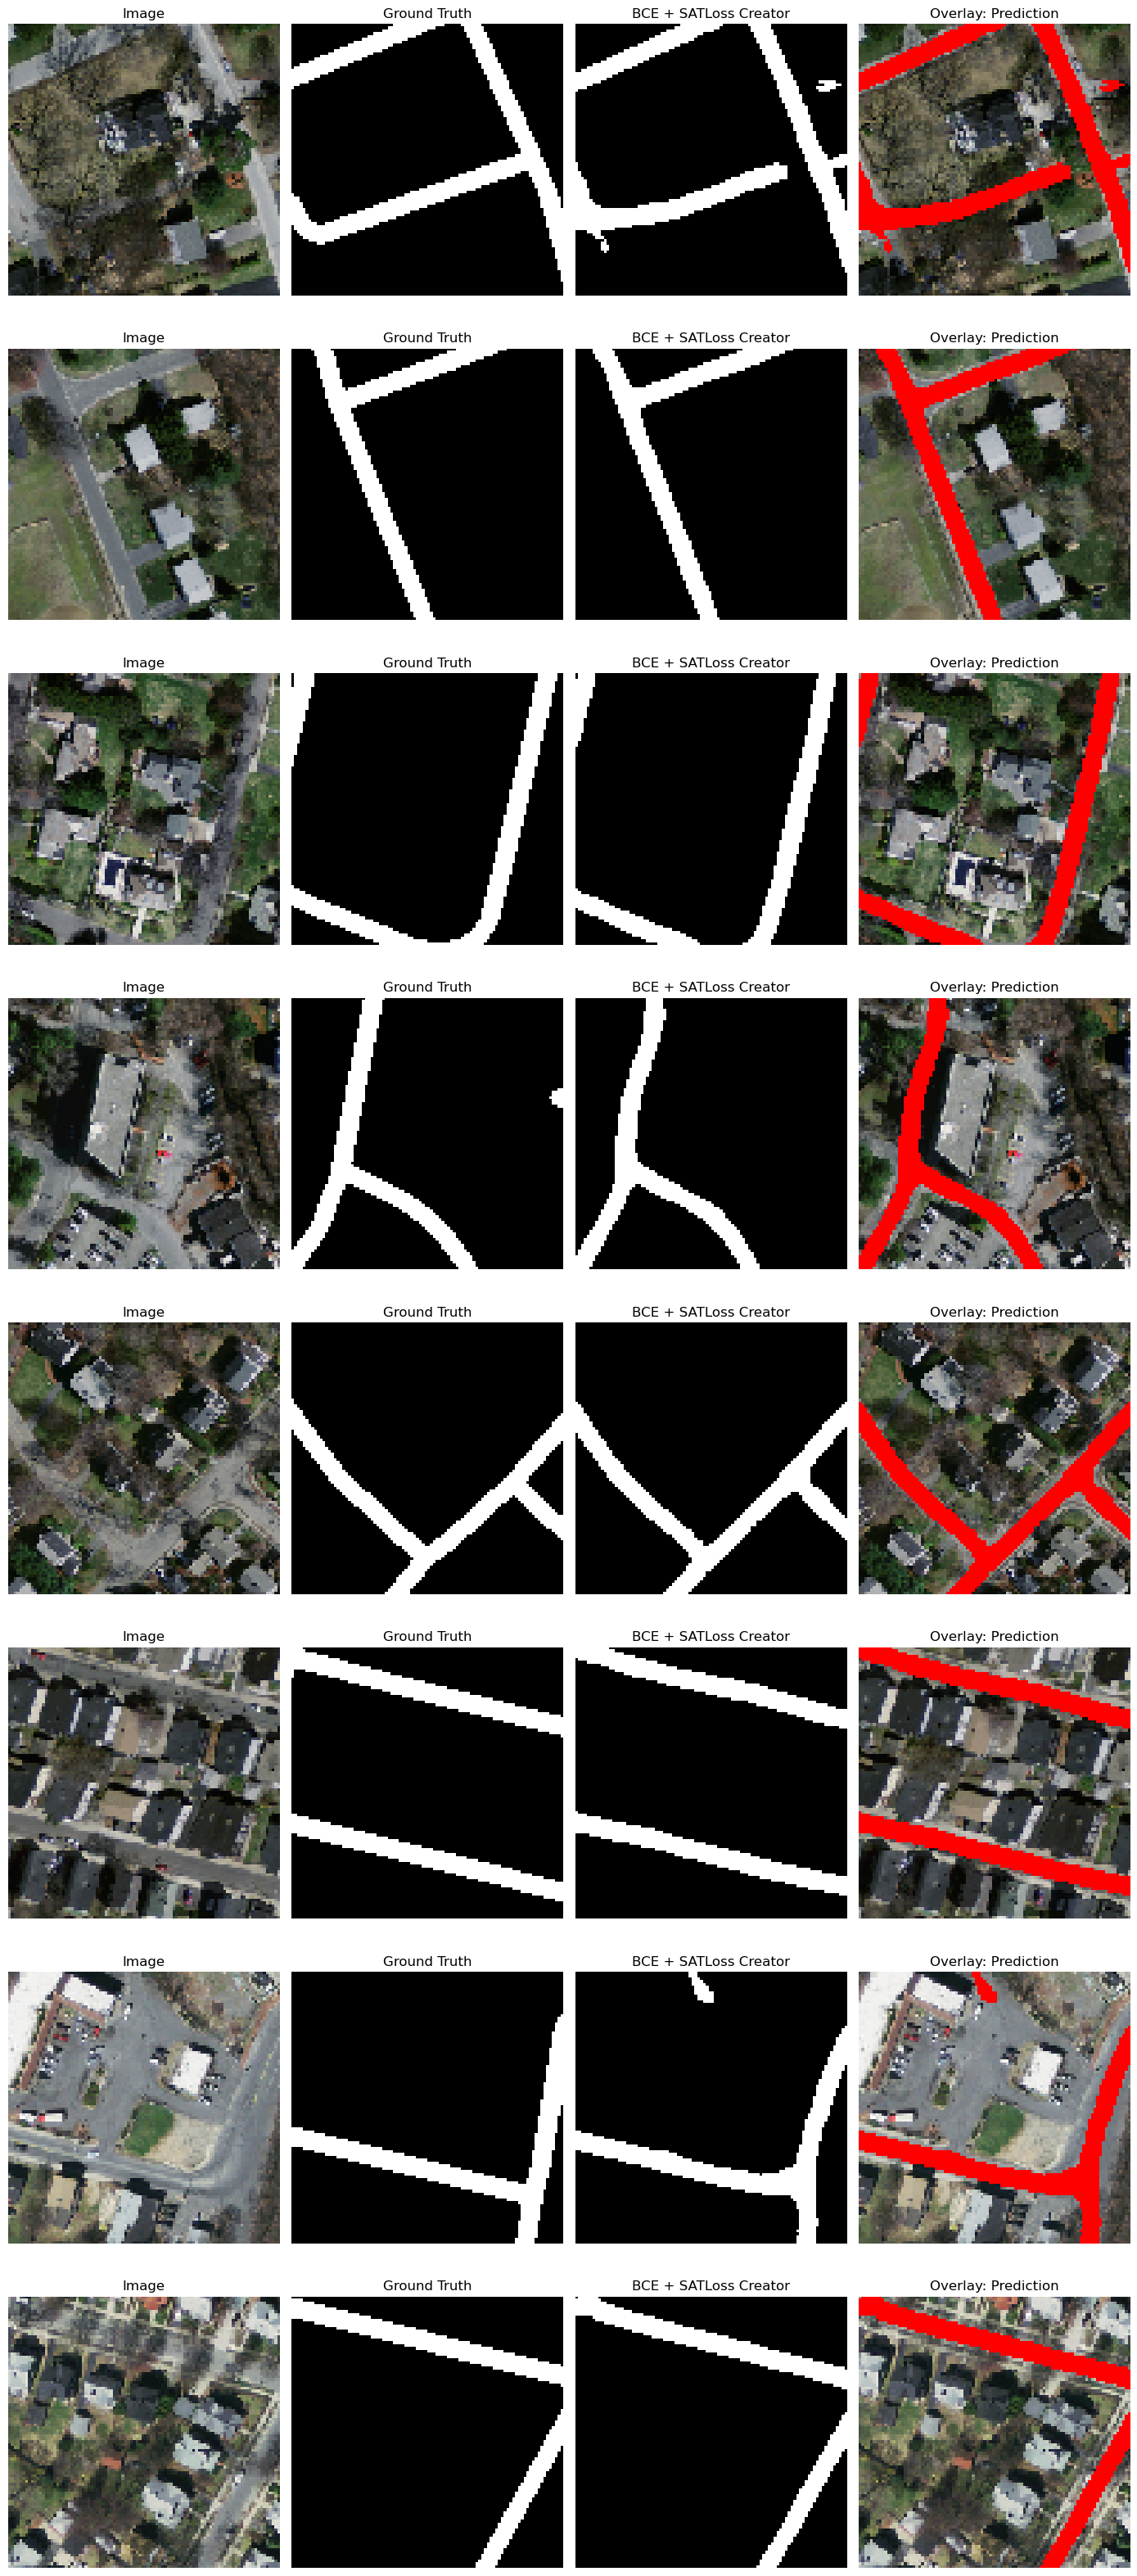


Saved BCE + SATLoss Creator visualization to:
final_thesis_figures/step18_bce_sat_creator_visible_complex_predictions.png


In [19]:
# ============================================================
# STEP 18: Visualize BCE + SATLoss Creator predictions
# ============================================================
# This step visualizes predictions from the BCE + SATLoss Creator model.
#
# We use the same idea as Step 14:
#   - choose visible complex road patches
#   - avoid blank/dark patches
#   - show prediction quality on difficult road structures
#
# Columns:
#   Image | Ground Truth | BCE + SATLoss Creator Prediction | Overlay
#
# Red overlay = predicted road pixels.
# ============================================================

# ----------------------------
# Load best BCE + SATLoss Creator model
# ----------------------------
final_bce_sat_creator_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_bce_sat_creator_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_bce_sat_creator_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best threshold
# ----------------------------
final_bce_sat_creator_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_bce_sat_creator_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_bce_sat_creator_threshold.pth"),
        map_location=device
    )
)

final_bce_sat_creator_model.eval()
final_bce_sat_creator_threshold.eval()


# ----------------------------
# Select visible complex road patches
# ----------------------------
complex_test_indices = []

for i, p in enumerate(test_patches):
    image_mean = p["image_patch"].mean()
    image_std = p["image_patch"].std()

    if (
        p["road_ratio"] >= 0.08
        and image_mean > 40
        and image_std > 10
    ):
        complex_test_indices.append(i)

num_samples = 8

if len(complex_test_indices) >= num_samples:
    selected_indices = random.sample(complex_test_indices, num_samples)
else:
    fallback_indices = [
        i for i, p in enumerate(test_patches)
        if p["road_ratio"] >= 0.08
    ]

    selected_indices = random.sample(
        fallback_indices,
        min(num_samples, len(fallback_indices))
    )

print("Number of visible complex patches:", len(complex_test_indices))
print("Selected test patch indices:", selected_indices)


# ----------------------------
# Visualize predictions
# ----------------------------
plt.figure(figsize=(14, 4 * len(selected_indices)))

threshold_value = final_bce_sat_creator_threshold().item()
print("Learned threshold used:", threshold_value)

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_bce_sat_creator_model(image_tensor)
        probs = torch.sigmoid(logits)
        threshold = final_bce_sat_creator_threshold()
        pred = (probs > threshold).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    image_display = image_patch.astype(np.float32) / 255.0
    mask_np = mask_patch.astype(np.uint8)

    overlay = image_display.copy()
    overlay[pred_np == 1] = [1, 0, 0]

    print(f"\nPatch {row + 1}")
    print("Source image:", os.path.basename(patch["image_path"]))
    print("Location: top =", patch["top"], ", left =", patch["left"])
    print(f"Image mean               : {image_patch.mean():.2f}")
    print(f"Image std                : {image_patch.std():.2f}")
    print(f"Ground-truth road ratio  : {patch['road_ratio'] * 100:.2f}%")
    print(f"Predicted road ratio     : {pred_np.mean() * 100:.2f}%")

    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("BCE + SATLoss Creator")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay: Prediction")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step18_bce_sat_creator_visible_complex_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved BCE + SATLoss Creator visualization to:")
print(save_path)

# 3: Train U-Net with BCE + SATLoss creators + destroyers

In [20]:
# ============================================================
# STEP 19: Train U-Net with BCE + SATLoss Creator-Destroyer
# ============================================================
# This is the second topology-aware BCE model.
#
# Training loss:
#     L = BCE + lambda_topo * SATLoss_creator_destroyer
#
# Here, lambda_topo is learnable:
#     lambda_topo = lambda_max * sigmoid(alpha)
#
# Creator term:
#   matches important predicted topological features with
#   ground-truth topological features.
#
# Destroyer term:
#   pushes unmatched predicted features toward the diagonal,
#   reducing false components and false loops.
# ============================================================

BCE_SAT_CD_EPOCHS = 20
BCE_SAT_CD_LR = 1e-4
BCE_SAT_CD_WEIGHT_DECAY = 1e-4

TOPO_BATCH_LIMIT = 4
MAX_TOPO_FEATURES = 30

# ----------------------------
# Create model, threshold, and learnable lambda
# ----------------------------
bce_sat_cd_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

bce_sat_cd_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

bce_sat_cd_lambda = LearnableLambda(
    init_value=1e-4,
    max_value=1e-3
).to(device)

print("Initial topology lambda:", bce_sat_cd_lambda().item())


# ----------------------------
# Optimizer
# ----------------------------
bce_sat_cd_optimizer = optim.Adam(
    list(bce_sat_cd_model.parameters()) +
    list(bce_sat_cd_threshold.parameters()) +
    list(bce_sat_cd_lambda.parameters()),
    lr=BCE_SAT_CD_LR,
    weight_decay=BCE_SAT_CD_WEIGHT_DECAY
)


# ----------------------------
# Scheduler
# ----------------------------
bce_sat_cd_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    bce_sat_cd_optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ----------------------------
# Mixed precision scaler
# ----------------------------
scaler = torch.cuda.amp.GradScaler()


# ----------------------------
# Training history
# ----------------------------
bce_sat_cd_history = {
    "train_total_loss": [],
    "train_bce_loss": [],
    "train_sat_loss": [],
    "lambda_topo": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": [],
    "threshold": []
}


def train_one_epoch_bce_sat_cd(
    model,
    threshold_module,
    lambda_module,
    loader,
    optimizer,
    scaler,
    device
):
    """
    Train one epoch using:
        BCE + learnable_lambda * SATLoss Creator-Destroyer
    """

    model.train()
    threshold_module.train()
    lambda_module.train()

    total_loss = 0.0
    total_bce = 0.0
    total_sat = 0.0

    for images, masks in tqdm(loader, desc="Training BCE + SATLoss C+D"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            logits = model(images)
            probs = torch.sigmoid(logits)
            bce = bce_loss_fn(logits, masks)

        sat = satloss_batch(
            probs.float(),
            masks.float(),
            mode="creator_destroyer",
            batch_limit=TOPO_BATCH_LIMIT,
            max_features=MAX_TOPO_FEATURES
        )

        lambda_topo = lambda_module()

        loss = bce + lambda_topo * sat

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_bce += bce.item()
        total_sat += sat.item()

    return {
        "loss": total_loss / len(loader),
        "bce": total_bce / len(loader),
        "sat": total_sat / len(loader),
        "lambda_topo": lambda_module().item()
    }


# ----------------------------
# Best model tracking
# ----------------------------
best_bce_sat_cd_dice = -1.0


# ----------------------------
# Training loop
# ----------------------------
for epoch in range(BCE_SAT_CD_EPOCHS):

    print(f"\nBCE + SATLoss Creator-Destroyer Epoch {epoch + 1}/{BCE_SAT_CD_EPOCHS}")
    print("-" * 70)

    train_metrics = train_one_epoch_bce_sat_cd(
        bce_sat_cd_model,
        bce_sat_cd_threshold,
        bce_sat_cd_lambda,
        train_loader,
        bce_sat_cd_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_model(
        bce_sat_cd_model,
        bce_sat_cd_threshold,
        val_loader,
        device
    )

    bce_sat_cd_scheduler.step(val_metrics["dice"])

    # ----------------------------
    # Save history
    # ----------------------------
    bce_sat_cd_history["train_total_loss"].append(train_metrics["loss"])
    bce_sat_cd_history["train_bce_loss"].append(train_metrics["bce"])
    bce_sat_cd_history["train_sat_loss"].append(train_metrics["sat"])
    bce_sat_cd_history["lambda_topo"].append(train_metrics["lambda_topo"])

    bce_sat_cd_history["val_loss"].append(val_metrics["loss"])
    bce_sat_cd_history["val_accuracy"].append(val_metrics["accuracy"])
    bce_sat_cd_history["val_dice"].append(val_metrics["dice"])
    bce_sat_cd_history["val_cldice"].append(val_metrics["cldice"])
    bce_sat_cd_history["val_beta0_error"].append(val_metrics["beta0_error"])
    bce_sat_cd_history["val_beta1_error"].append(val_metrics["beta1_error"])
    bce_sat_cd_history["threshold"].append(val_metrics["threshold"])

    # ----------------------------
    # Print metrics
    # ----------------------------
    print(f"Train Total Loss : {train_metrics['loss']:.4f}")
    print(f"Train BCE Loss   : {train_metrics['bce']:.4f}")
    print(f"Train SATLoss    : {train_metrics['sat']:.4f}")
    print(f"Learned lambda   : {train_metrics['lambda_topo']:.8f}")

    print(f"Val BCE Loss     : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice         : {val_metrics['dice']:.4f}")
    print(f"Val clDice       : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err    : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err    : {val_metrics['beta1_error']:.4f}")
    print(f"Learned thresh   : {val_metrics['threshold']:.4f}")

    current_lr = bce_sat_cd_optimizer.param_groups[0]["lr"]
    print(f"Learning rate    : {current_lr:.6f}")

    # ----------------------------
    # Save best model
    # ----------------------------
    if val_metrics["dice"] > best_bce_sat_cd_dice:

        best_bce_sat_cd_dice = val_metrics["dice"]

        torch.save(
            copy.deepcopy(bce_sat_cd_model.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_bce_sat_creator_destroyer_model.pth"
            )
        )

        torch.save(
            copy.deepcopy(bce_sat_cd_threshold.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_bce_sat_creator_destroyer_threshold.pth"
            )
        )

        torch.save(
            copy.deepcopy(bce_sat_cd_lambda.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_bce_sat_creator_destroyer_lambda.pth"
            )
        )

        print("Best BCE + SATLoss Creator-Destroyer model, threshold, and lambda saved.")

print("\nBCE + SATLoss Creator-Destroyer training finished.")
print("Best validation Dice:", best_bce_sat_cd_dice)
print("Final learned lambda:", bce_sat_cd_lambda().item())

Initial topology lambda: 0.00010000000474974513

BCE + SATLoss Creator-Destroyer Epoch 1/20
----------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 37.78it/s]


Train Total Loss : 0.1952
Train BCE Loss   : 0.1952
Train SATLoss    : 0.1350
Learned lambda   : 0.00013717
Val BCE Loss     : 0.1515
Val Accuracy     : 0.9468
Val Dice         : 0.6595
Val clDice       : 0.6667
Val beta0 err    : 1.0146
Val beta1 err    : 0.0850
Learned thresh   : 0.5000
Learning rate    : 0.000100
Best BCE + SATLoss Creator-Destroyer model, threshold, and lambda saved.

BCE + SATLoss Creator-Destroyer Epoch 2/20
----------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 37.23it/s]


Train Total Loss : 0.1517
Train BCE Loss   : 0.1517
Train SATLoss    : 0.1687
Learned lambda   : 0.00018324
Val BCE Loss     : 0.1435
Val Accuracy     : 0.9495
Val Dice         : 0.6850
Val clDice       : 0.6958
Val beta0 err    : 0.9042
Val beta1 err    : 0.0870
Learned thresh   : 0.5000
Learning rate    : 0.000100
Best BCE + SATLoss Creator-Destroyer model, threshold, and lambda saved.

BCE + SATLoss Creator-Destroyer Epoch 3/20
----------------------------------------------------------------------


...

Train Total Loss : 0.1048
Train BCE Loss   : 0.1047
Train SATLoss    : 0.2319
Learned lambda   : 0.00037411
Val BCE Loss     : 0.1358
Val Accuracy     : 0.9532
Val Dice         : 0.7166
Val clDice       : 0.7309
Val beta0 err    : 0.7864
Val beta1 err    : 0.0954
Learned thresh   : 0.5000
Learning rate    : 0.000050

BCE + SATLoss Creator-Destroyer Epoch 19/20
----------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.76it/s]


Train Total Loss : 0.1024
Train BCE Loss   : 0.1023
Train SATLoss    : 0.2317
Learned lambda   : 0.00037223
Val BCE Loss     : 0.1425
Val Accuracy     : 0.9523
Val Dice         : 0.7145
Val clDice       : 0.7283
Val beta0 err    : 0.8590
Val beta1 err    : 0.1112
Learned thresh   : 0.5000
Learning rate    : 0.000025

BCE + SATLoss Creator-Destroyer Epoch 20/20
----------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 36.83it/s]

Train Total Loss : 0.0955
Train BCE Loss   : 0.0954
Train SATLoss    : 0.2426
Learned lambda   : 0.00037067
Val BCE Loss     : 0.1428
Val Accuracy     : 0.9532
Val Dice         : 0.7149
Val clDice       : 0.7292
Val beta0 err    : 0.8074
Val beta1 err    : 0.1046
Learned thresh   : 0.5000
Learning rate    : 0.000025

BCE + SATLoss Creator-Destroyer training finished.
Best validation Dice: 0.7192432184696198
Final learned lambda: 0.0003706686256919056


In [21]:
# ============================================================
# STEP 20: Final evaluation of BCE + SATLoss Creator-Destroyer model
# ============================================================
# This step evaluates the best BCE + SATLoss Creator-Destroyer model
# on the test set.
#
# This allows direct comparison with:
#   1. BCE only
#   2. BCE + SATLoss Creator only
#
# The main question:
#   Does adding destroyer features improve topology errors,
#   especially beta0 and beta1?
# ============================================================

# ----------------------------
# Load best Creator-Destroyer model
# ----------------------------
final_bce_sat_cd_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_bce_sat_cd_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_bce_sat_creator_destroyer_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best learned threshold
# ----------------------------
final_bce_sat_cd_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_bce_sat_cd_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_bce_sat_creator_destroyer_threshold.pth"),
        map_location=device
    )
)

final_bce_sat_cd_model.eval()
final_bce_sat_cd_threshold.eval()

# ----------------------------
# Evaluate on test set
# ----------------------------
bce_sat_cd_test_metrics = evaluate_model(
    final_bce_sat_cd_model,
    final_bce_sat_cd_threshold,
    test_loader,
    device
)

# ----------------------------
# Print final test results
# ----------------------------
print("FINAL TEST RESULTS: BCE + SATLoss Creator-Destroyer")
print("---------------------------------------------------")
print(f"Test BCE Loss   : {bce_sat_cd_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {bce_sat_cd_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {bce_sat_cd_test_metrics['dice']:.4f}")
print(f"Test clDice     : {bce_sat_cd_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {bce_sat_cd_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {bce_sat_cd_test_metrics['beta1_error']:.4f}")
print(f"Learned thresh  : {bce_sat_cd_test_metrics['threshold']:.4f}")

# ----------------------------
# Save result for comparison table
# ----------------------------
bce_sat_cd_result = {
    "Model": "BCE + SATLoss Creator-Destroyer",
    "Loss": bce_sat_cd_test_metrics["loss"],
    "Accuracy": bce_sat_cd_test_metrics["accuracy"],
    "Dice": bce_sat_cd_test_metrics["dice"],
    "clDice": bce_sat_cd_test_metrics["cldice"],
    "beta0_error": bce_sat_cd_test_metrics["beta0_error"],
    "beta1_error": bce_sat_cd_test_metrics["beta1_error"],
    "Threshold": bce_sat_cd_test_metrics["threshold"]
}

bce_sat_cd_results_df = pd.DataFrame([bce_sat_cd_result])

bce_sat_cd_results_path = os.path.join(
    RESULTS_DIR,
    "bce_sat_creator_destroyer_test_results.csv"
)

bce_sat_cd_results_df.to_csv(
    bce_sat_cd_results_path,
    index=False
)

print("\nSaved BCE + SATLoss Creator-Destroyer results to:")
print(bce_sat_cd_results_path)

Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.20it/s]

FINAL TEST RESULTS: BCE + SATLoss Creator-Destroyer
---------------------------------------------------
Test BCE Loss   : 0.1318
Test Accuracy   : 0.9542
Test Dice       : 0.7178
Test clDice     : 0.7292
Test beta0 err  : 0.7440
Test beta1 err  : 0.1014
Learned thresh  : 0.5000

Saved BCE + SATLoss Creator-Destroyer results to:
final_thesis_results/bce_sat_creator_destroyer_test_results.csv


Number of visible complex patches: 2241
Selected test patch indices: [1631, 544, 4958, 1925, 981, 2170, 4075, 894]
Learned threshold used: 0.5

Patch 1
Source image: 18328780_15.tiff
Location: top = 1200 , left = 384
Image mean               : 74.56
Image std                : 35.04
Ground-truth road ratio  : 9.98%
Predicted road ratio     : 9.85%

Patch 2
Source image: 17428915_15.tiff
Location: top = 720 , left = 192
Image mean               : 101.66
Image std                : 40.59
Ground-truth road ratio  : 15.41%
Predicted road ratio     : 15.32%

Patch 3
Source image: 21779050_15.tiff
Location: top = 720 , left = 384
Image mean               : 65.30
Image std                : 43.38
Ground-truth road ratio  : 10.61%
Predicted road ratio     : 10.71%

Patch 4
Source image: 22679035_15.tiff
Location: top = 912 , left = 1104
Image mean               : 77.43
Image std                : 49.73
Ground-truth road ratio  : 13.03%
Predicted road ratio     : 13.37%

Patch 5
Source image: 24628

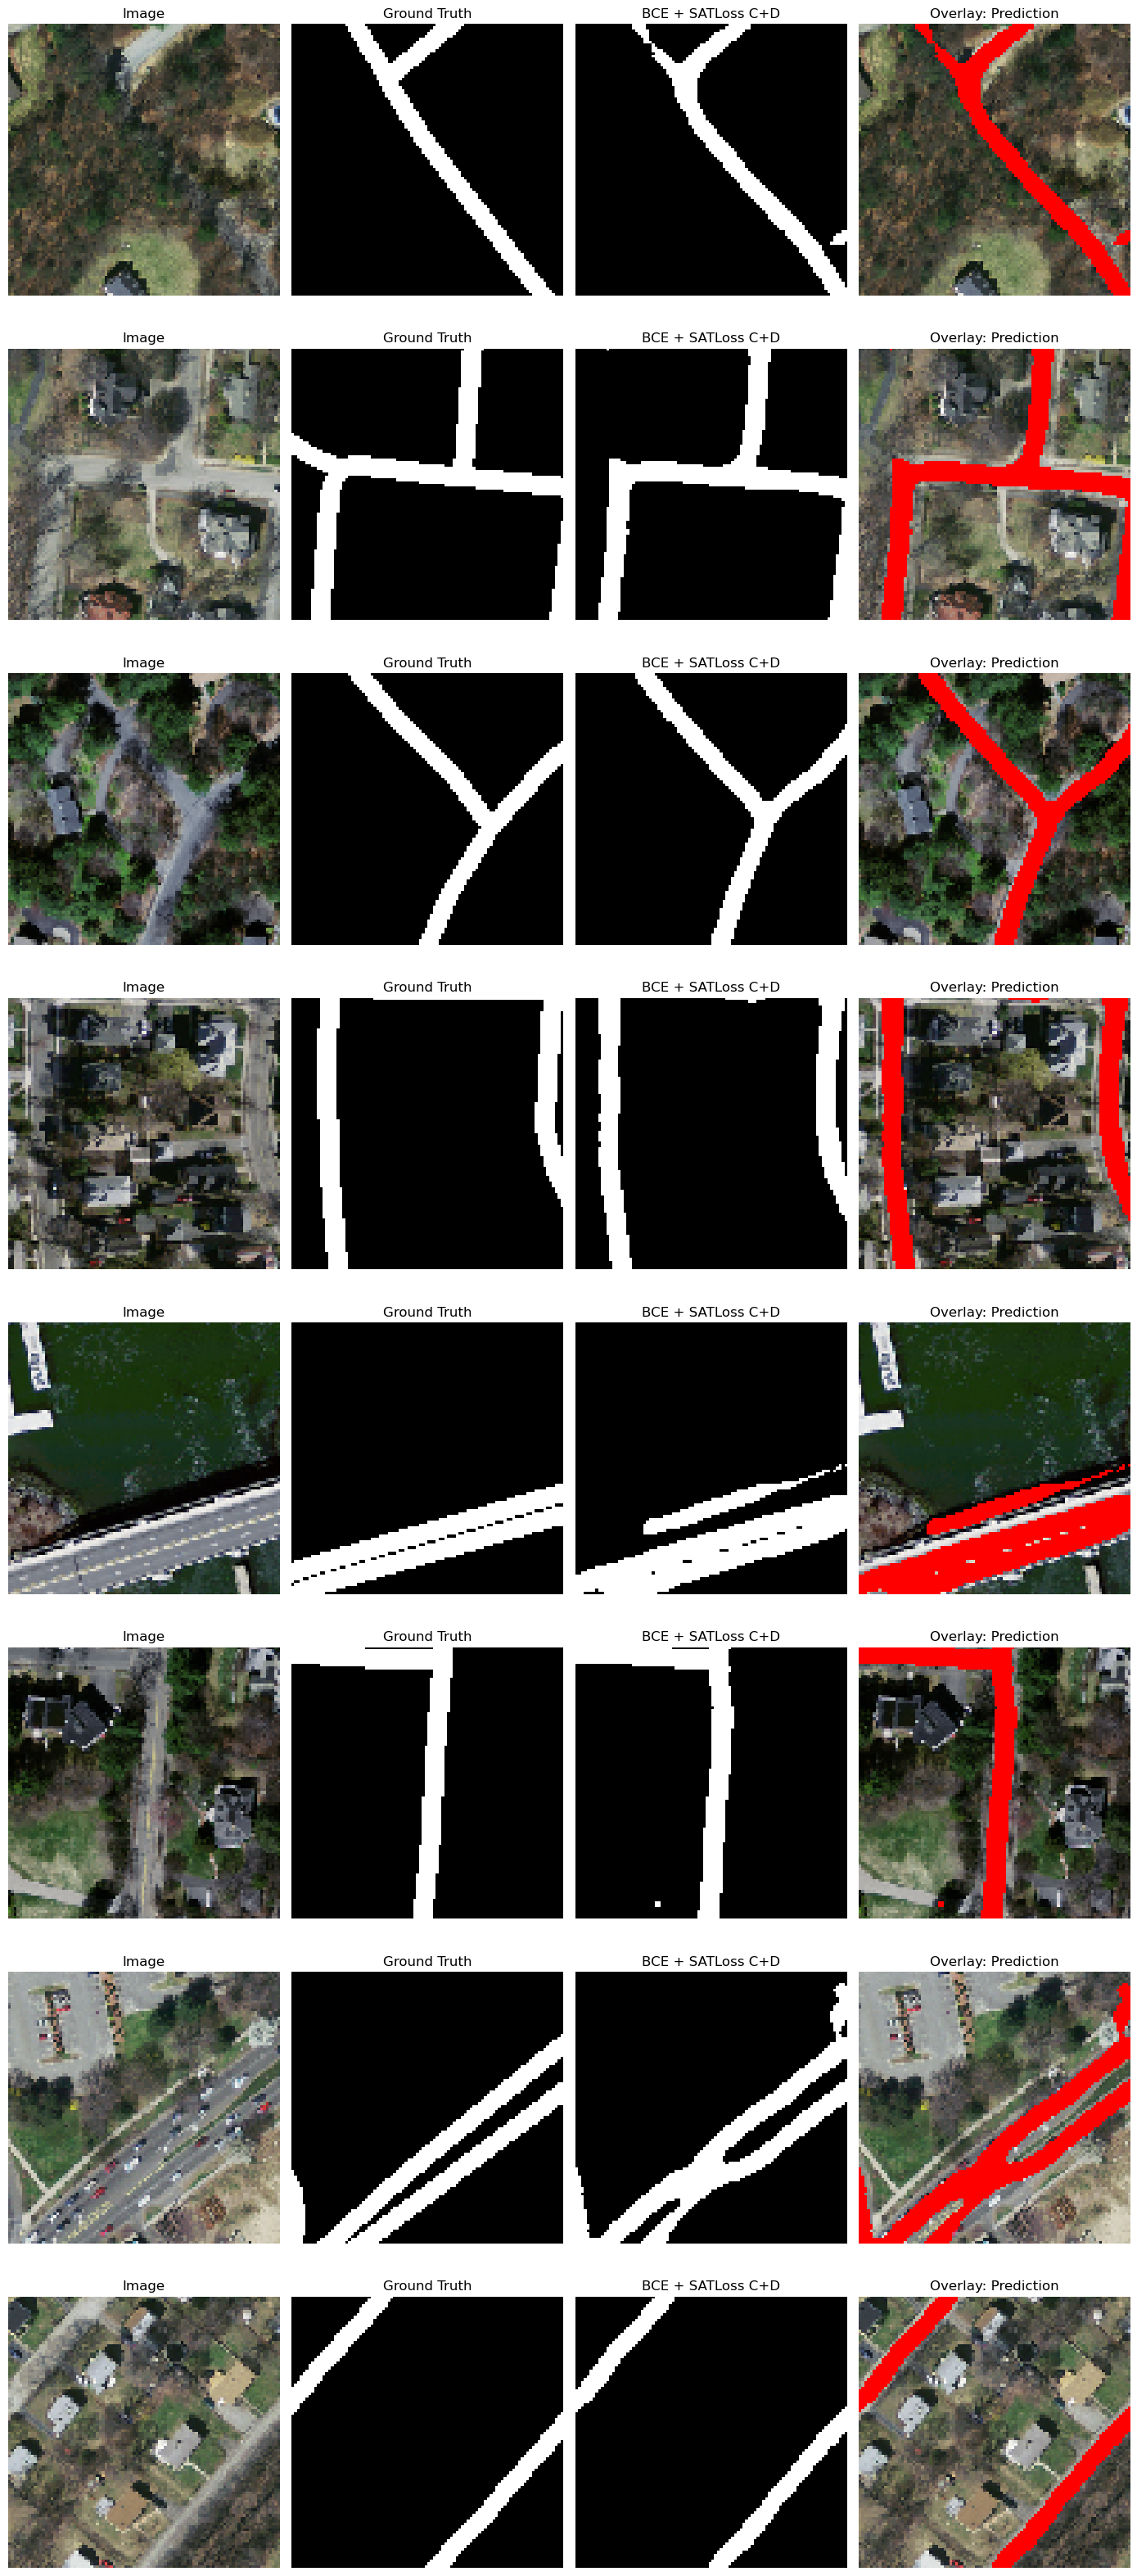


Saved BCE + SATLoss Creator-Destroyer visualization to:
final_thesis_figures/step21_bce_sat_creator_destroyer_visible_complex_predictions.png


In [22]:
# ============================================================
# STEP 21: Visualize BCE + SATLoss Creator-Destroyer predictions
# ============================================================
# This step visualizes predictions from the BCE + SATLoss Creator-Destroyer model.
#
# We choose visible complex road patches from the test set.
# This helps us inspect whether adding destroyer features improves:
#   - false component removal
#   - false loop reduction
#   - road connectivity
#
# Columns:
#   Image | Ground Truth | Creator-Destroyer Prediction | Overlay
#
# Red overlay = predicted road pixels.
# ============================================================

# ----------------------------
# Load best BCE + SATLoss Creator-Destroyer model
# ----------------------------
final_bce_sat_cd_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_bce_sat_cd_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_bce_sat_creator_destroyer_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best learned threshold
# ----------------------------
final_bce_sat_cd_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_bce_sat_cd_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_bce_sat_creator_destroyer_threshold.pth"),
        map_location=device
    )
)

final_bce_sat_cd_model.eval()
final_bce_sat_cd_threshold.eval()


# ----------------------------
# Select visible complex road patches
# ----------------------------
complex_test_indices = []

for i, p in enumerate(test_patches):
    image_mean = p["image_patch"].mean()
    image_std = p["image_patch"].std()

    if (
        p["road_ratio"] >= 0.08
        and image_mean > 40
        and image_std > 10
    ):
        complex_test_indices.append(i)

num_samples = 8

if len(complex_test_indices) >= num_samples:
    selected_indices = random.sample(complex_test_indices, num_samples)
else:
    fallback_indices = [
        i for i, p in enumerate(test_patches)
        if p["road_ratio"] >= 0.08
    ]

    selected_indices = random.sample(
        fallback_indices,
        min(num_samples, len(fallback_indices))
    )

print("Number of visible complex patches:", len(complex_test_indices))
print("Selected test patch indices:", selected_indices)


# ----------------------------
# Visualize predictions
# ----------------------------
plt.figure(figsize=(14, 4 * len(selected_indices)))

threshold_value = final_bce_sat_cd_threshold().item()
print("Learned threshold used:", threshold_value)

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_bce_sat_cd_model(image_tensor)
        probs = torch.sigmoid(logits)
        threshold = final_bce_sat_cd_threshold()
        pred = (probs > threshold).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    image_display = image_patch.astype(np.float32) / 255.0
    mask_np = mask_patch.astype(np.uint8)

    overlay = image_display.copy()
    overlay[pred_np == 1] = [1, 0, 0]

    print(f"\nPatch {row + 1}")
    print("Source image:", os.path.basename(patch["image_path"]))
    print("Location: top =", patch["top"], ", left =", patch["left"])
    print(f"Image mean               : {image_patch.mean():.2f}")
    print(f"Image std                : {image_patch.std():.2f}")
    print(f"Ground-truth road ratio  : {patch['road_ratio'] * 100:.2f}%")
    print(f"Predicted road ratio     : {pred_np.mean() * 100:.2f}%")

    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("BCE + SATLoss C+D")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay: Prediction")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step21_bce_sat_creator_destroyer_visible_complex_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved BCE + SATLoss Creator-Destroyer visualization to:")
print(save_path)

# 4: Train Hybrid U-Net without SATLoss(  BCE + Dice loss + soft-clDice loss )

In [30]:
# ============================================================
# STEP 22: Train Hybrid U-Net without SATLoss
# ============================================================
# This model uses:
#     BCE + Dice loss + soft-clDice loss
#
# Training loss:
#     L = BCE + Dice + soft-clDice
#
# This model does not use SATLoss.
#
# Purpose:
# We use this model to check how much improvement comes from
# Dice and clDice alone before adding topology-aware SATLoss.
# ============================================================

HYBRID_BASE_EPOCHS = 20
HYBRID_BASE_LR = 1e-4
HYBRID_BASE_WEIGHT_DECAY = 1e-4

# ----------------------------
# Create model and threshold
# ----------------------------
hybrid_base_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

hybrid_base_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

# ----------------------------
# Optimizer
# ----------------------------
hybrid_base_optimizer = optim.Adam(
    list(hybrid_base_model.parameters()) +
    list(hybrid_base_threshold.parameters()),
    lr=HYBRID_BASE_LR,
    weight_decay=HYBRID_BASE_WEIGHT_DECAY
)

# ----------------------------
# Scheduler
# ----------------------------
hybrid_base_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    hybrid_base_optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

# ----------------------------
# Mixed precision scaler
# ----------------------------
scaler = torch.cuda.amp.GradScaler()

# ----------------------------
# Training history
# ----------------------------
hybrid_base_history = {
    "train_total_loss": [],
    "train_bce_loss": [],
    "train_dice_loss": [],
    "train_cldice_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": [],
    "threshold": []
}


def train_one_epoch_hybrid_base(
    model,
    threshold_module,
    loader,
    optimizer,
    scaler,
    device
):
    """
    Train one epoch using:
        BCE + Dice loss + soft-clDice loss

    The threshold is included in the optimizer for consistency.
    However, without threshold Dice loss, the threshold mostly affects
    validation/testing, not the main training loss.
    """

    model.train()
    threshold_module.train()

    total_loss = 0.0
    total_bce = 0.0
    total_dice = 0.0
    total_cldice = 0.0

    for images, masks in tqdm(loader, desc="Training Hybrid Base"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(images)
            probs = torch.sigmoid(logits)

            bce = bce_loss_fn(logits, masks)
            dloss = dice_loss(probs, masks)
            closs = soft_cldice_loss(
                probs,
                masks,
                iterations=CLDICE_ITERATIONS
            )

            loss = bce + dloss + closs

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_bce += bce.item()
        total_dice += dloss.item()
        total_cldice += closs.item()

    return {
        "loss": total_loss / len(loader),
        "bce": total_bce / len(loader),
        "dice": total_dice / len(loader),
        "cldice": total_cldice / len(loader)
    }


# ----------------------------
# Best model tracking
# ----------------------------
best_hybrid_base_dice = -1.0
best_hybrid_base_state = None
best_hybrid_base_threshold_state = None


# ----------------------------
# Training loop
# ----------------------------
for epoch in range(HYBRID_BASE_EPOCHS):

    print(f"\nHybrid Base Epoch {epoch + 1}/{HYBRID_BASE_EPOCHS}")
    print("-" * 60)

    train_metrics = train_one_epoch_hybrid_base(
        hybrid_base_model,
        hybrid_base_threshold,
        train_loader,
        hybrid_base_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_model(
        hybrid_base_model,
        hybrid_base_threshold,
        val_loader,
        device
    )

    hybrid_base_scheduler.step(val_metrics["dice"])

    # ----------------------------
    # Save history
    # ----------------------------
    hybrid_base_history["train_total_loss"].append(train_metrics["loss"])
    hybrid_base_history["train_bce_loss"].append(train_metrics["bce"])
    hybrid_base_history["train_dice_loss"].append(train_metrics["dice"])
    hybrid_base_history["train_cldice_loss"].append(train_metrics["cldice"])

    hybrid_base_history["val_loss"].append(val_metrics["loss"])
    hybrid_base_history["val_accuracy"].append(val_metrics["accuracy"])
    hybrid_base_history["val_dice"].append(val_metrics["dice"])
    hybrid_base_history["val_cldice"].append(val_metrics["cldice"])
    hybrid_base_history["val_beta0_error"].append(val_metrics["beta0_error"])
    hybrid_base_history["val_beta1_error"].append(val_metrics["beta1_error"])
    hybrid_base_history["threshold"].append(val_metrics["threshold"])

    # ----------------------------
    # Print metrics
    # ----------------------------
    print(f"Train Total Loss : {train_metrics['loss']:.4f}")
    print(f"Train BCE Loss   : {train_metrics['bce']:.4f}")
    print(f"Train Dice Loss  : {train_metrics['dice']:.4f}")
    print(f"Train clDice Loss: {train_metrics['cldice']:.4f}")

    print(f"Val BCE Loss     : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice         : {val_metrics['dice']:.4f}")
    print(f"Val clDice       : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err    : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err    : {val_metrics['beta1_error']:.4f}")
    print(f"Learned thresh   : {val_metrics['threshold']:.4f}")

    current_lr = hybrid_base_optimizer.param_groups[0]["lr"]
    print(f"Learning rate    : {current_lr:.6f}")

    # ----------------------------
    # Save best model
    # ----------------------------
    if val_metrics["dice"] > best_hybrid_base_dice:

        best_hybrid_base_dice = val_metrics["dice"]

        best_hybrid_base_state = copy.deepcopy(
            hybrid_base_model.state_dict()
        )

        best_hybrid_base_threshold_state = copy.deepcopy(
            hybrid_base_threshold.state_dict()
        )

        torch.save(
            best_hybrid_base_state,
            os.path.join(
                SAVE_DIR,
                "best_hybrid_base_model.pth"
            )
        )

        torch.save(
            best_hybrid_base_threshold_state,
            os.path.join(
                SAVE_DIR,
                "best_hybrid_base_threshold.pth"
            )
        )

        print("Best Hybrid Base model saved.")

print("\nHybrid Base training finished.")
print("Best validation Dice:", best_hybrid_base_dice)


Hybrid Base Epoch 1/20
------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:18<00:00, 34.71it/s]


Train Total Loss : 1.0817
Train BCE Loss   : 0.2393
Train Dice Loss  : 0.5247
Train clDice Loss: 0.3177
Val BCE Loss     : 0.1930
Val Accuracy     : 0.9334
Val Dice         : 0.6459
Val clDice       : 0.6904
Val beta0 err    : 0.6568
Val beta1 err    : 0.0928
Learned thresh   : 0.5000
Learning rate    : 0.000100
Best Hybrid Base model saved.

Hybrid Base Epoch 2/20
------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 35.22it/s]


Train Total Loss : 0.8728
Train BCE Loss   : 0.1893
Train Dice Loss  : 0.4212
Train clDice Loss: 0.2623
Val BCE Loss     : 0.1689
Val Accuracy     : 0.9434
Val Dice         : 0.6808
Val clDice       : 0.7169
Val beta0 err    : 0.6842
Val beta1 err    : 0.0872
Learned thresh   : 0.5000
Learning rate    : 0.000100
Best Hybrid Base model saved.

Hybrid Base Epoch 3/20
------------------------------------------------------------


...

Train Total Loss : 0.6255
Train BCE Loss   : 0.1412
Train Dice Loss  : 0.3186
Train clDice Loss: 0.1657
Val BCE Loss     : 0.1678
Val Accuracy     : 0.9506
Val Dice         : 0.7154
Val clDice       : 0.7399
Val beta0 err    : 0.5086
Val beta1 err    : 0.0952
Learned thresh   : 0.5000
Learning rate    : 0.000050

Hybrid Base Epoch 19/20
------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 38.24it/s]


Train Total Loss : 0.6146
Train BCE Loss   : 0.1389
Train Dice Loss  : 0.3140
Train clDice Loss: 0.1617
Val BCE Loss     : 0.1697
Val Accuracy     : 0.9500
Val Dice         : 0.7134
Val clDice       : 0.7353
Val beta0 err    : 0.4772
Val beta1 err    : 0.0944
Learned thresh   : 0.5000
Learning rate    : 0.000050

Hybrid Base Epoch 20/20
------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.38it/s]

Train Total Loss : 0.6042
Train BCE Loss   : 0.1367
Train Dice Loss  : 0.3094
Train clDice Loss: 0.1581
Val BCE Loss     : 0.1707
Val Accuracy     : 0.9499
Val Dice         : 0.7159
Val clDice       : 0.7433
Val beta0 err    : 0.5436
Val beta1 err    : 0.1078
Learned thresh   : 0.5000
Learning rate    : 0.000050

Hybrid Base training finished.
Best validation Dice: 0.7217994178295135


In [31]:
# ============================================================
# STEP 23: Final evaluation of Hybrid Base model
# ============================================================
# This step evaluates the best Hybrid Base model on the test set.
#
# Model:
#     BCE + Dice + soft-clDice
#
# This model does not use SATLoss.
#
# Purpose:
# It tells us how much improvement comes from Dice and clDice
# before adding topology-aware SATLoss.
# ============================================================

# ----------------------------
# Load best Hybrid Base model
# ----------------------------
final_hybrid_base_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_hybrid_base_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_base_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best learned threshold
# ----------------------------
final_hybrid_base_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_hybrid_base_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_base_threshold.pth"),
        map_location=device
    )
)

final_hybrid_base_model.eval()
final_hybrid_base_threshold.eval()

# ----------------------------
# Evaluate on test set
# ----------------------------
hybrid_base_test_metrics = evaluate_model(
    final_hybrid_base_model,
    final_hybrid_base_threshold,
    test_loader,
    device
)

# ----------------------------
# Print final test results
# ----------------------------
print("FINAL TEST RESULTS: Hybrid Base")
print("-------------------------------")
print(f"Test BCE Loss   : {hybrid_base_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {hybrid_base_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {hybrid_base_test_metrics['dice']:.4f}")
print(f"Test clDice     : {hybrid_base_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {hybrid_base_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {hybrid_base_test_metrics['beta1_error']:.4f}")
print(f"Learned thresh  : {hybrid_base_test_metrics['threshold']:.4f}")

# ----------------------------
# Save result for comparison table
# ----------------------------
hybrid_base_result = {
    "Model": "BCE + Dice + clDice",
    "Loss": hybrid_base_test_metrics["loss"],
    "Accuracy": hybrid_base_test_metrics["accuracy"],
    "Dice": hybrid_base_test_metrics["dice"],
    "clDice": hybrid_base_test_metrics["cldice"],
    "beta0_error": hybrid_base_test_metrics["beta0_error"],
    "beta1_error": hybrid_base_test_metrics["beta1_error"],
    "Threshold": hybrid_base_test_metrics["threshold"]
}

hybrid_base_results_df = pd.DataFrame([hybrid_base_result])

hybrid_base_results_path = os.path.join(
    RESULTS_DIR,
    "hybrid_base_test_results.csv"
)

hybrid_base_results_df.to_csv(
    hybrid_base_results_path,
    index=False
)

print("\nSaved Hybrid Base results to:")
print(hybrid_base_results_path)

Evaluating: 100%|██████████| 625/625 [00:16<00:00, 37.44it/s]

FINAL TEST RESULTS: Hybrid Base
-------------------------------
Test BCE Loss   : 0.1681
Test Accuracy   : 0.9524
Test Dice       : 0.7207
Test clDice     : 0.7471
Test beta0 err  : 0.4688
Test beta1 err  : 0.1146
Learned thresh  : 0.5000

Saved Hybrid Base results to:
final_thesis_results/hybrid_base_test_results.csv


Number of visible complex patches: 2241
Selected test patch indices: [2598, 1758, 4747, 822, 1386, 1852, 831, 1836]
Learned threshold used: 0.5

Patch 1
Source image: 24478855_15.tiff
Location: top = 432 , left = 336
Image mean               : 96.45
Image std                : 38.47
Ground-truth road ratio  : 14.85%
Predicted road ratio     : 11.73%

Patch 2
Source image: 18328930_15.tiff
Location: top = 720 , left = 1152
Image mean               : 102.06
Image std                : 46.49
Ground-truth road ratio  : 11.35%
Predicted road ratio     : 11.78%

Patch 3
Source image: 23278960_15.tiff
Location: top = 1056 , left = 432
Image mean               : 84.36
Image std                : 43.75
Ground-truth road ratio  : 11.70%
Predicted road ratio     : 10.73%

Patch 4
Source image: 24028990_15.tiff
Location: top = 960 , left = 432
Image mean               : 92.57
Image std                : 44.38
Ground-truth road ratio  : 9.27%
Predicted road ratio     : 17.87%

Patch 5
Source image: 237

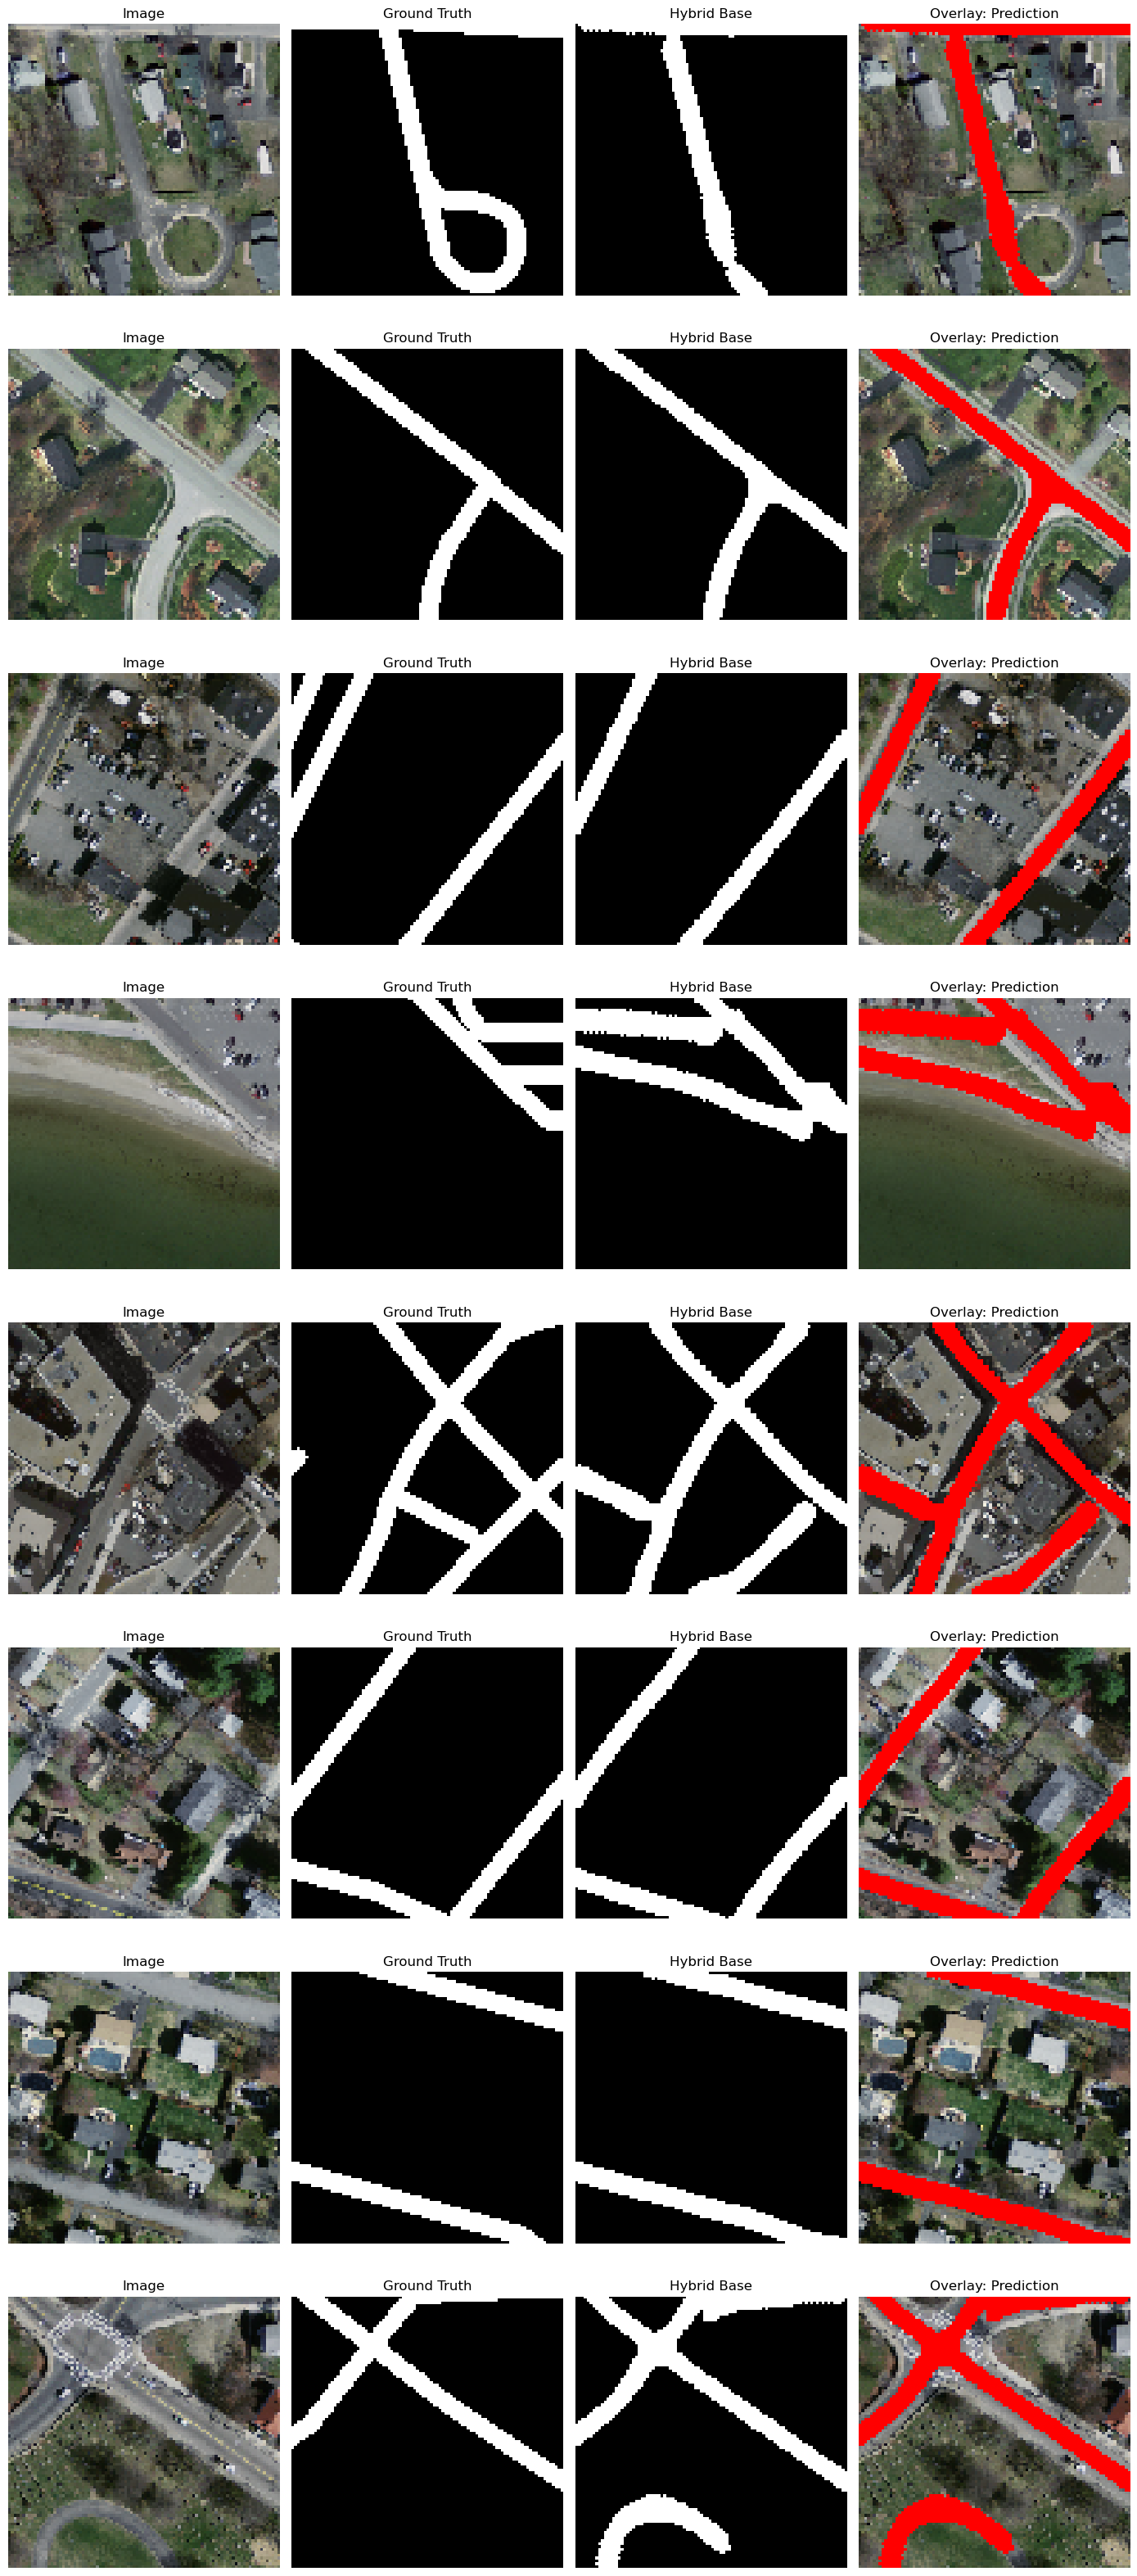


Saved Hybrid Base visualization to:
final_thesis_figures/step24_hybrid_base_visible_complex_predictions.png


In [32]:
# ============================================================
# STEP 24: Visualize Hybrid Base predictions on visible complex road patches
# ============================================================
# This step visualizes predictions from the Hybrid Base model.
#
# Model:
#     BCE + Dice + soft-clDice
#
# We choose visible complex road patches from the test set to avoid
# blank-looking images and to focus on difficult road structures.
#
# Columns:
#   Image | Ground Truth | Hybrid Base Prediction | Overlay
#
# Red overlay = predicted road pixels.
# ============================================================

# ----------------------------
# Load best Hybrid Base model
# ----------------------------
final_hybrid_base_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_hybrid_base_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_base_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best learned threshold
# ----------------------------
final_hybrid_base_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_hybrid_base_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_base_threshold.pth"),
        map_location=device
    )
)

final_hybrid_base_model.eval()
final_hybrid_base_threshold.eval()


# ----------------------------
# Select visible complex road patches
# ----------------------------
complex_test_indices = []

for i, p in enumerate(test_patches):
    image_mean = p["image_patch"].mean()
    image_std = p["image_patch"].std()

    if (
        p["road_ratio"] >= 0.08
        and image_mean > 40
        and image_std > 10
    ):
        complex_test_indices.append(i)

num_samples = 8

if len(complex_test_indices) >= num_samples:
    selected_indices = random.sample(complex_test_indices, num_samples)
else:
    fallback_indices = [
        i for i, p in enumerate(test_patches)
        if p["road_ratio"] >= 0.08
    ]

    selected_indices = random.sample(
        fallback_indices,
        min(num_samples, len(fallback_indices))
    )

print("Number of visible complex patches:", len(complex_test_indices))
print("Selected test patch indices:", selected_indices)


# ----------------------------
# Visualize predictions
# ----------------------------
plt.figure(figsize=(14, 4 * len(selected_indices)))

threshold_value = final_hybrid_base_threshold().item()
print("Learned threshold used:", threshold_value)

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_hybrid_base_model(image_tensor)
        probs = torch.sigmoid(logits)
        threshold = final_hybrid_base_threshold()
        pred = (probs > threshold).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    image_display = image_patch.astype(np.float32) / 255.0
    mask_np = mask_patch.astype(np.uint8)

    overlay = image_display.copy()
    overlay[pred_np == 1] = [1, 0, 0]

    print(f"\nPatch {row + 1}")
    print("Source image:", os.path.basename(patch["image_path"]))
    print("Location: top =", patch["top"], ", left =", patch["left"])
    print(f"Image mean               : {image_patch.mean():.2f}")
    print(f"Image std                : {image_patch.std():.2f}")
    print(f"Ground-truth road ratio  : {patch['road_ratio'] * 100:.2f}%")
    print(f"Predicted road ratio     : {pred_np.mean() * 100:.2f}%")

    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("Hybrid Base")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay: Prediction")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step24_hybrid_base_visible_complex_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved Hybrid Base visualization to:")
print(save_path)

# 5: Train Hybrid + SATLoss Creator model( BCE + Dice + soft-clDice + lambda_topo * SATLoss_creator)

In [23]:
# ============================================================
# STEP 25: Train Hybrid + SATLoss Creator model
# ============================================================
# This model combines pixel, overlap, local connectivity,
# and topology-aware losses.
#
# Training loss:
#     L = BCE + Dice + soft-clDice + lambda_topo * SATLoss_creator
#
# Here, lambda_topo is learnable:
#     lambda_topo = lambda_max * sigmoid(alpha)
#
# Purpose:
# This checks whether creator-only SATLoss improves the Hybrid Base model.
# ============================================================

HYBRID_CREATOR_EPOCHS = 20
HYBRID_CREATOR_LR = 1e-4
HYBRID_CREATOR_WEIGHT_DECAY = 1e-4

TOPO_BATCH_LIMIT = 4
MAX_TOPO_FEATURES = 30

# ----------------------------
# Create model, threshold, and learnable lambda
# ----------------------------
hybrid_creator_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

hybrid_creator_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

hybrid_creator_lambda = LearnableLambda(
    init_value=1e-4,
    max_value=1e-3
).to(device)

print("Initial topology lambda:", hybrid_creator_lambda().item())


# ----------------------------
# Optimizer
# ----------------------------
hybrid_creator_optimizer = optim.Adam(
    list(hybrid_creator_model.parameters()) +
    list(hybrid_creator_threshold.parameters()) +
    list(hybrid_creator_lambda.parameters()),
    lr=HYBRID_CREATOR_LR,
    weight_decay=HYBRID_CREATOR_WEIGHT_DECAY
)


# ----------------------------
# Scheduler
# ----------------------------
hybrid_creator_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    hybrid_creator_optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ----------------------------
# Mixed precision scaler
# ----------------------------
scaler = torch.cuda.amp.GradScaler()


# ----------------------------
# Training history
# ----------------------------
hybrid_creator_history = {
    "train_total_loss": [],
    "train_bce_loss": [],
    "train_dice_loss": [],
    "train_cldice_loss": [],
    "train_sat_loss": [],
    "lambda_topo": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": [],
    "threshold": []
}


def train_one_epoch_hybrid_creator(
    model,
    threshold_module,
    lambda_module,
    loader,
    optimizer,
    scaler,
    device
):
    """
    Train one epoch using:
        BCE + Dice + soft-clDice + learnable_lambda * SATLoss Creator
    """

    model.train()
    threshold_module.train()
    lambda_module.train()

    total_loss = 0.0
    total_bce = 0.0
    total_dice = 0.0
    total_cldice = 0.0
    total_sat = 0.0

    for images, masks in tqdm(loader, desc="Training Hybrid + SATLoss Creator"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            logits = model(images)
            probs = torch.sigmoid(logits)

            bce = bce_loss_fn(logits, masks)
            dloss = dice_loss(probs, masks)
            closs = soft_cldice_loss(
                probs,
                masks,
                iterations=CLDICE_ITERATIONS
            )

        sat = satloss_batch(
            probs.float(),
            masks.float(),
            mode="creator",
            batch_limit=TOPO_BATCH_LIMIT,
            max_features=MAX_TOPO_FEATURES
        )

        lambda_topo = lambda_module()

        loss = (
            bce +
            dloss +
            closs +
            lambda_topo * sat
        )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_bce += bce.item()
        total_dice += dloss.item()
        total_cldice += closs.item()
        total_sat += sat.item()

    return {
        "loss": total_loss / len(loader),
        "bce": total_bce / len(loader),
        "dice": total_dice / len(loader),
        "cldice": total_cldice / len(loader),
        "sat": total_sat / len(loader),
        "lambda_topo": lambda_module().item()
    }


# ----------------------------
# Best model tracking
# ----------------------------
best_hybrid_creator_dice = -1.0


# ----------------------------
# Training loop
# ----------------------------
for epoch in range(HYBRID_CREATOR_EPOCHS):

    print(f"\nHybrid + SATLoss Creator Epoch {epoch + 1}/{HYBRID_CREATOR_EPOCHS}")
    print("-" * 70)

    train_metrics = train_one_epoch_hybrid_creator(
        hybrid_creator_model,
        hybrid_creator_threshold,
        hybrid_creator_lambda,
        train_loader,
        hybrid_creator_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_model(
        hybrid_creator_model,
        hybrid_creator_threshold,
        val_loader,
        device
    )

    hybrid_creator_scheduler.step(val_metrics["dice"])

    # ----------------------------
    # Save history
    # ----------------------------
    hybrid_creator_history["train_total_loss"].append(train_metrics["loss"])
    hybrid_creator_history["train_bce_loss"].append(train_metrics["bce"])
    hybrid_creator_history["train_dice_loss"].append(train_metrics["dice"])
    hybrid_creator_history["train_cldice_loss"].append(train_metrics["cldice"])
    hybrid_creator_history["train_sat_loss"].append(train_metrics["sat"])
    hybrid_creator_history["lambda_topo"].append(train_metrics["lambda_topo"])

    hybrid_creator_history["val_loss"].append(val_metrics["loss"])
    hybrid_creator_history["val_accuracy"].append(val_metrics["accuracy"])
    hybrid_creator_history["val_dice"].append(val_metrics["dice"])
    hybrid_creator_history["val_cldice"].append(val_metrics["cldice"])
    hybrid_creator_history["val_beta0_error"].append(val_metrics["beta0_error"])
    hybrid_creator_history["val_beta1_error"].append(val_metrics["beta1_error"])
    hybrid_creator_history["threshold"].append(val_metrics["threshold"])

    # ----------------------------
    # Print metrics
    # ----------------------------
    print(f"Train Total Loss : {train_metrics['loss']:.4f}")
    print(f"Train BCE Loss   : {train_metrics['bce']:.4f}")
    print(f"Train Dice Loss  : {train_metrics['dice']:.4f}")
    print(f"Train clDice Loss: {train_metrics['cldice']:.4f}")
    print(f"Train SATLoss    : {train_metrics['sat']:.4f}")
    print(f"Learned lambda   : {train_metrics['lambda_topo']:.8f}")

    print(f"Val BCE Loss     : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice         : {val_metrics['dice']:.4f}")
    print(f"Val clDice       : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err    : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err    : {val_metrics['beta1_error']:.4f}")
    print(f"Learned thresh   : {val_metrics['threshold']:.4f}")

    current_lr = hybrid_creator_optimizer.param_groups[0]["lr"]
    print(f"Learning rate    : {current_lr:.6f}")

    # ----------------------------
    # Save best model
    # ----------------------------
    if val_metrics["dice"] > best_hybrid_creator_dice:

        best_hybrid_creator_dice = val_metrics["dice"]

        torch.save(
            copy.deepcopy(hybrid_creator_model.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_hybrid_sat_creator_model.pth"
            )
        )

        torch.save(
            copy.deepcopy(hybrid_creator_threshold.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_hybrid_sat_creator_threshold.pth"
            )
        )

        torch.save(
            copy.deepcopy(hybrid_creator_lambda.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_hybrid_sat_creator_lambda.pth"
            )
        )

        print("Best Hybrid + SATLoss Creator model, threshold, and lambda saved.")

print("\nHybrid + SATLoss Creator training finished.")
print("Best validation Dice:", best_hybrid_creator_dice)
print("Final learned lambda:", hybrid_creator_lambda().item())

Initial topology lambda: 0.00010000000474974513

Hybrid + SATLoss Creator Epoch 1/20
----------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.30it/s]


Train Total Loss : 1.0581
Train BCE Loss   : 0.2278
Train Dice Loss  : 0.5128
Train clDice Loss: 0.3175
Train SATLoss    : 0.1333
Learned lambda   : 0.00013731
Val BCE Loss     : 0.1783
Val Accuracy     : 0.9421
Val Dice         : 0.6631
Val clDice       : 0.6895
Val beta0 err    : 0.6768
Val beta1 err    : 0.0844
Learned thresh   : 0.5000
Learning rate    : 0.000100
Best Hybrid + SATLoss Creator model, threshold, and lambda saved.

Hybrid + SATLoss Creator Epoch 2/20
----------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 36.95it/s]


Train Total Loss : 0.8714
Train BCE Loss   : 0.1884
Train Dice Loss  : 0.4210
Train clDice Loss: 0.2619
Train SATLoss    : 0.1442
Learned lambda   : 0.00018348
Val BCE Loss     : 0.1680
Val Accuracy     : 0.9455
Val Dice         : 0.6906
Val clDice       : 0.7227
Val beta0 err    : 0.6348
Val beta1 err    : 0.0838
Learned thresh   : 0.5000
Learning rate    : 0.000100
Best Hybrid + SATLoss Creator model, threshold, and lambda saved.

Hybrid + SATLoss Creator Epoch 3/20
----------------------------------------------------------------------


...

Train Total Loss : 0.6206
Train BCE Loss   : 0.1403
Train Dice Loss  : 0.3164
Train clDice Loss: 0.1638
Train SATLoss    : 0.1629
Learned lambda   : 0.00040333
Val BCE Loss     : 0.1698
Val Accuracy     : 0.9506
Val Dice         : 0.7184
Val clDice       : 0.7432
Val beta0 err    : 0.5138
Val beta1 err    : 0.0840
Learned thresh   : 0.5000
Learning rate    : 0.000050

Hybrid + SATLoss Creator Epoch 19/20
----------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.54it/s]


Train Total Loss : 0.6126
Train BCE Loss   : 0.1387
Train Dice Loss  : 0.3130
Train clDice Loss: 0.1607
Train SATLoss    : 0.1663
Learned lambda   : 0.00040279
Val BCE Loss     : 0.1654
Val Accuracy     : 0.9505
Val Dice         : 0.7148
Val clDice       : 0.7371
Val beta0 err    : 0.5162
Val beta1 err    : 0.0856
Learned thresh   : 0.5000
Learning rate    : 0.000025

Hybrid + SATLoss Creator Epoch 20/20
----------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.68it/s]

Train Total Loss : 0.5836
Train BCE Loss   : 0.1320
Train Dice Loss  : 0.3005
Train clDice Loss: 0.1511
Train SATLoss    : 0.1708
Learned lambda   : 0.00040222
Val BCE Loss     : 0.1676
Val Accuracy     : 0.9508
Val Dice         : 0.7189
Val clDice       : 0.7458
Val beta0 err    : 0.5478
Val beta1 err    : 0.0892
Learned thresh   : 0.5000
Learning rate    : 0.000025

Hybrid + SATLoss Creator training finished.
Best validation Dice: 0.7204482979297638
Final learned lambda: 0.00040222256211563945


In [24]:
# ============================================================
# STEP 26: Final evaluation of Hybrid + SATLoss Creator model
# ============================================================
# This step evaluates the best Hybrid + SATLoss Creator model on the test set.
#
# Model:
#     BCE + Dice + soft-clDice + SATLoss Creator
#
# Purpose:
# Compare this model with:
#   1. BCE only
#   2. BCE + SATLoss Creator
#   3. BCE + SATLoss Creator-Destroyer
#   4. Hybrid Base
# ============================================================

final_hybrid_creator_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_hybrid_creator_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_model.pth"),
        map_location=device
    )
)

final_hybrid_creator_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_hybrid_creator_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_threshold.pth"),
        map_location=device
    )
)

final_hybrid_creator_model.eval()
final_hybrid_creator_threshold.eval()

hybrid_creator_test_metrics = evaluate_model(
    final_hybrid_creator_model,
    final_hybrid_creator_threshold,
    test_loader,
    device
)

print("FINAL TEST RESULTS: Hybrid + SATLoss Creator")
print("--------------------------------------------")
print(f"Test BCE Loss   : {hybrid_creator_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {hybrid_creator_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {hybrid_creator_test_metrics['dice']:.4f}")
print(f"Test clDice     : {hybrid_creator_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {hybrid_creator_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {hybrid_creator_test_metrics['beta1_error']:.4f}")
print(f"Learned thresh  : {hybrid_creator_test_metrics['threshold']:.4f}")

hybrid_creator_result = {
    "Model": "BCE + Dice + clDice + SATLoss Creator",
    "Loss": hybrid_creator_test_metrics["loss"],
    "Accuracy": hybrid_creator_test_metrics["accuracy"],
    "Dice": hybrid_creator_test_metrics["dice"],
    "clDice": hybrid_creator_test_metrics["cldice"],
    "beta0_error": hybrid_creator_test_metrics["beta0_error"],
    "beta1_error": hybrid_creator_test_metrics["beta1_error"],
    "Threshold": hybrid_creator_test_metrics["threshold"]
}

hybrid_creator_results_df = pd.DataFrame([hybrid_creator_result])

hybrid_creator_results_path = os.path.join(
    RESULTS_DIR,
    "hybrid_sat_creator_test_results.csv"
)

hybrid_creator_results_df.to_csv(
    hybrid_creator_results_path,
    index=False
)

print("\nSaved Hybrid + SATLoss Creator results to:")
print(hybrid_creator_results_path)

Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.34it/s]


FINAL TEST RESULTS: Hybrid + SATLoss Creator
--------------------------------------------
Test BCE Loss   : 0.1601
Test Accuracy   : 0.9517
Test Dice       : 0.7209
Test clDice     : 0.7455
Test beta0 err  : 0.4916
Test beta1 err  : 0.0998
Learned thresh  : 0.5000

Saved Hybrid + SATLoss Creator results to:
final_thesis_results/hybrid_sat_creator_test_results.csv


Number of visible complex patches: 2241
Selected test patch indices: [4740, 1378, 343, 311, 1667, 1333, 4119, 929]
Learned threshold used: 0.5

Patch 1
Source image: 23128930_15.tiff
Location: top = 672 , left = 336
Image mean               : 93.00
Image std                : 56.43
Ground-truth road ratio  : 8.64%
Predicted road ratio     : 9.06%

Patch 2
Source image: 11128795_15.tiff
Location: top = 96 , left = 288
Image mean               : 108.24
Image std                : 41.44
Ground-truth road ratio  : 14.91%
Predicted road ratio     : 15.73%

Patch 3
Source image: 23729020_15.tiff
Location: top = 816 , left = 432
Image mean               : 94.32
Image std                : 45.23
Ground-truth road ratio  : 24.76%
Predicted road ratio     : 17.34%

Patch 4
Source image: 22979020_15.tiff
Location: top = 192 , left = 288
Image mean               : 59.42
Image std                : 28.90
Ground-truth road ratio  : 11.62%
Predicted road ratio     : 12.84%

Patch 5
Source image: 23879050

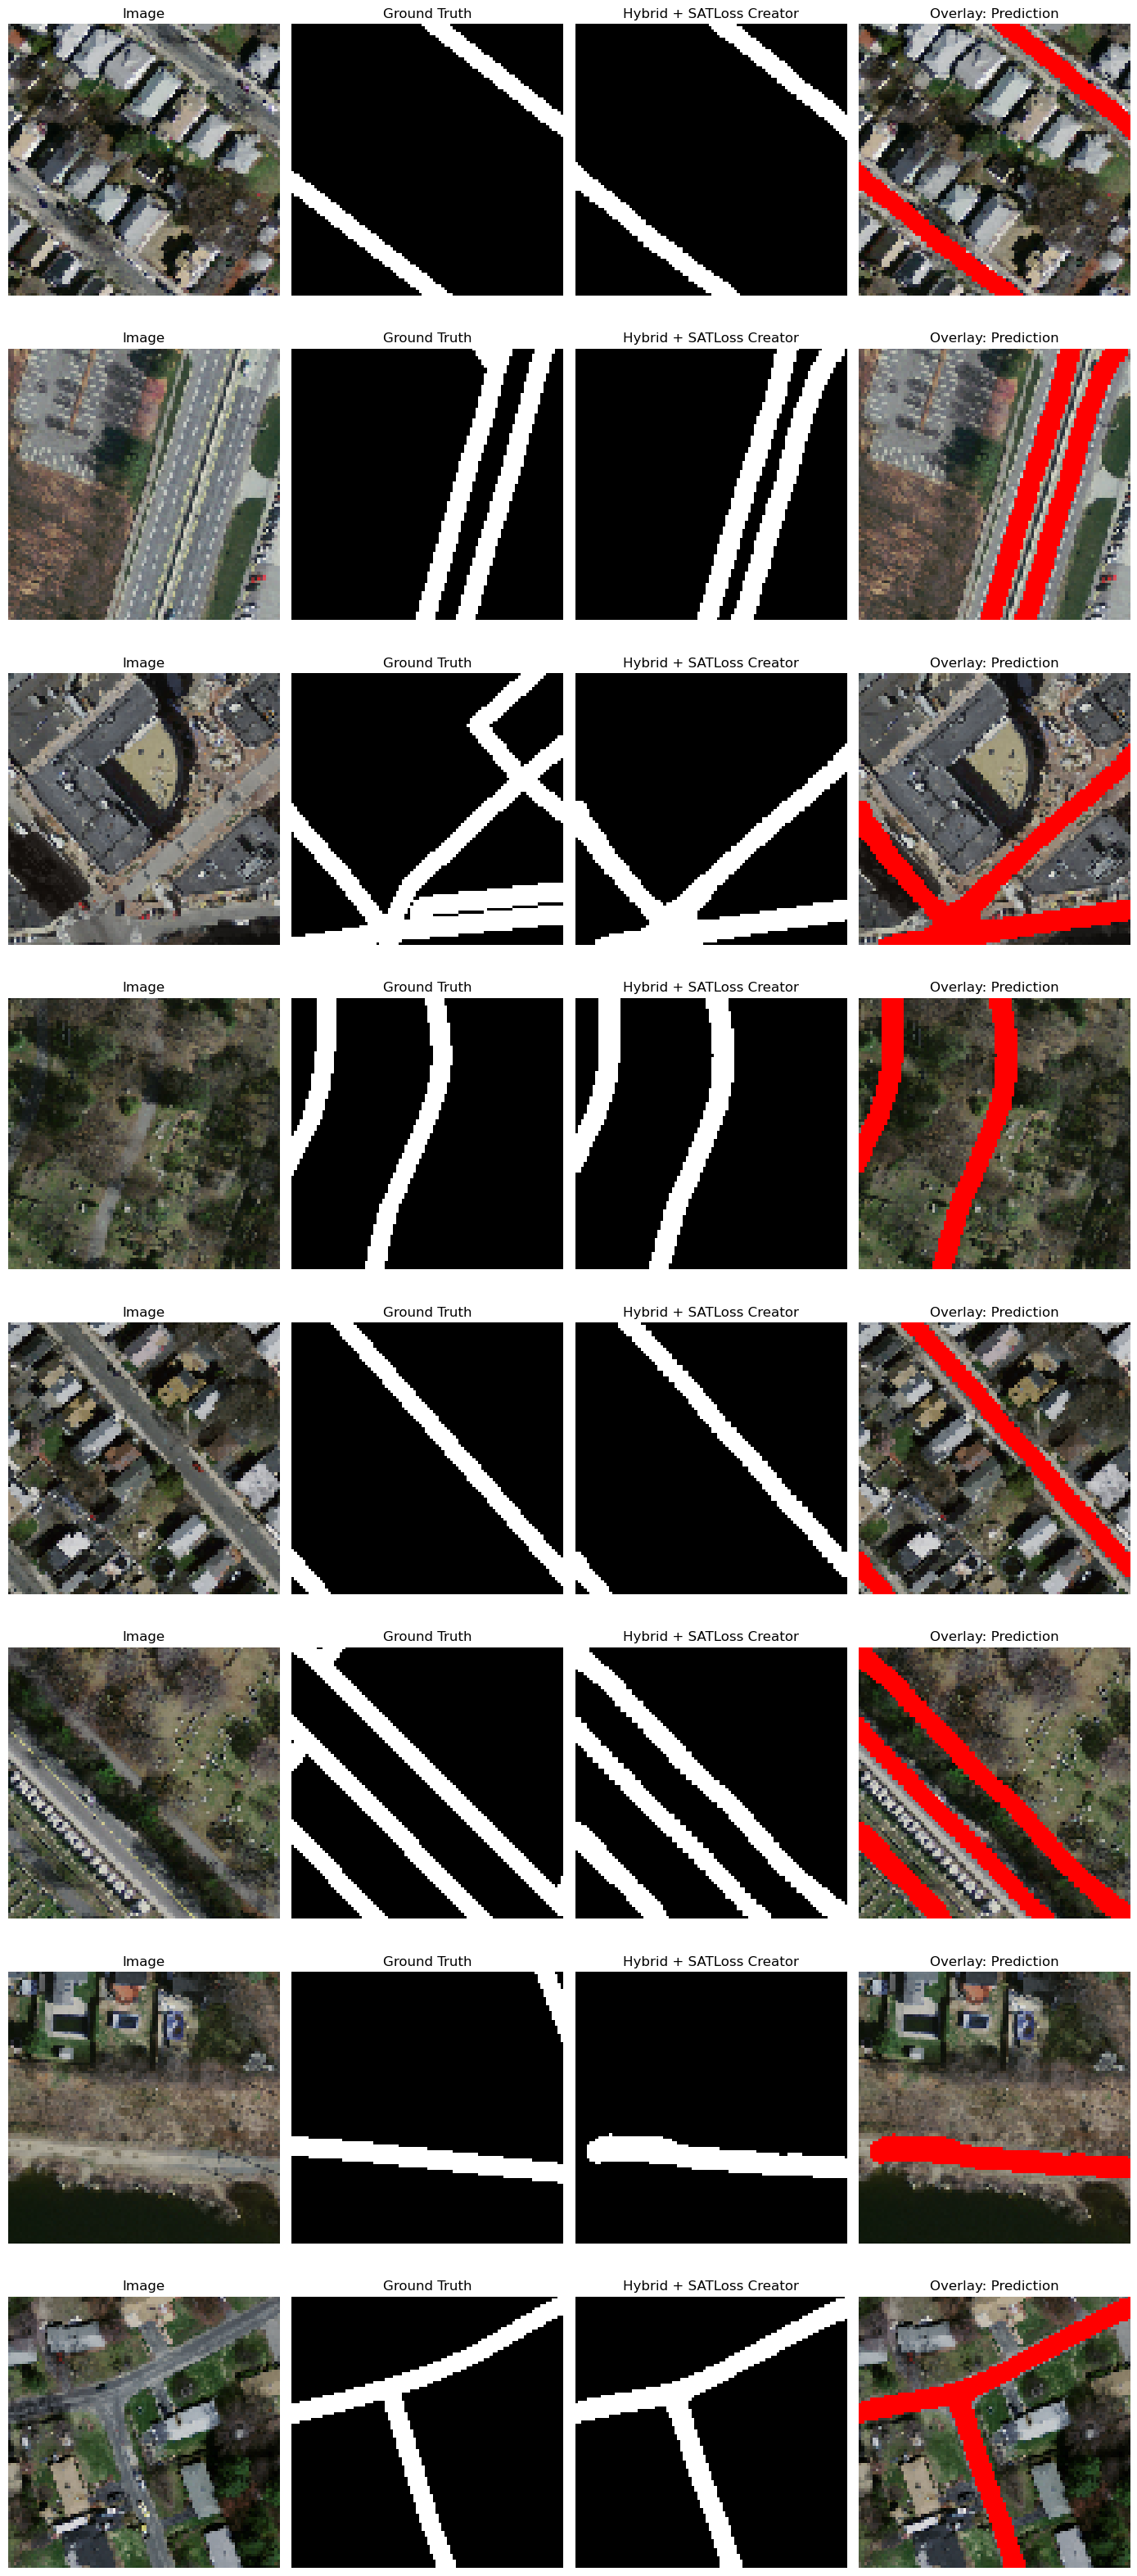


Saved Hybrid + SATLoss Creator visualization to:
final_thesis_figures/step27_hybrid_sat_creator_visible_complex_predictions.png


In [25]:
# ============================================================
# STEP 27: Visualize Hybrid + SATLoss Creator predictions
# ============================================================
# This step visualizes predictions from the Hybrid + SATLoss Creator model.
#
# Model:
#     BCE + Dice + soft-clDice + SATLoss Creator
#
# We select visible complex road patches to avoid blank images and to focus
# on difficult road structures such as branches, intersections, and curves.
#
# Columns:
#   Image | Ground Truth | Hybrid + SATLoss Creator Prediction | Overlay
#
# Red overlay = predicted road pixels.
# ============================================================

# ----------------------------
# Load best Hybrid + SATLoss Creator model
# ----------------------------
final_hybrid_creator_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_hybrid_creator_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best learned threshold
# ----------------------------
final_hybrid_creator_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_hybrid_creator_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_threshold.pth"),
        map_location=device
    )
)

final_hybrid_creator_model.eval()
final_hybrid_creator_threshold.eval()


# ----------------------------
# Select visible complex road patches
# ----------------------------
complex_test_indices = []

for i, p in enumerate(test_patches):
    image_mean = p["image_patch"].mean()
    image_std = p["image_patch"].std()

    if (
        p["road_ratio"] >= 0.08
        and image_mean > 40
        and image_std > 10
    ):
        complex_test_indices.append(i)

num_samples = 8

if len(complex_test_indices) >= num_samples:
    selected_indices = random.sample(complex_test_indices, num_samples)
else:
    fallback_indices = [
        i for i, p in enumerate(test_patches)
        if p["road_ratio"] >= 0.08
    ]

    selected_indices = random.sample(
        fallback_indices,
        min(num_samples, len(fallback_indices))
    )

print("Number of visible complex patches:", len(complex_test_indices))
print("Selected test patch indices:", selected_indices)


# ----------------------------
# Visualize predictions
# ----------------------------
plt.figure(figsize=(14, 4 * len(selected_indices)))

threshold_value = final_hybrid_creator_threshold().item()
print("Learned threshold used:", threshold_value)

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_hybrid_creator_model(image_tensor)
        probs = torch.sigmoid(logits)
        threshold = final_hybrid_creator_threshold()
        pred = (probs > threshold).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    image_display = image_patch.astype(np.float32) / 255.0
    mask_np = mask_patch.astype(np.uint8)

    overlay = image_display.copy()
    overlay[pred_np == 1] = [1, 0, 0]

    print(f"\nPatch {row + 1}")
    print("Source image:", os.path.basename(patch["image_path"]))
    print("Location: top =", patch["top"], ", left =", patch["left"])
    print(f"Image mean               : {image_patch.mean():.2f}")
    print(f"Image std                : {image_patch.std():.2f}")
    print(f"Ground-truth road ratio  : {patch['road_ratio'] * 100:.2f}%")
    print(f"Predicted road ratio     : {pred_np.mean() * 100:.2f}%")

    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("Hybrid + SATLoss Creator")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay: Prediction")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step27_hybrid_sat_creator_visible_complex_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved Hybrid + SATLoss Creator visualization to:")
print(save_path)

# 6: Train Hybrid + SATLoss Creator-Destroyer model

In [27]:
# ============================================================
# STEP 28: Train Hybrid + SATLoss Creator-Destroyer model
# ============================================================
# This model combines:
#   BCE + Dice + soft-clDice + SATLoss Creator-Destroyer
#
# Training loss:
#   L = BCE + Dice + soft-clDice + lambda_topo * SATLoss_creator_destroyer
#
# Here, lambda_topo is learnable:
#   lambda_topo = lambda_max * sigmoid(alpha)
#
# The model starts from the best Hybrid + SATLoss Creator checkpoint.
# ============================================================

# ----------------------------
# Correct soft-clDice functions
# ----------------------------
CLDICE_ITERATIONS = 3


def soft_erode(img):
    p1 = -F.max_pool2d(
        -img,
        kernel_size=(3, 1),
        stride=1,
        padding=(1, 0)
    )

    p2 = -F.max_pool2d(
        -img,
        kernel_size=(1, 3),
        stride=1,
        padding=(0, 1)
    )

    return torch.min(p1, p2)


def soft_dilate(img):
    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):
    return soft_dilate(soft_erode(img))


def soft_skeletonize(img, iterations=3):
    img = img.float()

    opened = soft_open(img)
    skeleton = F.relu(img - opened)

    for _ in range(iterations):
        img = soft_erode(img)
        opened = soft_open(img)

        delta = F.relu(img - opened)
        skeleton = skeleton + F.relu(delta - skeleton * delta)

    return skeleton


def soft_cldice_loss(probs, targets, iterations=3, eps=1e-8):
    probs = probs.float()
    targets = targets.float()

    skel_pred = soft_skeletonize(
        probs,
        iterations=iterations
    )

    skel_true = soft_skeletonize(
        targets,
        iterations=iterations
    )

    tprec = (skel_pred * targets).sum(dim=(1, 2, 3)) / (
        skel_pred.sum(dim=(1, 2, 3)) + eps
    )

    tsens = (skel_true * probs).sum(dim=(1, 2, 3)) / (
        skel_true.sum(dim=(1, 2, 3)) + eps
    )

    cldice = (2.0 * tprec * tsens + eps) / (
        tprec + tsens + eps
    )

    return 1.0 - cldice.mean()


print("soft-clDice functions are ready.")


# ----------------------------
# Fine-tuning settings
# ----------------------------
HYBRID_CD_EPOCHS = 20
HYBRID_CD_LR = 1e-4
HYBRID_CD_WEIGHT_DECAY = 1e-3

TOPO_BATCH_LIMIT = 2
MAX_TOPO_FEATURES = 30


# ----------------------------
# Load best Hybrid + SATLoss Creator model
# ----------------------------
hybrid_cd_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

hybrid_cd_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_model.pth"),
        map_location=device
    )
)

hybrid_cd_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

hybrid_cd_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_threshold.pth"),
        map_location=device
    )
)


# ----------------------------
# Create learnable lambda
# ----------------------------
hybrid_cd_lambda = LearnableLambda(
    init_value=1e-4,
    max_value=1e-3
).to(device)

# Optional: if a saved creator lambda exists, use it as initialization.
creator_lambda_path = os.path.join(
    SAVE_DIR,
    "best_hybrid_sat_creator_lambda.pth"
)

if os.path.exists(creator_lambda_path):
    hybrid_cd_lambda.load_state_dict(
        torch.load(
            creator_lambda_path,
            map_location=device
        )
    )
    print("Loaded learned lambda from Hybrid + SATLoss Creator model.")

print("Loaded Hybrid + SATLoss Creator model as starting point.")
print("Initial threshold:", hybrid_cd_threshold().item())
print("Initial topology lambda:", hybrid_cd_lambda().item())


# ----------------------------
# Optimizer
# ----------------------------
hybrid_cd_optimizer = optim.Adam(
    list(hybrid_cd_model.parameters()) +
    list(hybrid_cd_threshold.parameters()) +
    list(hybrid_cd_lambda.parameters()),
    lr=HYBRID_CD_LR,
    weight_decay=HYBRID_CD_WEIGHT_DECAY
)


# ----------------------------
# Scheduler
# ----------------------------
hybrid_cd_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    hybrid_cd_optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


# ----------------------------
# Mixed precision scaler
# ----------------------------
scaler = torch.cuda.amp.GradScaler()


# ----------------------------
# History
# ----------------------------
hybrid_cd_history = {
    "train_total_loss": [],
    "train_bce_loss": [],
    "train_dice_loss": [],
    "train_cldice_loss": [],
    "train_sat_loss": [],
    "lambda_topo": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": [],
    "val_score": [],
    "threshold": []
}


def topology_selection_score(metrics):
    """
    Higher Dice/clDice are good.
    Lower beta errors are good.
    """

    return (
        metrics["dice"]
        + metrics["cldice"]
        - 0.05 * metrics["beta0_error"]
        - 0.05 * metrics["beta1_error"]
    )


def train_one_epoch_hybrid_cd_finetune(
    model,
    threshold_module,
    lambda_module,
    loader,
    optimizer,
    scaler,
    device
):
    """
    Fine-tune one epoch using:
        BCE + Dice + soft-clDice
        + learnable_lambda * SATLoss Creator-Destroyer
    """

    model.train()
    threshold_module.train()
    lambda_module.train()

    total_loss = 0.0
    total_bce = 0.0
    total_dice = 0.0
    total_cldice = 0.0
    total_sat = 0.0

    for images, masks in tqdm(loader, desc="Fine-tuning Hybrid + SATLoss C+D"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            logits = model(images)
            probs = torch.sigmoid(logits)

            bce = bce_loss_fn(logits, masks)
            dloss = dice_loss(probs, masks)

        closs = soft_cldice_loss(
            probs.float(),
            masks.float(),
            iterations=CLDICE_ITERATIONS
        )

        sat = satloss_batch(
            probs.float(),
            masks.float(),
            mode="creator_destroyer",
            batch_limit=TOPO_BATCH_LIMIT,
            max_features=MAX_TOPO_FEATURES
        )

        lambda_topo = lambda_module()

        loss = (
            bce +
            dloss +
            closs +
            lambda_topo * sat
        )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_bce += bce.item()
        total_dice += dloss.item()
        total_cldice += closs.item()
        total_sat += sat.item()

    return {
        "loss": total_loss / len(loader),
        "bce": total_bce / len(loader),
        "dice": total_dice / len(loader),
        "cldice": total_cldice / len(loader),
        "sat": total_sat / len(loader),
        "lambda_topo": lambda_module().item()
    }


# ----------------------------
# Evaluate starting model
# ----------------------------
start_metrics = evaluate_model(
    hybrid_cd_model,
    hybrid_cd_threshold,
    val_loader,
    device
)

start_score = topology_selection_score(start_metrics)

print("\nStarting validation metrics before C+D fine-tuning")
print("-------------------------------------------------")
print(f"Val BCE Loss  : {start_metrics['loss']:.4f}")
print(f"Val Accuracy  : {start_metrics['accuracy']:.4f}")
print(f"Val Dice      : {start_metrics['dice']:.4f}")
print(f"Val clDice    : {start_metrics['cldice']:.4f}")
print(f"Val beta0 err : {start_metrics['beta0_error']:.4f}")
print(f"Val beta1 err : {start_metrics['beta1_error']:.4f}")
print(f"Val score     : {start_score:.4f}")
print(f"Threshold     : {start_metrics['threshold']:.4f}")
print(f"Lambda        : {hybrid_cd_lambda().item():.8f}")


# ----------------------------
# Save starting Creator model as safety best
# ----------------------------
best_hybrid_cd_score = start_score
best_hybrid_cd_dice = start_metrics["dice"]

torch.save(
    copy.deepcopy(hybrid_cd_model.state_dict()),
    os.path.join(
        SAVE_DIR,
        "best_hybrid_sat_creator_destroyer_model.pth"
    )
)

torch.save(
    copy.deepcopy(hybrid_cd_threshold.state_dict()),
    os.path.join(
        SAVE_DIR,
        "best_hybrid_sat_creator_destroyer_threshold.pth"
    )
)

torch.save(
    copy.deepcopy(hybrid_cd_lambda.state_dict()),
    os.path.join(
        SAVE_DIR,
        "best_hybrid_sat_creator_destroyer_lambda.pth"
    )
)

print("\nStarting Creator model saved as safety best C+D model.")


# ----------------------------
# Fine-tuning loop
# ----------------------------
for epoch in range(HYBRID_CD_EPOCHS):

    print(f"\nHybrid + SATLoss C+D Fine-tuning Epoch {epoch + 1}/{HYBRID_CD_EPOCHS}")
    print("-" * 75)

    train_metrics = train_one_epoch_hybrid_cd_finetune(
        hybrid_cd_model,
        hybrid_cd_threshold,
        hybrid_cd_lambda,
        train_loader,
        hybrid_cd_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_model(
        hybrid_cd_model,
        hybrid_cd_threshold,
        val_loader,
        device
    )

    val_score = topology_selection_score(val_metrics)

    hybrid_cd_scheduler.step(val_score)

    hybrid_cd_history["train_total_loss"].append(train_metrics["loss"])
    hybrid_cd_history["train_bce_loss"].append(train_metrics["bce"])
    hybrid_cd_history["train_dice_loss"].append(train_metrics["dice"])
    hybrid_cd_history["train_cldice_loss"].append(train_metrics["cldice"])
    hybrid_cd_history["train_sat_loss"].append(train_metrics["sat"])
    hybrid_cd_history["lambda_topo"].append(train_metrics["lambda_topo"])

    hybrid_cd_history["val_loss"].append(val_metrics["loss"])
    hybrid_cd_history["val_accuracy"].append(val_metrics["accuracy"])
    hybrid_cd_history["val_dice"].append(val_metrics["dice"])
    hybrid_cd_history["val_cldice"].append(val_metrics["cldice"])
    hybrid_cd_history["val_beta0_error"].append(val_metrics["beta0_error"])
    hybrid_cd_history["val_beta1_error"].append(val_metrics["beta1_error"])
    hybrid_cd_history["val_score"].append(val_score)
    hybrid_cd_history["threshold"].append(val_metrics["threshold"])

    print(f"Train Total Loss : {train_metrics['loss']:.4f}")
    print(f"Train BCE Loss   : {train_metrics['bce']:.4f}")
    print(f"Train Dice Loss  : {train_metrics['dice']:.4f}")
    print(f"Train clDice Loss: {train_metrics['cldice']:.4f}")
    print(f"Train SATLoss    : {train_metrics['sat']:.4f}")
    print(f"Learned lambda   : {train_metrics['lambda_topo']:.8f}")

    print(f"Val BCE Loss     : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice         : {val_metrics['dice']:.4f}")
    print(f"Val clDice       : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err    : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err    : {val_metrics['beta1_error']:.4f}")
    print(f"Val score        : {val_score:.4f}")
    print(f"Learned thresh   : {val_metrics['threshold']:.4f}")

    current_lr = hybrid_cd_optimizer.param_groups[0]["lr"]
    print(f"Learning rate    : {current_lr:.6f}")

    # Save only if topology-aware score improves
    if val_score > best_hybrid_cd_score:

        best_hybrid_cd_score = val_score
        best_hybrid_cd_dice = val_metrics["dice"]

        torch.save(
            copy.deepcopy(hybrid_cd_model.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_hybrid_sat_creator_destroyer_model.pth"
            )
        )

        torch.save(
            copy.deepcopy(hybrid_cd_threshold.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_hybrid_sat_creator_destroyer_threshold.pth"
            )
        )

        torch.save(
            copy.deepcopy(hybrid_cd_lambda.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_hybrid_sat_creator_destroyer_lambda.pth"
            )
        )

        print("Best Hybrid + SATLoss Creator-Destroyer model updated.")

    else:
        print("No score improvement. Safety best model kept.")

print("\nHybrid + SATLoss Creator-Destroyer fine-tuning finished.")
print("Best validation Dice :", best_hybrid_cd_dice)
print("Best validation score:", best_hybrid_cd_score)
print("Final learned lambda :", hybrid_cd_lambda().item())

soft-clDice functions are ready.
Loaded learned lambda from Hybrid + SATLoss Creator model.
Loaded Hybrid + SATLoss Creator model as starting point.
Initial threshold: 0.5
Initial topology lambda: 0.00040368898771703243


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.42it/s]



Starting validation metrics before C+D fine-tuning
-------------------------------------------------
Val BCE Loss  : 0.1583
Val Accuracy  : 0.9509
Val Dice      : 0.7204
Val clDice    : 0.7482
Val beta0 err : 0.5028
Val beta1 err : 0.0822
Val score     : 1.4394
Threshold     : 0.5000
Lambda        : 0.00040369

Starting Creator model saved as safety best C+D model.

Hybrid + SATLoss C+D Fine-tuning Epoch 1/20
---------------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 34.96it/s]


Train Total Loss : 0.6953
Train BCE Loss   : 0.1548
Train Dice Loss  : 0.3478
Train clDice Loss: 0.1926
Train SATLoss    : 0.2344
Learned lambda   : 0.00046916
Val BCE Loss     : 0.1634
Val Accuracy     : 0.9498
Val Dice         : 0.7096
Val clDice       : 0.7361
Val beta0 err    : 0.5344
Val beta1 err    : 0.0904
Val score        : 1.4145
Learned thresh   : 0.5000
Learning rate    : 0.000100
No score improvement. Safety best model kept.

Hybrid + SATLoss C+D Fine-tuning Epoch 2/20
---------------------------------------------------------------------------


...

Train Total Loss : 0.5173
Train BCE Loss   : 0.1153
Train Dice Loss  : 0.2718
Train clDice Loss: 0.1300
Train SATLoss    : 0.2530
Learned lambda   : 0.00048420
Val BCE Loss     : 0.1785
Val Accuracy     : 0.9513
Val Dice         : 0.7152
Val clDice       : 0.7388
Val beta0 err    : 0.5418
Val beta1 err    : 0.0848
Val score        : 1.4227
Learned thresh   : 0.5000
Learning rate    : 0.000003
No score improvement. Safety best model kept.

Hybrid + SATLoss C+D Fine-tuning Epoch 19/20
---------------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:17<00:00, 36.33it/s]


Train Total Loss : 0.5138
Train BCE Loss   : 0.1144
Train Dice Loss  : 0.2703
Train clDice Loss: 0.1290
Train SATLoss    : 0.2560
Learned lambda   : 0.00048418
Val BCE Loss     : 0.1808
Val Accuracy     : 0.9504
Val Dice         : 0.7124
Val clDice       : 0.7347
Val beta0 err    : 0.5584
Val beta1 err    : 0.0876
Val score        : 1.4148
Learned thresh   : 0.5000
Learning rate    : 0.000003
No score improvement. Safety best model kept.

Hybrid + SATLoss C+D Fine-tuning Epoch 20/20
---------------------------------------------------------------------------


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 37.67it/s]

Train Total Loss : 0.5112
Train BCE Loss   : 0.1140
Train Dice Loss  : 0.2690
Train clDice Loss: 0.1281
Train SATLoss    : 0.2616
Learned lambda   : 0.00048412
Val BCE Loss     : 0.1824
Val Accuracy     : 0.9514
Val Dice         : 0.7147
Val clDice       : 0.7381
Val beta0 err    : 0.5346
Val beta1 err    : 0.0854
Val score        : 1.4218
Learned thresh   : 0.5000
Learning rate    : 0.000002
No score improvement. Safety best model kept.

Hybrid + SATLoss Creator-Destroyer fine-tuning finished.
Best validation Dice : 0.7204482979297638
Best validation score: 1.4394460885814968
Final learned lambda : 0.0004841215559281409


In [28]:
# ============================================================
# STEP 29: Final evaluation of Hybrid + SATLoss Creator-Destroyer model
# ============================================================
# This step evaluates the best Hybrid + SATLoss Creator-Destroyer model
# on the test set.
#
# Model:
#     BCE + Dice + soft-clDice + SATLoss Creator-Destroyer
#
# Purpose:
# This result will show whether destroyer features improve the final
# hybrid topology-aware model.
# ============================================================

# ----------------------------
# Load best Hybrid + SATLoss Creator-Destroyer model
# ----------------------------
final_hybrid_cd_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_hybrid_cd_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_destroyer_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best learned threshold
# ----------------------------
final_hybrid_cd_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_hybrid_cd_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_destroyer_threshold.pth"),
        map_location=device
    )
)

final_hybrid_cd_model.eval()
final_hybrid_cd_threshold.eval()

# ----------------------------
# Evaluate on test set
# ----------------------------
hybrid_cd_test_metrics = evaluate_model(
    final_hybrid_cd_model,
    final_hybrid_cd_threshold,
    test_loader,
    device
)

# ----------------------------
# Print final test results
# ----------------------------
print("FINAL TEST RESULTS: Hybrid + SATLoss Creator-Destroyer")
print("------------------------------------------------------")
print(f"Test BCE Loss   : {hybrid_cd_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {hybrid_cd_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {hybrid_cd_test_metrics['dice']:.4f}")
print(f"Test clDice     : {hybrid_cd_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {hybrid_cd_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {hybrid_cd_test_metrics['beta1_error']:.4f}")
print(f"Learned thresh  : {hybrid_cd_test_metrics['threshold']:.4f}")

# ----------------------------
# Save result for comparison table
# ----------------------------
hybrid_cd_result = {
    "Model": "BCE + Dice + clDice + SATLoss Creator-Destroyer",
    "Loss": hybrid_cd_test_metrics["loss"],
    "Accuracy": hybrid_cd_test_metrics["accuracy"],
    "Dice": hybrid_cd_test_metrics["dice"],
    "clDice": hybrid_cd_test_metrics["cldice"],
    "beta0_error": hybrid_cd_test_metrics["beta0_error"],
    "beta1_error": hybrid_cd_test_metrics["beta1_error"],
    "Threshold": hybrid_cd_test_metrics["threshold"]
}

hybrid_cd_results_df = pd.DataFrame([hybrid_cd_result])

hybrid_cd_results_path = os.path.join(
    RESULTS_DIR,
    "hybrid_sat_creator_destroyer_test_results.csv"
)

hybrid_cd_results_df.to_csv(
    hybrid_cd_results_path,
    index=False
)

print("\nSaved Hybrid + SATLoss Creator-Destroyer results to:")
print(hybrid_cd_results_path)

Evaluating: 100%|██████████| 625/625 [00:17<00:00, 35.79it/s]

FINAL TEST RESULTS: Hybrid + SATLoss Creator-Destroyer
------------------------------------------------------
Test BCE Loss   : 0.1601
Test Accuracy   : 0.9517
Test Dice       : 0.7209
Test clDice     : 0.7455
Test beta0 err  : 0.4916
Test beta1 err  : 0.0998
Learned thresh  : 0.5000

Saved Hybrid + SATLoss Creator-Destroyer results to:
final_thesis_results/hybrid_sat_creator_destroyer_test_results.csv


Number of visible complex patches: 2241
Selected test patch indices: [4698, 4123, 4274, 3982, 4659, 4050, 4009, 4557]
Learned threshold used: 0.5

Patch 1
Source image: 23279080_15.tiff
Location: top = 288 , left = 672
Image mean               : 108.56
Image std                : 75.52
Ground-truth road ratio  : 21.31%
Predicted road ratio     : 18.54%

Patch 2
Source image: 23279080_15.tiff
Location: top = 624 , left = 672
Image mean               : 131.10
Image std                : 87.06
Ground-truth road ratio  : 14.12%
Predicted road ratio     : 10.87%

Patch 3
Source image: 23278930_15.tiff
Location: top = 528 , left = 720
Image mean               : 77.26
Image std                : 29.32
Ground-truth road ratio  : 8.38%
Predicted road ratio     : 9.09%

Patch 4
Source image: 22679050_15.tiff
Location: top = 1152 , left = 672
Image mean               : 72.20
Image std                : 44.57
Ground-truth road ratio  : 11.33%
Predicted road ratio     : 12.32%

Patch 5
Source image: 24

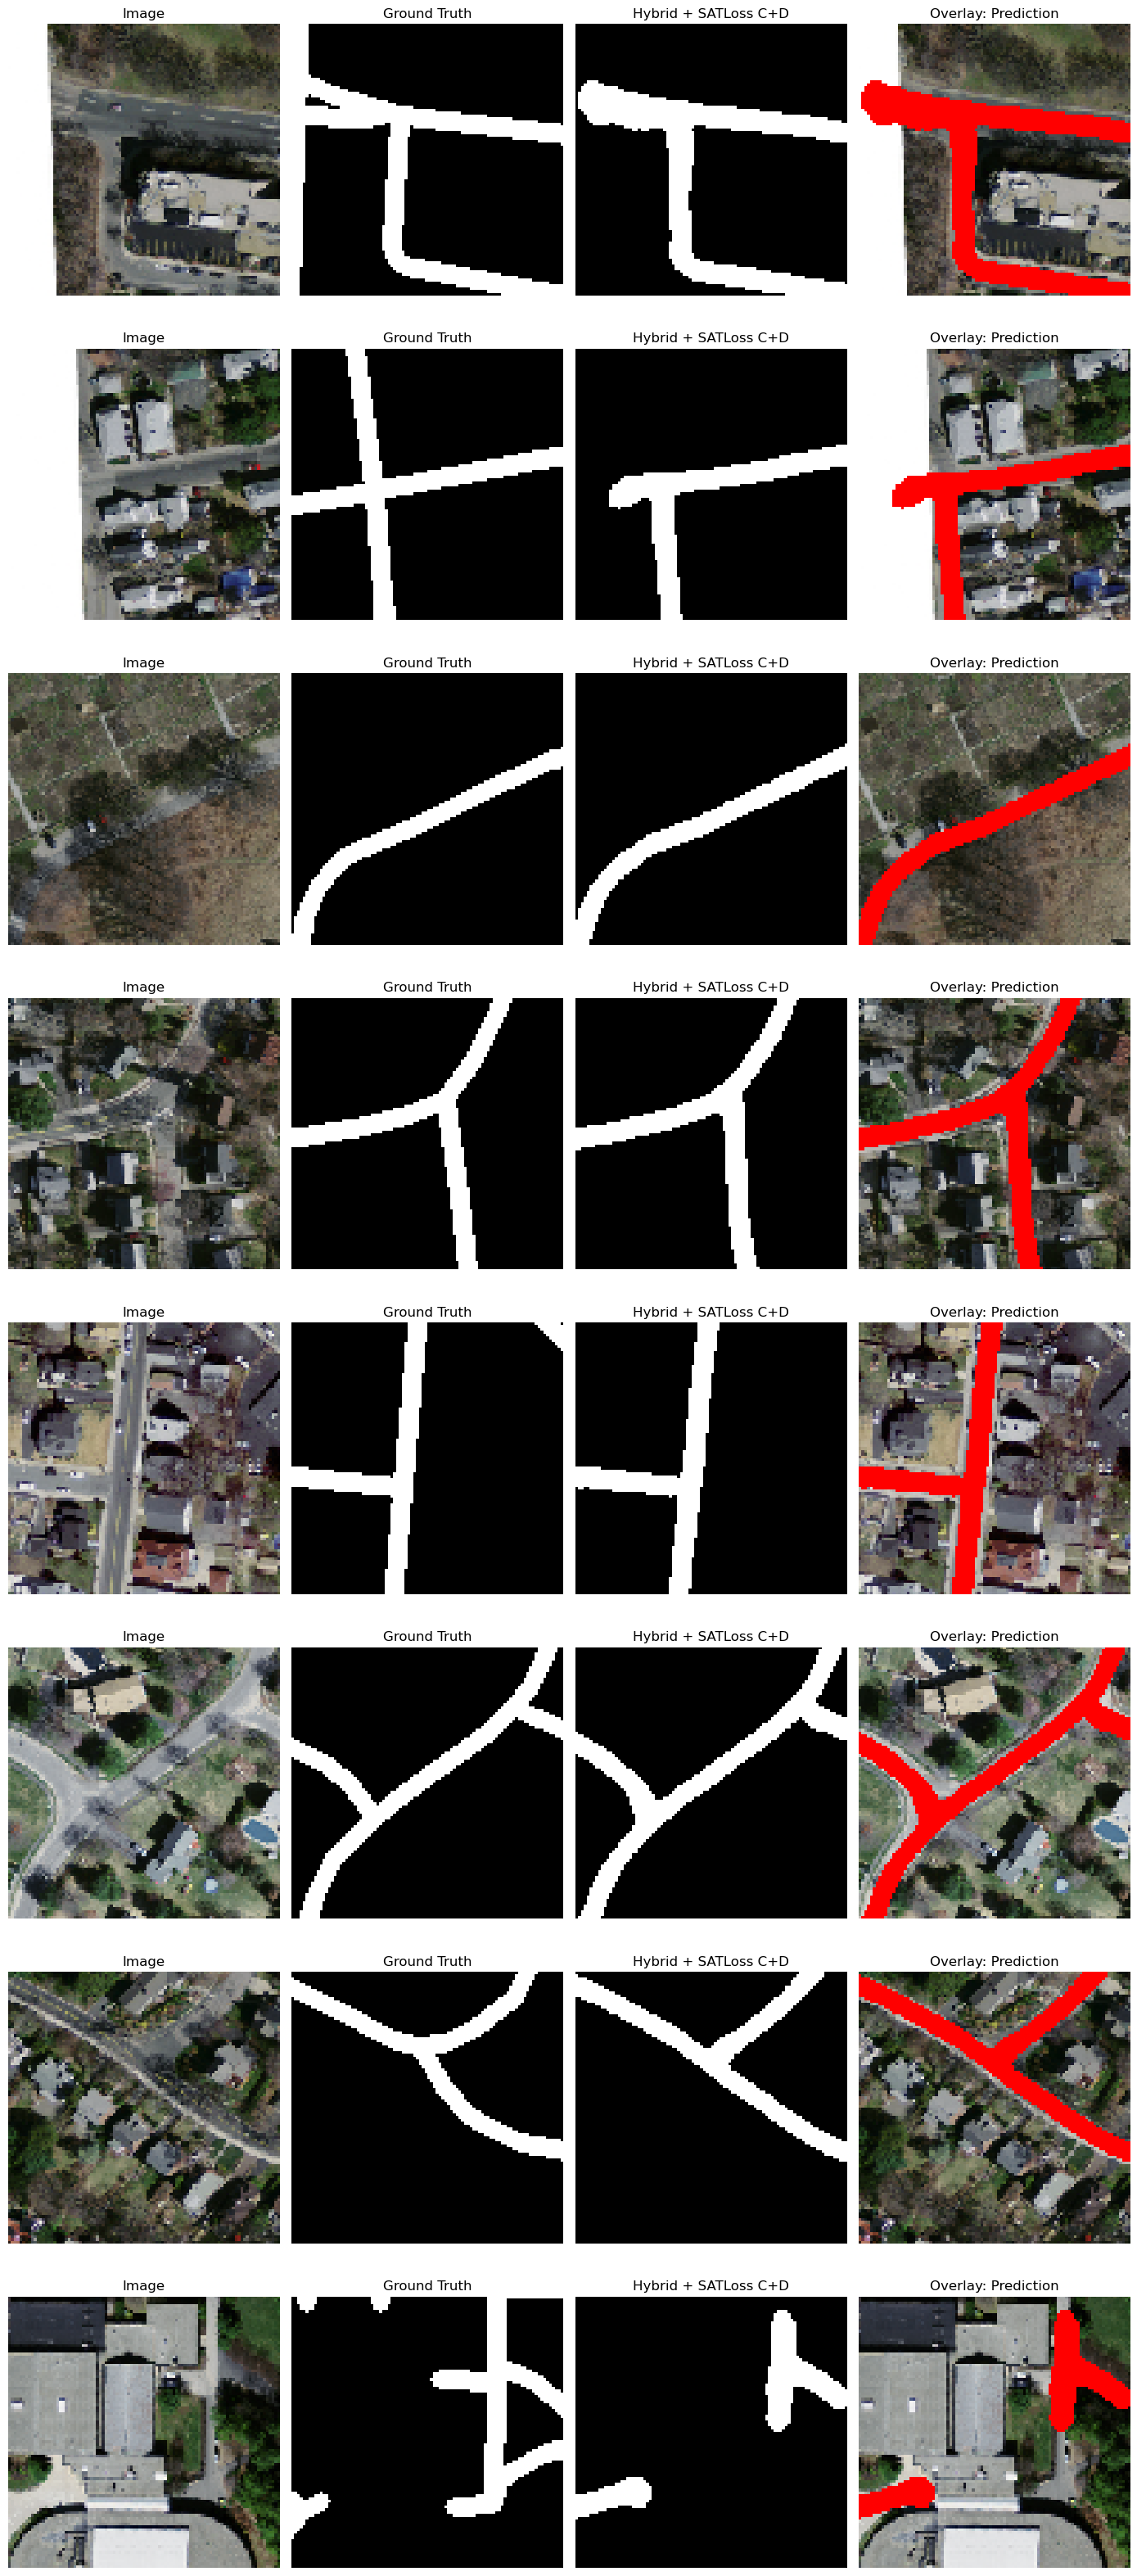


Saved Hybrid + SATLoss Creator-Destroyer visualization to:
final_thesis_figures/step30_hybrid_sat_creator_destroyer_visible_complex_predictions.png


In [29]:
# ============================================================
# STEP 30: Visualize Hybrid + SATLoss Creator-Destroyer predictions
# ============================================================
# This step visualizes predictions from the final hybrid topology-aware model.
#
# Model:
#     BCE + Dice + soft-clDice + SATLoss Creator-Destroyer
#
# We select visible complex road patches to avoid blank images and to focus on:
#   - road branches
#   - intersections
#   - curved roads
#   - connectivity
#   - possible false loops/components
#
# Columns:
#   Image | Ground Truth | Hybrid + SATLoss C+D Prediction | Overlay
#
# Red overlay = predicted road pixels.
# ============================================================

# ----------------------------
# Load best Hybrid + SATLoss Creator-Destroyer model
# ----------------------------
final_hybrid_cd_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_hybrid_cd_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_destroyer_model.pth"),
        map_location=device
    )
)

# ----------------------------
# Load best learned threshold
# ----------------------------
final_hybrid_cd_threshold = LearnableThreshold(
    init_value=0.5
).to(device)

final_hybrid_cd_threshold.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_hybrid_sat_creator_destroyer_threshold.pth"),
        map_location=device
    )
)

final_hybrid_cd_model.eval()
final_hybrid_cd_threshold.eval()


# ----------------------------
# Select visible complex road patches
# ----------------------------
complex_test_indices = []

for i, p in enumerate(test_patches):
    image_mean = p["image_patch"].mean()
    image_std = p["image_patch"].std()

    if (
        p["road_ratio"] >= 0.08
        and image_mean > 40
        and image_std > 10
    ):
        complex_test_indices.append(i)

num_samples = 8

if len(complex_test_indices) >= num_samples:
    selected_indices = random.sample(complex_test_indices, num_samples)
else:
    fallback_indices = [
        i for i, p in enumerate(test_patches)
        if p["road_ratio"] >= 0.08
    ]

    selected_indices = random.sample(
        fallback_indices,
        min(num_samples, len(fallback_indices))
    )

print("Number of visible complex patches:", len(complex_test_indices))
print("Selected test patch indices:", selected_indices)


# ----------------------------
# Visualize predictions
# ----------------------------
plt.figure(figsize=(14, 4 * len(selected_indices)))

threshold_value = final_hybrid_cd_threshold().item()
print("Learned threshold used:", threshold_value)

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_hybrid_cd_model(image_tensor)
        probs = torch.sigmoid(logits)
        threshold = final_hybrid_cd_threshold()
        pred = (probs > threshold).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    image_display = image_patch.astype(np.float32) / 255.0
    mask_np = mask_patch.astype(np.uint8)

    overlay = image_display.copy()
    overlay[pred_np == 1] = [1, 0, 0]

    print(f"\nPatch {row + 1}")
    print("Source image:", os.path.basename(patch["image_path"]))
    print("Location: top =", patch["top"], ", left =", patch["left"])
    print(f"Image mean               : {image_patch.mean():.2f}")
    print(f"Image std                : {image_patch.std():.2f}")
    print(f"Ground-truth road ratio  : {patch['road_ratio'] * 100:.2f}%")
    print(f"Predicted road ratio     : {pred_np.mean() * 100:.2f}%")

    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("Hybrid + SATLoss C+D")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay: Prediction")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step30_hybrid_sat_creator_destroyer_visible_complex_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved Hybrid + SATLoss Creator-Destroyer visualization to:")
print(save_path)

# Since Model 6 has the best metrics but poor visual predictions, I would not choose it as the final practical best model.

In [36]:
# ============================================================
# STEP 31: Build final comparison table for all road models
# ============================================================
# This step combines the final test results from all trained models.
#
# Models included:
#   1. BCE only
#   2. BCE + SATLoss Creator
#   3. BCE + SATLoss Creator-Destroyer
#   4. BCE + Dice + clDice
#   5. BCE + Dice + clDice + SATLoss Creator
#   6. BCE + Dice + clDice + SATLoss Creator-Destroyer
#
# This table will be used directly in the thesis results section.
# ============================================================

# ----------------------------
# Collect all model results
# ----------------------------
final_results = [
    {
        "Model": "BCE only",
        "Loss": baseline_test_metrics["loss"],
        "Accuracy": baseline_test_metrics["accuracy"],
        "Dice": baseline_test_metrics["dice"],
        "clDice": baseline_test_metrics["cldice"],
        "beta0_error": baseline_test_metrics["beta0_error"],
        "beta1_error": baseline_test_metrics["beta1_error"],
        "Threshold": baseline_test_metrics["threshold"]
    },
    {
        "Model": "BCE + SATLoss Creator",
        "Loss": bce_sat_creator_test_metrics["loss"],
        "Accuracy": bce_sat_creator_test_metrics["accuracy"],
        "Dice": bce_sat_creator_test_metrics["dice"],
        "clDice": bce_sat_creator_test_metrics["cldice"],
        "beta0_error": bce_sat_creator_test_metrics["beta0_error"],
        "beta1_error": bce_sat_creator_test_metrics["beta1_error"],
        "Threshold": bce_sat_creator_test_metrics["threshold"]
    },
    {
        "Model": "BCE + SATLoss Creator-Destroyer",
        "Loss": bce_sat_cd_test_metrics["loss"],
        "Accuracy": bce_sat_cd_test_metrics["accuracy"],
        "Dice": bce_sat_cd_test_metrics["dice"],
        "clDice": bce_sat_cd_test_metrics["cldice"],
        "beta0_error": bce_sat_cd_test_metrics["beta0_error"],
        "beta1_error": bce_sat_cd_test_metrics["beta1_error"],
        "Threshold": bce_sat_cd_test_metrics["threshold"]
    },
    {
        "Model": "BCE + Dice + clDice",
        "Loss": hybrid_base_test_metrics["loss"],
        "Accuracy": hybrid_base_test_metrics["accuracy"],
        "Dice": hybrid_base_test_metrics["dice"],
        "clDice": hybrid_base_test_metrics["cldice"],
        "beta0_error": hybrid_base_test_metrics["beta0_error"],
        "beta1_error": hybrid_base_test_metrics["beta1_error"],
        "Threshold": hybrid_base_test_metrics["threshold"]
    },
    {
        "Model": "BCE + Dice + clDice + SATLoss Creator",
        "Loss": hybrid_creator_test_metrics["loss"],
        "Accuracy": hybrid_creator_test_metrics["accuracy"],
        "Dice": hybrid_creator_test_metrics["dice"],
        "clDice": hybrid_creator_test_metrics["cldice"],
        "beta0_error": hybrid_creator_test_metrics["beta0_error"],
        "beta1_error": hybrid_creator_test_metrics["beta1_error"],
        "Threshold": hybrid_creator_test_metrics["threshold"]
    },
    {
        "Model": "BCE + Dice + clDice + SATLoss Creator-Destroyer",
        "Loss": hybrid_cd_test_metrics["loss"],
        "Accuracy": hybrid_cd_test_metrics["accuracy"],
        "Dice": hybrid_cd_test_metrics["dice"],
        "clDice": hybrid_cd_test_metrics["cldice"],
        "beta0_error": hybrid_cd_test_metrics["beta0_error"],
        "beta1_error": hybrid_cd_test_metrics["beta1_error"],
        "Threshold": hybrid_cd_test_metrics["threshold"]
    }
]

final_results_df = pd.DataFrame(final_results)

# ----------------------------
# Round values for display
# ----------------------------
display_results_df = final_results_df.copy()

metric_columns = [
    "Loss",
    "Accuracy",
    "Dice",
    "clDice",
    "beta0_error",
    "beta1_error",
    "Threshold"
]

display_results_df[metric_columns] = display_results_df[metric_columns].round(4)

print("FINAL ROAD MODEL COMPARISON")
print("---------------------------")
display(display_results_df)

# ----------------------------
# Save final table
# ----------------------------
final_results_path = os.path.join(
    RESULTS_DIR,
    "final_road_model_comparison.csv"
)

final_results_df.to_csv(
    final_results_path,
    index=False
)

print("\nSaved final comparison table to:")
print(final_results_path)

# ----------------------------
# Identify best models
# ----------------------------
best_dice_model = final_results_df.loc[
    final_results_df["Dice"].idxmax()
]

best_cldice_model = final_results_df.loc[
    final_results_df["clDice"].idxmax()
]

best_beta0_model = final_results_df.loc[
    final_results_df["beta0_error"].idxmin()
]

best_beta1_model = final_results_df.loc[
    final_results_df["beta1_error"].idxmin()
]

print("\nBEST MODELS")
print("-----------")
print("Best Dice model   :", best_dice_model["Model"], "| Dice =", round(best_dice_model["Dice"], 4))
print("Best clDice model :", best_cldice_model["Model"], "| clDice =", round(best_cldice_model["clDice"], 4))
print("Best beta0 model  :", best_beta0_model["Model"], "| beta0 error =", round(best_beta0_model["beta0_error"], 4))
print("Best beta1 model  :", best_beta1_model["Model"], "| beta1 error =", round(best_beta1_model["beta1_error"], 4))

FINAL ROAD MODEL COMPARISON
---------------------------


,Model,Loss,Accuracy,Dice,clDice,beta0_error,beta1_error,Threshold
0,BCE only,0.1331,0.9545,0.7204,0.7310,0.7322,0.1150,0.5
1,BCE + SATLoss Creator,0.1360,0.9543,0.7182,0.7291,0.7534,0.1062,0.5
2,BCE + SATLoss Creator-Destroyer,0.1318,0.9542,0.7178,0.7292,0.7440,0.1014,0.5
3,BCE + Dice + clDice,0.1681,0.9524,0.7207,0.7471,0.4688,0.1146,0.5
4,BCE + Dice + clDice + SATLoss Creator,0.1601,0.9517,0.7209,0.7455,0.4916,0.0998,0.5
5,BCE + Dice + clDice + SATLoss Creator-Destroyer,0.1601,0.9517,0.7209,0.7455,0.4916,0.0998,0.5



Saved final comparison table to:
final_thesis_results/final_road_model_comparison.csv

BEST MODELS
-----------
Best Dice model   : BCE + Dice + clDice + SATLoss Creator | Dice = 0.7209
Best clDice model : BCE + Dice + clDice | clDice = 0.7471
Best beta0 model  : BCE + Dice + clDice | beta0 error = 0.4688
Best beta1 model  : BCE + Dice + clDice + SATLoss Creator | beta1 error = 0.0998


# The best second/final reliable model is:

## BCE + Dice + clDice + SATLoss Creator

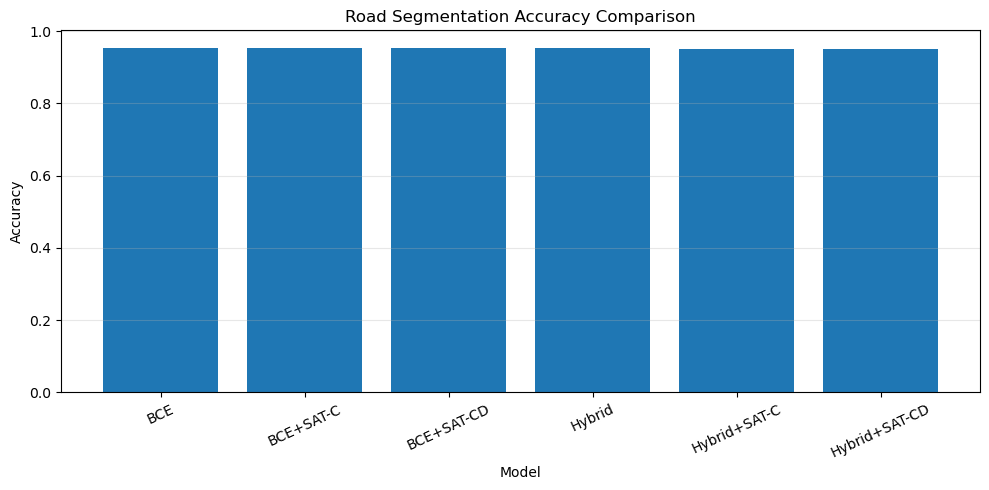

Saved: final_thesis_figures/step32_accuracy_comparison.png


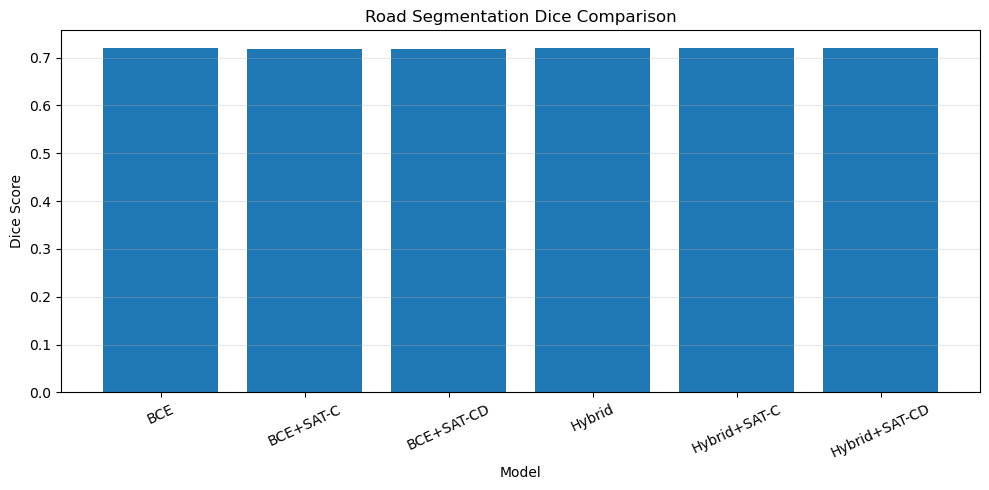

Saved: final_thesis_figures/step32_dice_comparison.png


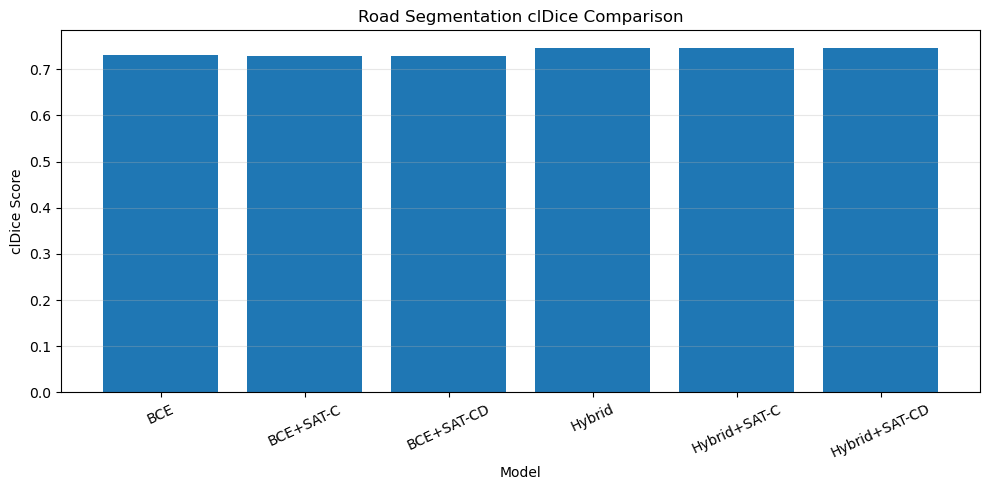

Saved: final_thesis_figures/step32_cldice_comparison.png


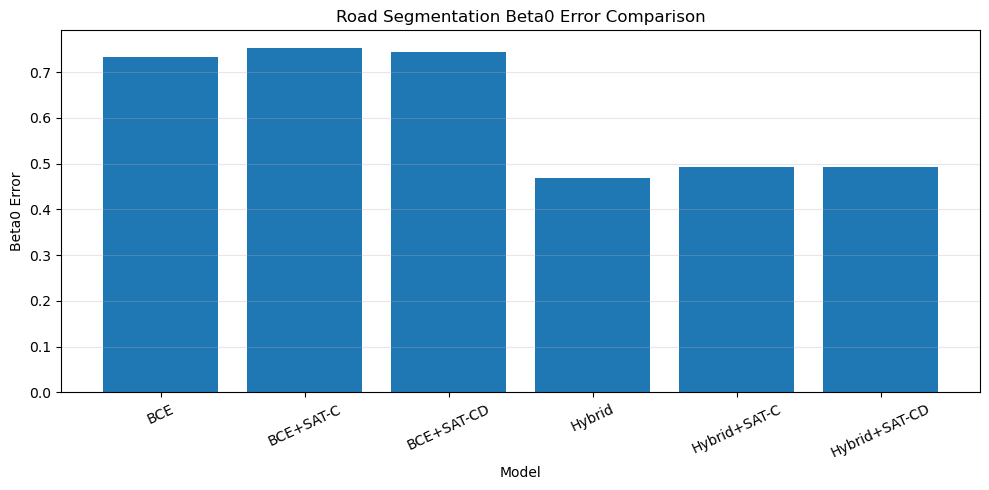

Saved: final_thesis_figures/step32_beta0_error_comparison.png


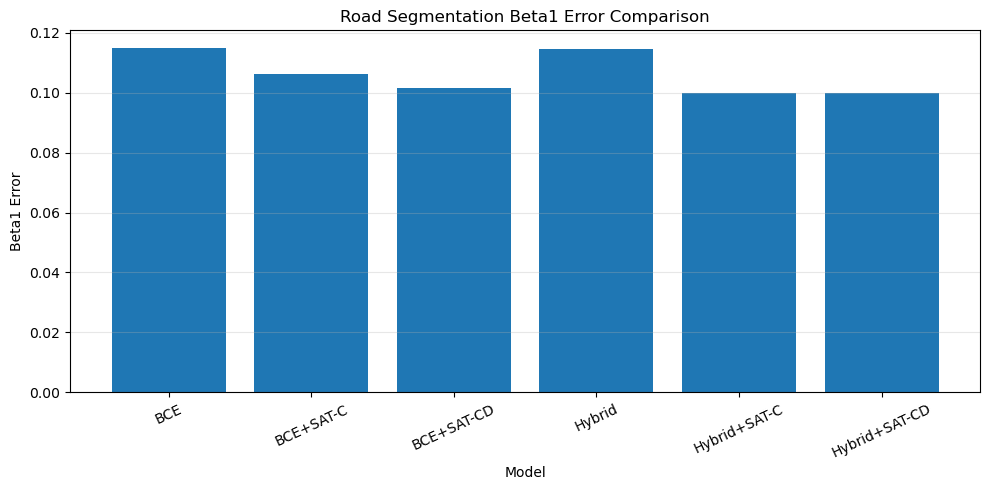

Saved: final_thesis_figures/step32_beta1_error_comparison.png


In [37]:
# ============================================================
# STEP 32: Plot final model comparison charts
# ============================================================
# This step visualizes the final test results from all models.
#
# We plot:
#   1. Accuracy
#   2. Dice
#   3. clDice
#   4. beta0 error
#   5. beta1 error
#
# Higher is better:
#   - Accuracy
#   - Dice
#   - clDice
#
# Lower is better:
#   - beta0 error
#   - beta1 error
# ============================================================

# ----------------------------
# Short names for plotting
# ----------------------------
plot_df = final_results_df.copy()

plot_df["Short Model"] = [
    "BCE",
    "BCE+SAT-C",
    "BCE+SAT-CD",
    "Hybrid",
    "Hybrid+SAT-C",
    "Hybrid+SAT-CD"
]

# ----------------------------
# Function for bar plot
# ----------------------------
def plot_metric_bar(df, metric, ylabel, title, save_name):
    plt.figure(figsize=(10, 5))

    plt.bar(
        df["Short Model"],
        df[metric]
    )

    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=25)
    plt.grid(axis="y", alpha=0.3)

    save_path = os.path.join(
        FIGURE_DIR,
        save_name
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


# ----------------------------
# Plot metrics
# ----------------------------
plot_metric_bar(
    plot_df,
    metric="Accuracy",
    ylabel="Accuracy",
    title="Road Segmentation Accuracy Comparison",
    save_name="step32_accuracy_comparison.png"
)

plot_metric_bar(
    plot_df,
    metric="Dice",
    ylabel="Dice Score",
    title="Road Segmentation Dice Comparison",
    save_name="step32_dice_comparison.png"
)

plot_metric_bar(
    plot_df,
    metric="clDice",
    ylabel="clDice Score",
    title="Road Segmentation clDice Comparison",
    save_name="step32_cldice_comparison.png"
)

plot_metric_bar(
    plot_df,
    metric="beta0_error",
    ylabel="Beta0 Error",
    title="Road Segmentation Beta0 Error Comparison",
    save_name="step32_beta0_error_comparison.png"
)

plot_metric_bar(
    plot_df,
    metric="beta1_error",
    ylabel="Beta1 Error",
    title="Road Segmentation Beta1 Error Comparison",
    save_name="step32_beta1_error_comparison.png"
)

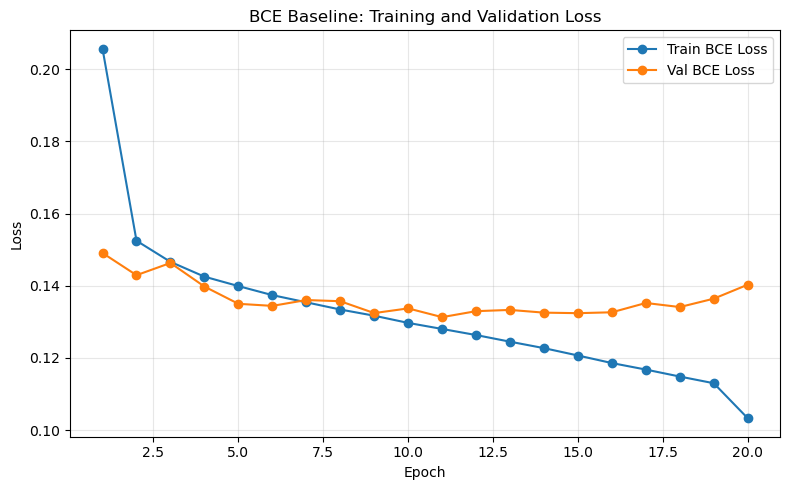

Saved: final_thesis_figures/step34_bce_loss_curve.png


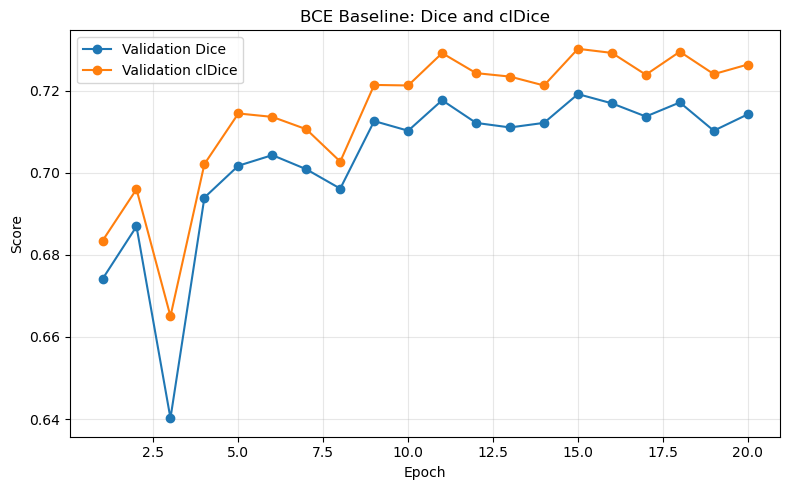

Saved: final_thesis_figures/step34_bce_dice_cldice_curve.png


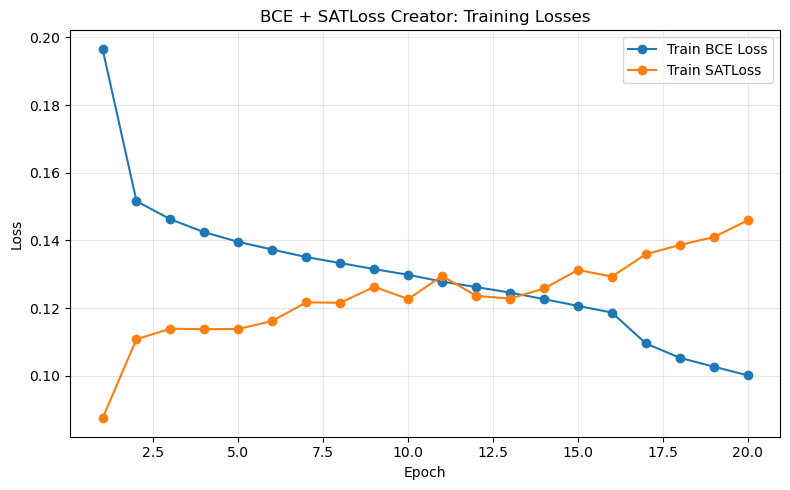

Saved: final_thesis_figures/step34_bce_sat_creator_loss_curve.png


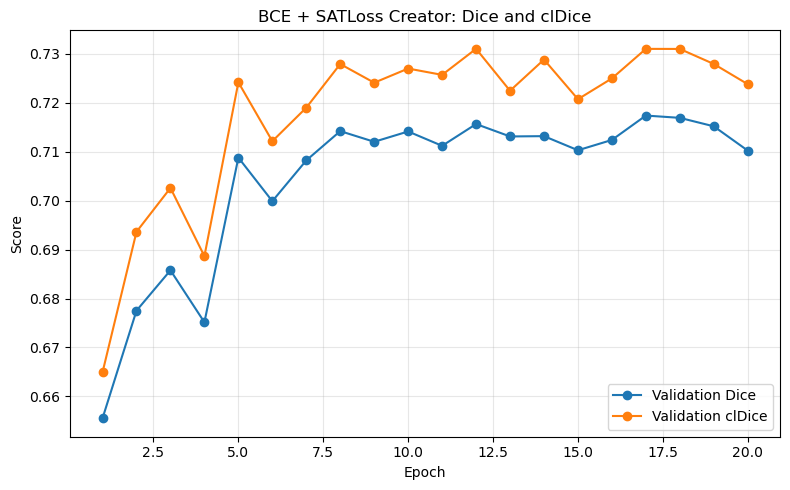

Saved: final_thesis_figures/step34_bce_sat_creator_dice_cldice_curve.png


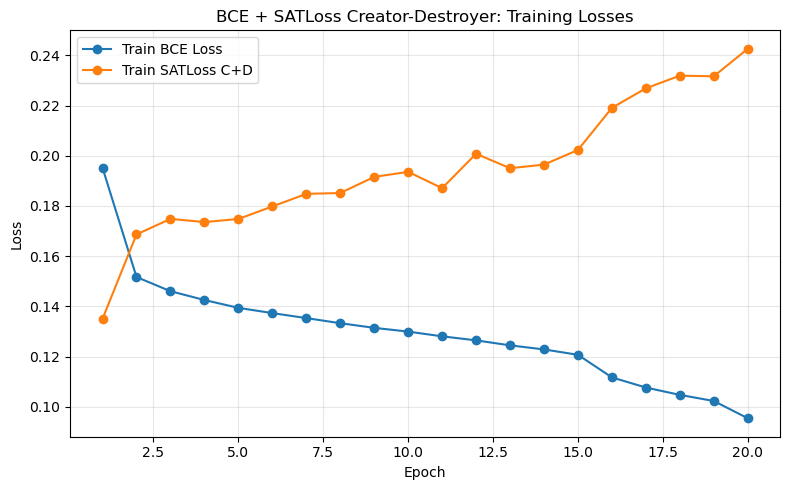

Saved: final_thesis_figures/step34_bce_sat_cd_loss_curve.png


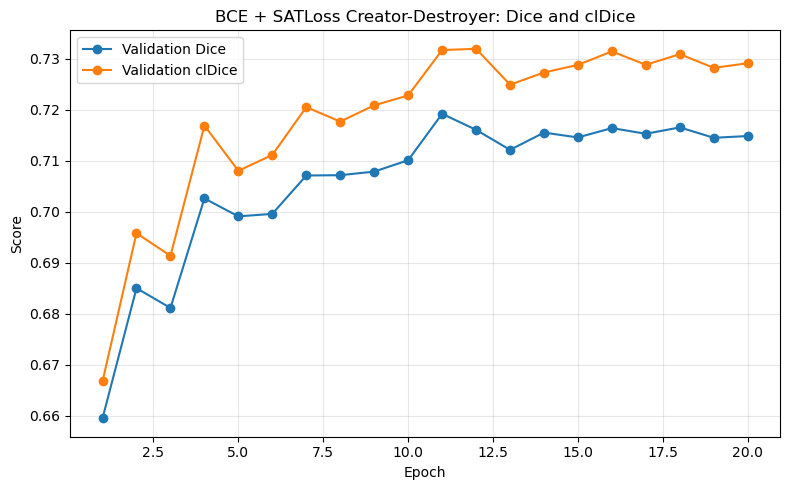

Saved: final_thesis_figures/step34_bce_sat_cd_dice_cldice_curve.png


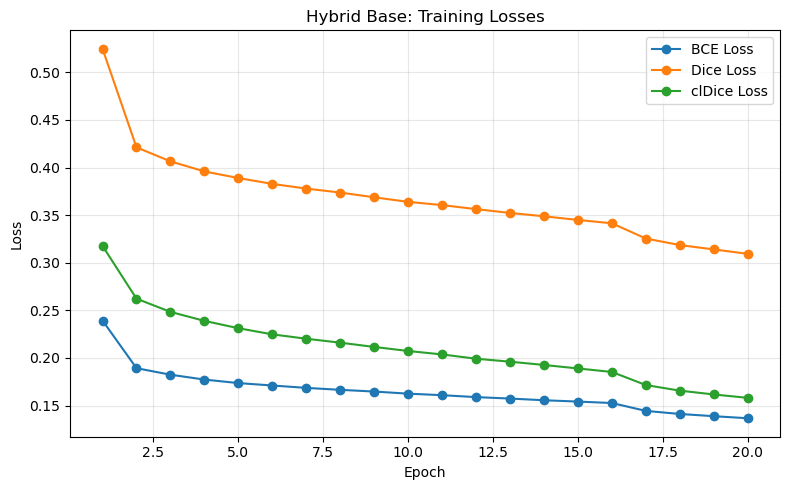

Saved: final_thesis_figures/step34_hybrid_base_loss_curve.png


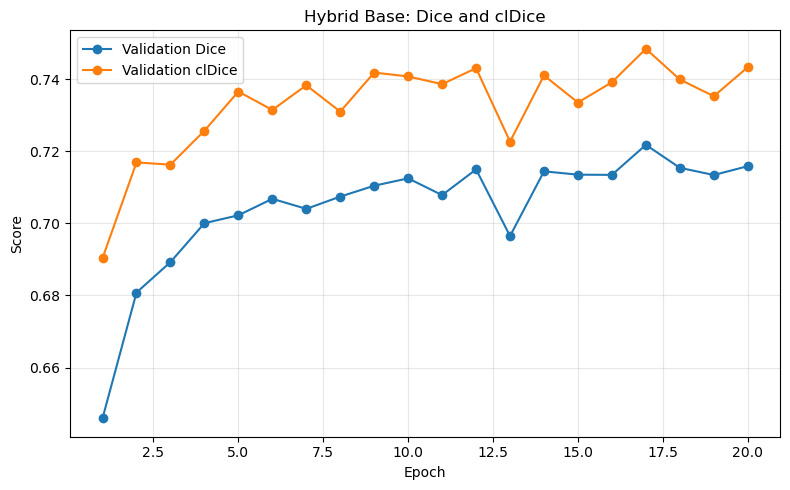

Saved: final_thesis_figures/step34_hybrid_base_dice_cldice_curve.png


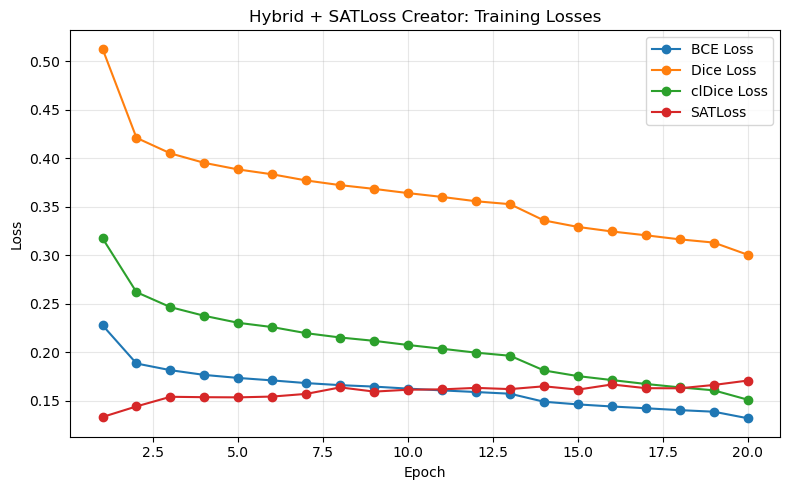

Saved: final_thesis_figures/step34_hybrid_sat_creator_loss_curve.png


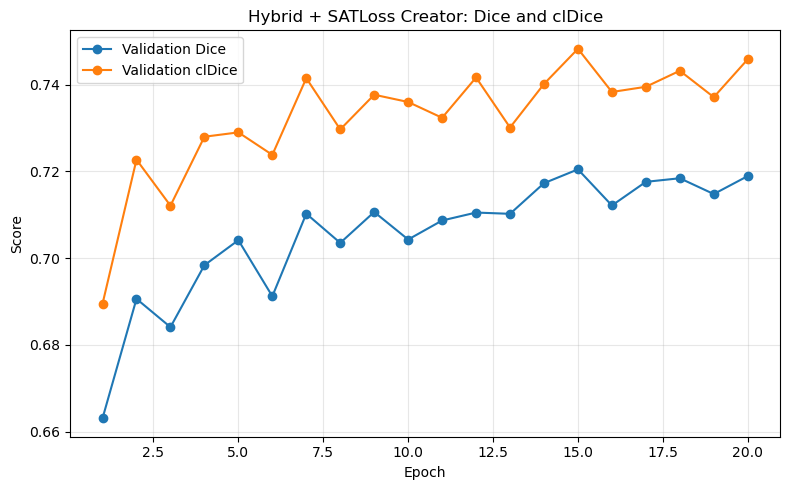

Saved: final_thesis_figures/step34_hybrid_sat_creator_dice_cldice_curve.png


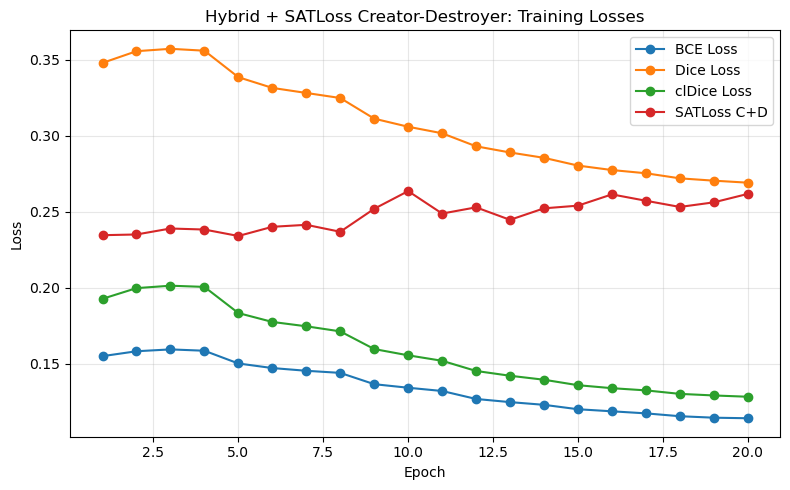

Saved: final_thesis_figures/step34_hybrid_sat_cd_loss_curve.png


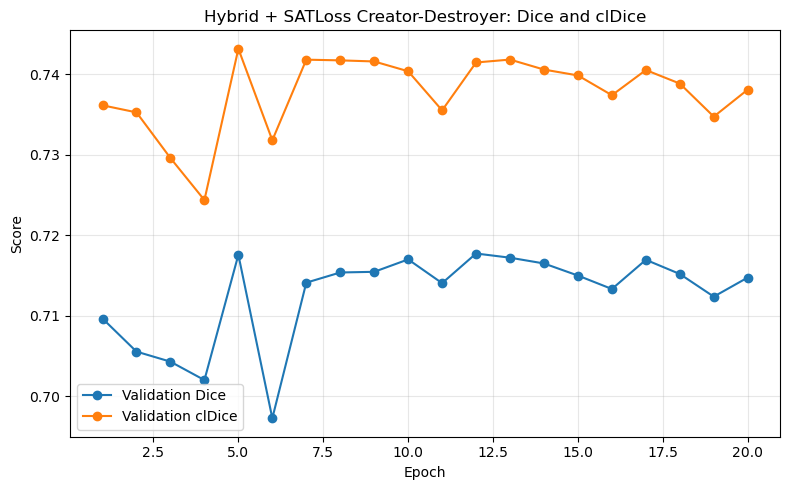

Saved: final_thesis_figures/step34_hybrid_sat_cd_dice_cldice_curve.png


In [38]:
# ============================================================
# STEP 33: Plot training curves for all models
# ============================================================
# This step plots training and validation curves.
#
# These curves help us understand:
#   1. whether each model learned properly
#   2. whether validation Dice improved
#   3. whether topology errors decreased
#   4. whether any model overfitted
#
# Figures are saved for the thesis.
# ============================================================

# ----------------------------
# Helper function
# ----------------------------
def plot_history_curve(history, keys, labels, title, ylabel, save_name):
    plt.figure(figsize=(8, 5))

    epochs = range(1, len(history[keys[0]]) + 1)

    for key, label in zip(keys, labels):
        plt.plot(
            epochs,
            history[key],
            marker="o",
            label=label
        )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)

    save_path = os.path.join(FIGURE_DIR, save_name)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


# ============================================================
# 1. BCE baseline curves
# ============================================================
plot_history_curve(
    baseline_history,
    keys=["train_loss", "val_loss"],
    labels=["Train BCE Loss", "Val BCE Loss"],
    title="BCE Baseline: Training and Validation Loss",
    ylabel="Loss",
    save_name="step34_bce_loss_curve.png"
)

plot_history_curve(
    baseline_history,
    keys=["val_dice", "val_cldice"],
    labels=["Validation Dice", "Validation clDice"],
    title="BCE Baseline: Dice and clDice",
    ylabel="Score",
    save_name="step34_bce_dice_cldice_curve.png"
)


# ============================================================
# 2. BCE + SATLoss Creator curves
# ============================================================
plot_history_curve(
    bce_sat_creator_history,
    keys=["train_bce_loss", "train_sat_loss"],
    labels=["Train BCE Loss", "Train SATLoss"],
    title="BCE + SATLoss Creator: Training Losses",
    ylabel="Loss",
    save_name="step34_bce_sat_creator_loss_curve.png"
)

plot_history_curve(
    bce_sat_creator_history,
    keys=["val_dice", "val_cldice"],
    labels=["Validation Dice", "Validation clDice"],
    title="BCE + SATLoss Creator: Dice and clDice",
    ylabel="Score",
    save_name="step34_bce_sat_creator_dice_cldice_curve.png"
)


# ============================================================
# 3. BCE + SATLoss Creator-Destroyer curves
# ============================================================
plot_history_curve(
    bce_sat_cd_history,
    keys=["train_bce_loss", "train_sat_loss"],
    labels=["Train BCE Loss", "Train SATLoss C+D"],
    title="BCE + SATLoss Creator-Destroyer: Training Losses",
    ylabel="Loss",
    save_name="step34_bce_sat_cd_loss_curve.png"
)

plot_history_curve(
    bce_sat_cd_history,
    keys=["val_dice", "val_cldice"],
    labels=["Validation Dice", "Validation clDice"],
    title="BCE + SATLoss Creator-Destroyer: Dice and clDice",
    ylabel="Score",
    save_name="step34_bce_sat_cd_dice_cldice_curve.png"
)


# ============================================================
# 4. Hybrid Base curves
# ============================================================
plot_history_curve(
    hybrid_base_history,
    keys=["train_bce_loss", "train_dice_loss", "train_cldice_loss"],
    labels=["BCE Loss", "Dice Loss", "clDice Loss"],
    title="Hybrid Base: Training Losses",
    ylabel="Loss",
    save_name="step34_hybrid_base_loss_curve.png"
)

plot_history_curve(
    hybrid_base_history,
    keys=["val_dice", "val_cldice"],
    labels=["Validation Dice", "Validation clDice"],
    title="Hybrid Base: Dice and clDice",
    ylabel="Score",
    save_name="step34_hybrid_base_dice_cldice_curve.png"
)


# ============================================================
# 5. Hybrid + SATLoss Creator curves
# ============================================================
plot_history_curve(
    hybrid_creator_history,
    keys=["train_bce_loss", "train_dice_loss", "train_cldice_loss", "train_sat_loss"],
    labels=["BCE Loss", "Dice Loss", "clDice Loss", "SATLoss"],
    title="Hybrid + SATLoss Creator: Training Losses",
    ylabel="Loss",
    save_name="step34_hybrid_sat_creator_loss_curve.png"
)

plot_history_curve(
    hybrid_creator_history,
    keys=["val_dice", "val_cldice"],
    labels=["Validation Dice", "Validation clDice"],
    title="Hybrid + SATLoss Creator: Dice and clDice",
    ylabel="Score",
    save_name="step34_hybrid_sat_creator_dice_cldice_curve.png"
)


# ============================================================
# 6. Hybrid + SATLoss Creator-Destroyer curves
# ============================================================
plot_history_curve(
    hybrid_cd_history,
    keys=["train_bce_loss", "train_dice_loss", "train_cldice_loss", "train_sat_loss"],
    labels=["BCE Loss", "Dice Loss", "clDice Loss", "SATLoss C+D"],
    title="Hybrid + SATLoss Creator-Destroyer: Training Losses",
    ylabel="Loss",
    save_name="step34_hybrid_sat_cd_loss_curve.png"
)

plot_history_curve(
    hybrid_cd_history,
    keys=["val_dice", "val_cldice"],
    labels=["Validation Dice", "Validation clDice"],
    title="Hybrid + SATLoss Creator-Destroyer: Dice and clDice",
    ylabel="Score",
    save_name="step34_hybrid_sat_cd_dice_cldice_curve.png"
)

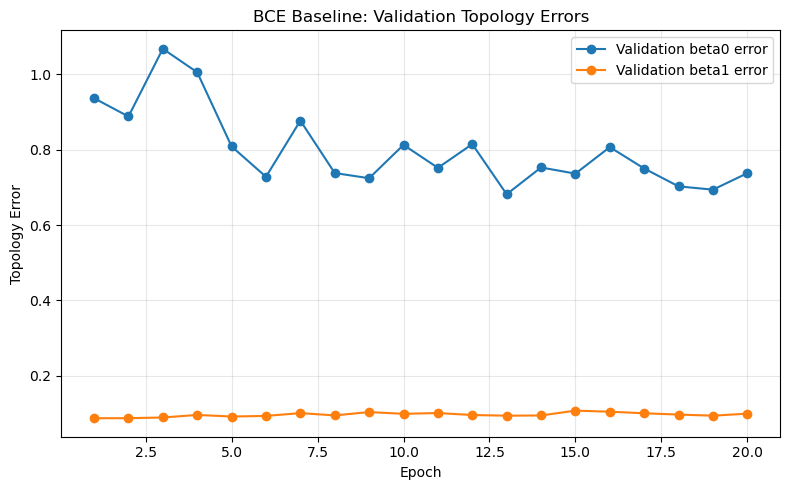

Saved: final_thesis_figures/step35_bce_topology_errors.png


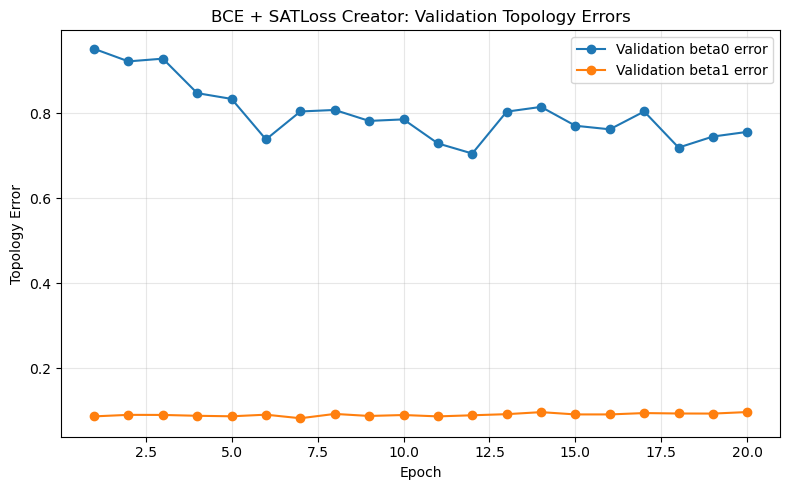

Saved: final_thesis_figures/step35_bce_sat_creator_topology_errors.png


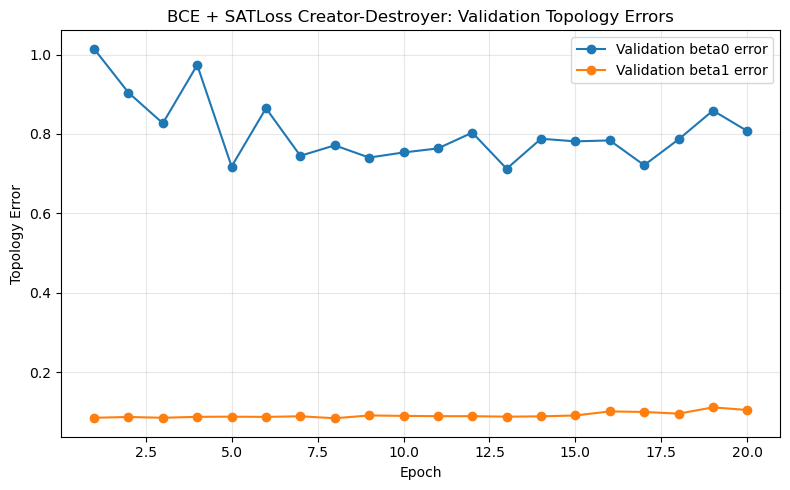

Saved: final_thesis_figures/step35_bce_sat_cd_topology_errors.png


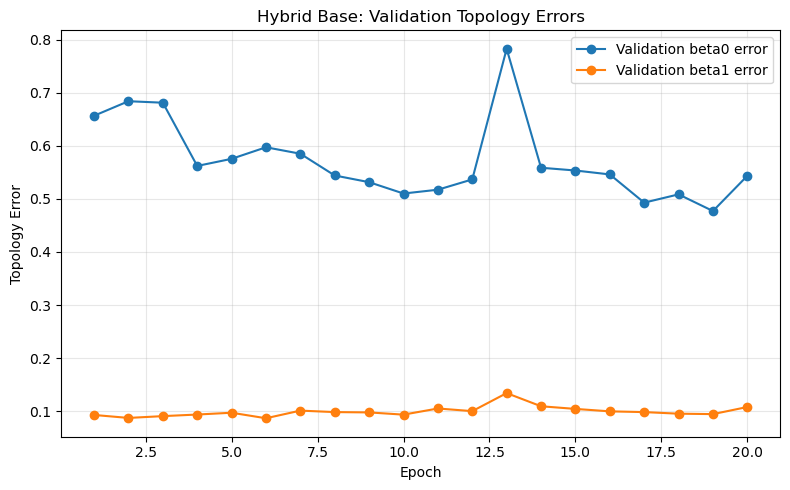

Saved: final_thesis_figures/step35_hybrid_base_topology_errors.png


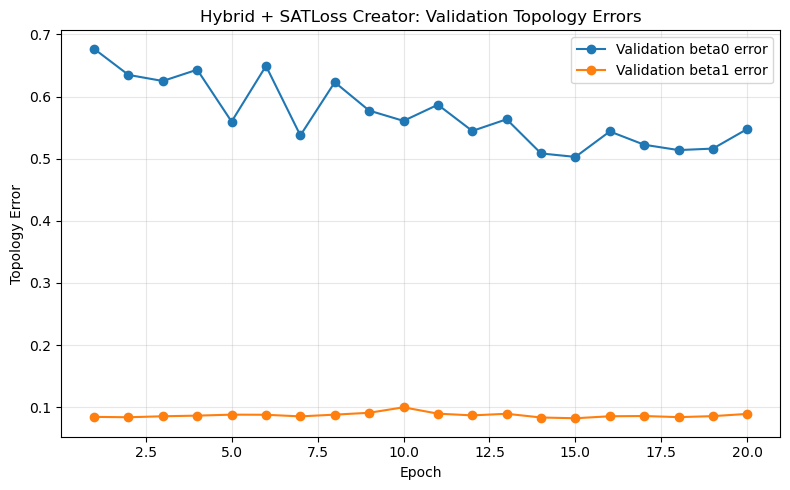

Saved: final_thesis_figures/step35_hybrid_sat_creator_topology_errors.png


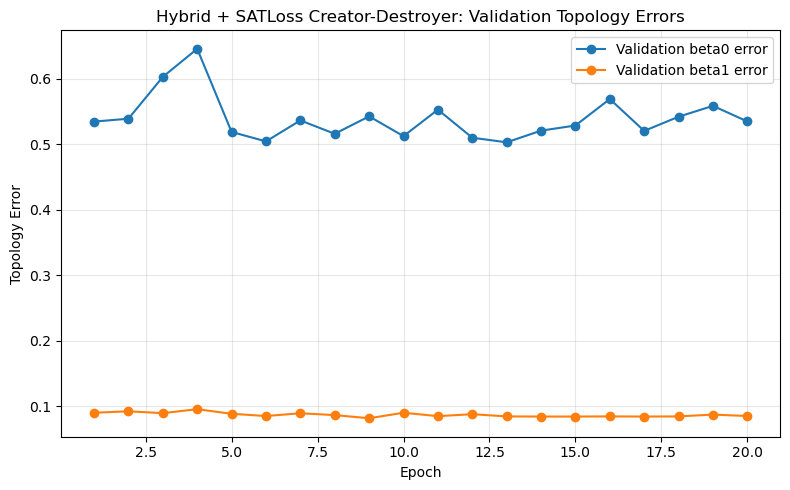

Saved: final_thesis_figures/step35_hybrid_sat_cd_topology_errors.png


In [39]:
# ============================================================
# STEP 34: Plot topology-error curves for all models
# ============================================================
# This step plots validation beta0 and beta1 errors during training.
#
# beta0 error:
#   measures connected-component error.
#   Lower beta0 error means better road connectivity.
#
# beta1 error:
#   measures hole/loop error.
#   Lower beta1 error means fewer wrong loops or missing loops.
#
# These plots are important because the thesis focuses on topology.
# ============================================================

def plot_topology_curve(history, title, save_name):
    plt.figure(figsize=(8, 5))

    epochs = range(1, len(history["val_beta0_error"]) + 1)

    plt.plot(
        epochs,
        history["val_beta0_error"],
        marker="o",
        label="Validation beta0 error"
    )

    plt.plot(
        epochs,
        history["val_beta1_error"],
        marker="o",
        label="Validation beta1 error"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Topology Error")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)

    save_path = os.path.join(FIGURE_DIR, save_name)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


plot_topology_curve(
    baseline_history,
    title="BCE Baseline: Validation Topology Errors",
    save_name="step35_bce_topology_errors.png"
)

plot_topology_curve(
    bce_sat_creator_history,
    title="BCE + SATLoss Creator: Validation Topology Errors",
    save_name="step35_bce_sat_creator_topology_errors.png"
)

plot_topology_curve(
    bce_sat_cd_history,
    title="BCE + SATLoss Creator-Destroyer: Validation Topology Errors",
    save_name="step35_bce_sat_cd_topology_errors.png"
)

plot_topology_curve(
    hybrid_base_history,
    title="Hybrid Base: Validation Topology Errors",
    save_name="step35_hybrid_base_topology_errors.png"
)

plot_topology_curve(
    hybrid_creator_history,
    title="Hybrid + SATLoss Creator: Validation Topology Errors",
    save_name="step35_hybrid_sat_creator_topology_errors.png"
)

plot_topology_curve(
    hybrid_cd_history,
    title="Hybrid + SATLoss Creator-Destroyer: Validation Topology Errors",
    save_name="step35_hybrid_sat_cd_topology_errors.png"
)

Selected patch indices: [1186, 4889, 970, 3514]


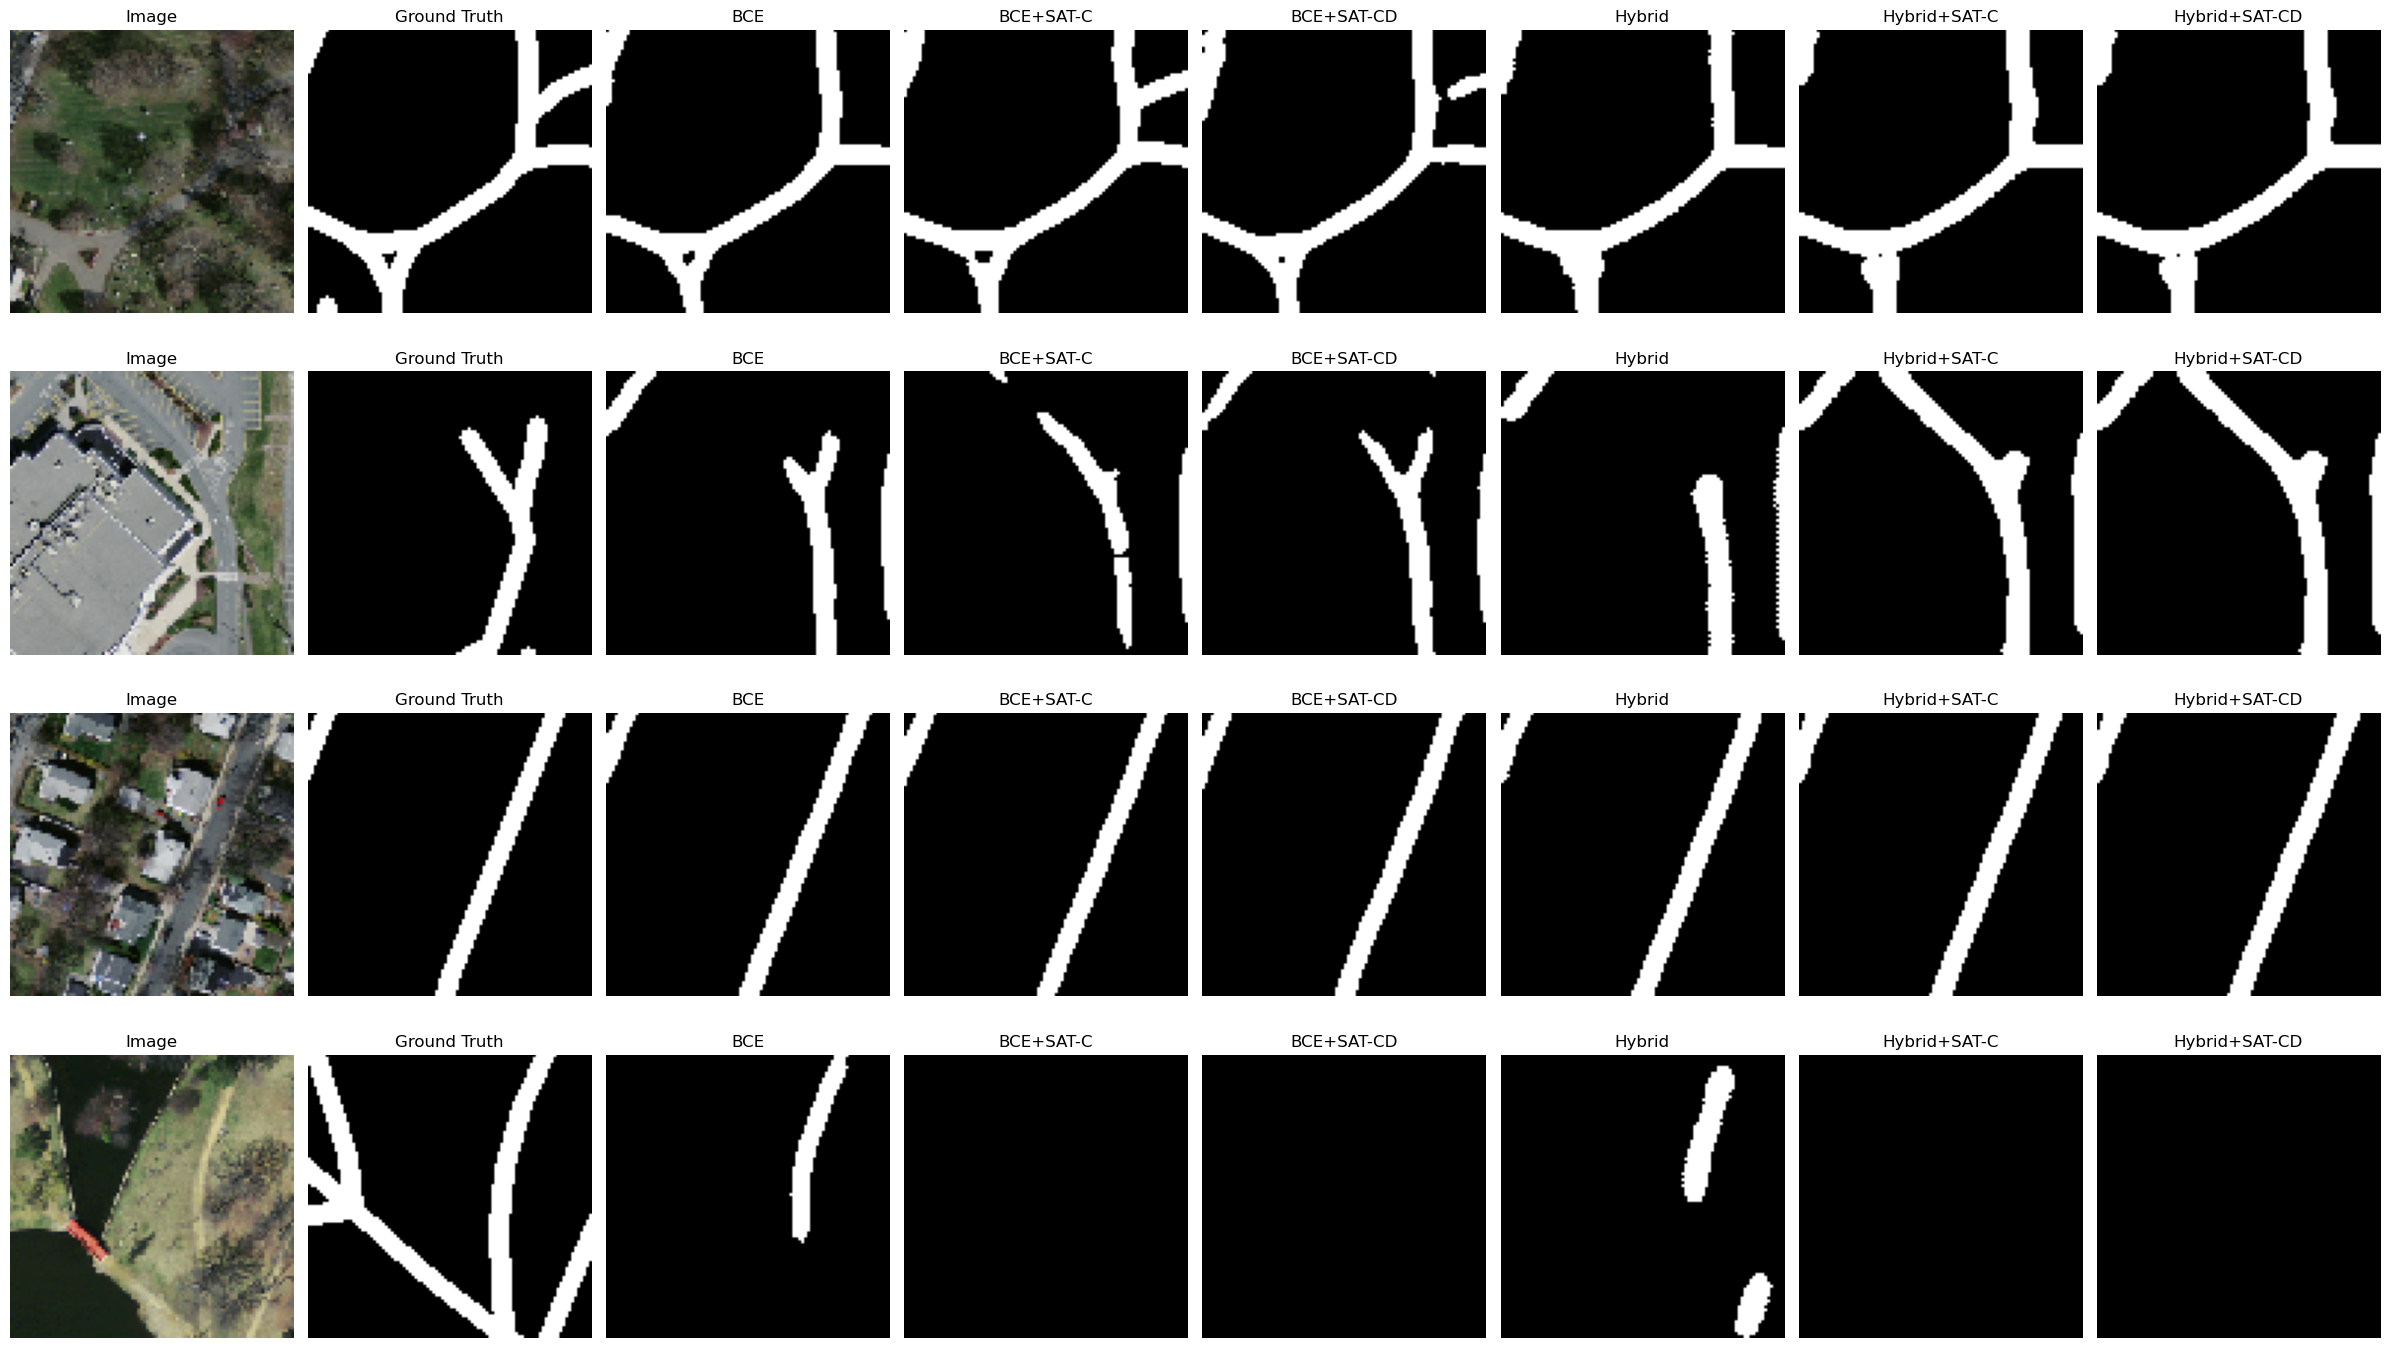


Saved all-model visual comparison to:
final_thesis_figures/step36_all_models_same_complex_patches_comparison.png


In [40]:
# ============================================================
# STEP 35: Compare all model predictions on the same complex road patches
# ============================================================
# This step compares predictions from all trained models on the same
# visible complex test patches.
#
# Models compared:
#   1. BCE only
#   2. BCE + SATLoss Creator
#   3. BCE + SATLoss Creator-Destroyer
#   4. BCE + Dice + clDice
#   5. Hybrid + SATLoss Creator
#   6. Hybrid + SATLoss Creator-Destroyer
#
# This figure is important for the thesis because it shows how topology-aware
# losses affect road continuity, branches, and intersections.
# ============================================================

# ----------------------------
# Load all best models and thresholds
# ----------------------------
model_info = [
    {
        "name": "BCE",
        "model_path": "best_baseline_model.pth",
        "threshold_path": "best_baseline_threshold.pth"
    },
    {
        "name": "BCE+SAT-C",
        "model_path": "best_bce_sat_creator_model.pth",
        "threshold_path": "best_bce_sat_creator_threshold.pth"
    },
    {
        "name": "BCE+SAT-CD",
        "model_path": "best_bce_sat_creator_destroyer_model.pth",
        "threshold_path": "best_bce_sat_creator_destroyer_threshold.pth"
    },
    {
        "name": "Hybrid",
        "model_path": "best_hybrid_base_model.pth",
        "threshold_path": "best_hybrid_base_threshold.pth"
    },
    {
        "name": "Hybrid+SAT-C",
        "model_path": "best_hybrid_sat_creator_model.pth",
        "threshold_path": "best_hybrid_sat_creator_threshold.pth"
    },
    {
        "name": "Hybrid+SAT-CD",
        "model_path": "best_hybrid_sat_creator_destroyer_model.pth",
        "threshold_path": "best_hybrid_sat_creator_destroyer_threshold.pth"
    }
]

loaded_models = []

for info in model_info:
    model = UNet(
        in_channels=3,
        out_channels=1
    ).to(device)

    threshold_module = LearnableThreshold(
        init_value=0.5
    ).to(device)

    model.load_state_dict(
        torch.load(
            os.path.join(SAVE_DIR, info["model_path"]),
            map_location=device
        )
    )

    threshold_module.load_state_dict(
        torch.load(
            os.path.join(SAVE_DIR, info["threshold_path"]),
            map_location=device
        )
    )

    model.eval()
    threshold_module.eval()

    loaded_models.append({
        "name": info["name"],
        "model": model,
        "threshold": threshold_module
    })


# ----------------------------
# Select the same visible complex road patches
# ----------------------------
complex_test_indices = []

for i, p in enumerate(test_patches):
    image_mean = p["image_patch"].mean()
    image_std = p["image_patch"].std()

    if (
        p["road_ratio"] >= 0.08
        and image_mean > 40
        and image_std > 10
    ):
        complex_test_indices.append(i)

num_samples = 4

if len(complex_test_indices) >= num_samples:
    selected_indices = random.sample(complex_test_indices, num_samples)
else:
    fallback_indices = [
        i for i, p in enumerate(test_patches)
        if p["road_ratio"] >= 0.08
    ]

    selected_indices = random.sample(
        fallback_indices,
        min(num_samples, len(fallback_indices))
    )

print("Selected patch indices:", selected_indices)


# ----------------------------
# Plot comparison
# ----------------------------
# Columns:
#   Image | GT | BCE | BCE+SAT-C | BCE+SAT-CD | Hybrid | Hybrid+SAT-C | Hybrid+SAT-CD
# ----------------------------
num_cols = 2 + len(loaded_models)
num_rows = len(selected_indices)

plt.figure(figsize=(3 * num_cols, 3.5 * num_rows))

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_display = image_patch.astype(np.float32) / 255.0
    mask_np = mask_patch.astype(np.uint8)

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    # Image
    plt.subplot(num_rows, num_cols, row * num_cols + 1)
    plt.imshow(image_display)
    plt.title("Image")
    plt.axis("off")

    # Ground truth
    plt.subplot(num_rows, num_cols, row * num_cols + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Predictions from all models
    for col, item in enumerate(loaded_models):
        model = item["model"]
        threshold_module = item["threshold"]

        with torch.no_grad():
            logits = model(image_tensor)
            probs = torch.sigmoid(logits)
            threshold = threshold_module()
            pred = (probs > threshold).float()

        pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

        plt.subplot(num_rows, num_cols, row * num_cols + 3 + col)
        plt.imshow(pred_np, cmap="gray")
        plt.title(item["name"])
        plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step36_all_models_same_complex_patches_comparison.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved all-model visual comparison to:")
print(save_path)

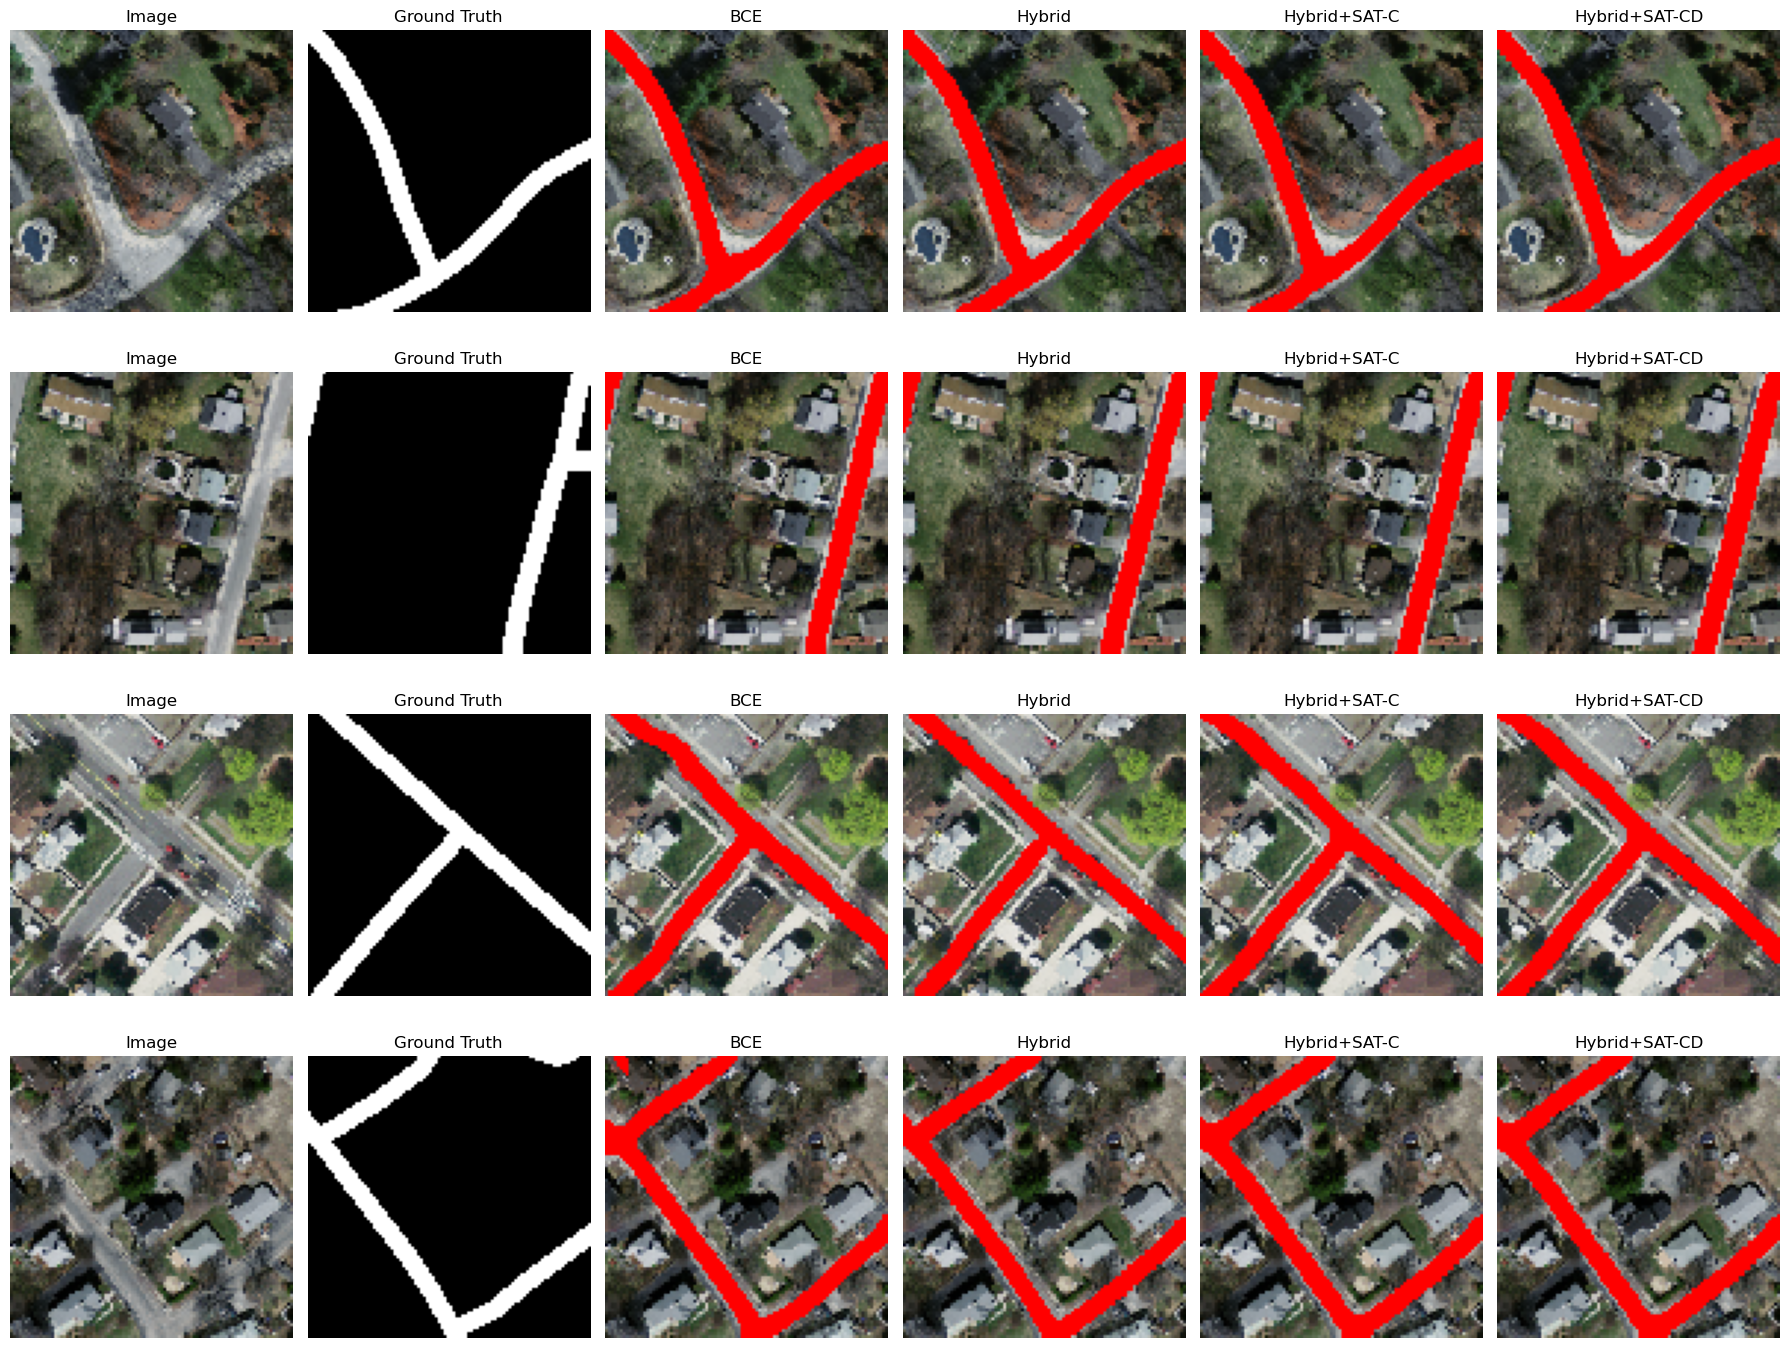

Saved key overlay comparison to:
final_thesis_figures/step37_key_model_overlay_comparison.png


In [41]:
# ============================================================
# STEP 36: Overlay comparison for key models only
# ============================================================
# This step compares key models using prediction overlays.
#
# We keep only the most important models to avoid too many figures:
#   1. BCE only
#   2. Hybrid Base
#   3. Hybrid + SATLoss Creator
#   4. Hybrid + SATLoss Creator-Destroyer
#
# Red overlay = predicted road pixels.
# ============================================================

key_model_info = [
    {
        "name": "BCE",
        "model_path": "best_baseline_model.pth",
        "threshold_path": "best_baseline_threshold.pth"
    },
    {
        "name": "Hybrid",
        "model_path": "best_hybrid_base_model.pth",
        "threshold_path": "best_hybrid_base_threshold.pth"
    },
    {
        "name": "Hybrid+SAT-C",
        "model_path": "best_hybrid_sat_creator_model.pth",
        "threshold_path": "best_hybrid_sat_creator_threshold.pth"
    },
    {
        "name": "Hybrid+SAT-CD",
        "model_path": "best_hybrid_sat_creator_destroyer_model.pth",
        "threshold_path": "best_hybrid_sat_creator_destroyer_threshold.pth"
    }
]

loaded_key_models = []

for info in key_model_info:
    model = UNet(in_channels=3, out_channels=1).to(device)
    threshold_module = LearnableThreshold(init_value=0.5).to(device)

    model.load_state_dict(
        torch.load(os.path.join(SAVE_DIR, info["model_path"]), map_location=device)
    )

    threshold_module.load_state_dict(
        torch.load(os.path.join(SAVE_DIR, info["threshold_path"]), map_location=device)
    )

    model.eval()
    threshold_module.eval()

    loaded_key_models.append({
        "name": info["name"],
        "model": model,
        "threshold": threshold_module
    })


# Select visible complex patches
complex_test_indices = []

for i, p in enumerate(test_patches):
    image_mean = p["image_patch"].mean()
    image_std = p["image_patch"].std()

    if p["road_ratio"] >= 0.08 and image_mean > 40 and image_std > 10:
        complex_test_indices.append(i)

num_samples = 4
selected_indices = random.sample(complex_test_indices, num_samples)

num_rows = len(selected_indices)
num_cols = 2 + len(loaded_key_models)

plt.figure(figsize=(3 * num_cols, 3.5 * num_rows))

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_display = image_patch.astype(np.float32) / 255.0
    mask_np = mask_patch.astype(np.uint8)

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    plt.subplot(num_rows, num_cols, row * num_cols + 1)
    plt.imshow(image_display)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(num_rows, num_cols, row * num_cols + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    for col, item in enumerate(loaded_key_models):
        with torch.no_grad():
            logits = item["model"](image_tensor)
            probs = torch.sigmoid(logits)
            threshold = item["threshold"]()
            pred = (probs > threshold).float()

        pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

        overlay = image_display.copy()
        overlay[pred_np == 1] = [1, 0, 0]

        plt.subplot(num_rows, num_cols, row * num_cols + 3 + col)
        plt.imshow(overlay)
        plt.title(item["name"])
        plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step37_key_model_overlay_comparison.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved key overlay comparison to:")
print(save_path)

In [42]:
# ============================================================
# STEP 37: Save final models, thresholds, histories, and results
# ============================================================
# This step saves all important final thesis outputs.
#
# Saved items:
#   1. Best model weights
#   2. Best learned thresholds
#   3. Training histories
#   4. Final comparison table
#   5. Experiment settings
#
# Most model weights were already saved during training.
# Here we save histories and a final experiment summary.
# ============================================================

import pickle

# ----------------------------
# Save training histories
# ----------------------------
all_histories = {
    "BCE only": baseline_history,
    "BCE + SATLoss Creator": bce_sat_creator_history,
    "BCE + SATLoss Creator-Destroyer": bce_sat_cd_history,
    "BCE + Dice + clDice": hybrid_base_history,
    "BCE + Dice + clDice + SATLoss Creator": hybrid_creator_history,
    "BCE + Dice + clDice + SATLoss Creator-Destroyer": hybrid_cd_history
}

histories_path = os.path.join(
    RESULTS_DIR,
    "all_training_histories.pkl"
)

with open(histories_path, "wb") as f:
    pickle.dump(all_histories, f)

print("Saved training histories to:")
print(histories_path)


# ----------------------------
# Save final comparison table again
# ----------------------------
final_results_path = os.path.join(
    RESULTS_DIR,
    "final_road_model_comparison.csv"
)

final_results_df.to_csv(
    final_results_path,
    index=False
)

print("\nSaved final comparison table to:")
print(final_results_path)


# ----------------------------
# Save experiment settings
# ----------------------------
experiment_settings = {
    "seed": SEED,
    "patch_size": PATCH_SIZE,
    "stride": STRIDE,
    "batch_size": BATCH_SIZE,
    "max_train_patches": len(train_patches),
    "max_val_patches": len(val_patches),
    "max_test_patches": len(test_patches),
    "lambda_topo": LAMBDA_TOPO,
    "topo_batch_limit": TOPO_BATCH_LIMIT,
    "max_topo_features": MAX_TOPO_FEATURES,
    "cldice_iterations": CLDICE_ITERATIONS,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "models_trained": [
        "BCE only",
        "BCE + SATLoss Creator",
        "BCE + SATLoss Creator-Destroyer",
        "BCE + Dice + clDice",
        "BCE + Dice + clDice + SATLoss Creator",
        "BCE + Dice + clDice + SATLoss Creator-Destroyer"
    ]
}

settings_path = os.path.join(
    RESULTS_DIR,
    "experiment_settings.json"
)

with open(settings_path, "w") as f:
    json.dump(experiment_settings, f, indent=4)

print("\nSaved experiment settings to:")
print(settings_path)


# ----------------------------
# Save final summary checkpoint
# ----------------------------
summary_checkpoint = {
    "final_results": final_results_df,
    "histories": all_histories,
    "settings": experiment_settings
}

summary_path = os.path.join(
    RESULTS_DIR,
    "final_thesis_experiment_summary.pkl"
)

with open(summary_path, "wb") as f:
    pickle.dump(summary_checkpoint, f)

print("\nSaved final experiment summary to:")
print(summary_path)


# ----------------------------
# Confirm saved model files
# ----------------------------
print("\nSaved model files")
print("-----------------")

for file_name in sorted(os.listdir(SAVE_DIR)):
    if file_name.endswith(".pth"):
        file_path = os.path.join(SAVE_DIR, file_name)
        file_size_mb = os.path.getsize(file_path) / (1024 ** 2)
        print(f"{file_name}  |  {file_size_mb:.2f} MB")

Saved training histories to:
final_thesis_results/all_training_histories.pkl

Saved final comparison table to:
final_thesis_results/final_road_model_comparison.csv

Saved experiment settings to:
final_thesis_results/experiment_settings.json

Saved final experiment summary to:
final_thesis_results/final_thesis_experiment_summary.pkl

Saved model files
-----------------
best_baseline_model.pth  |  118.48 MB
best_baseline_threshold.pth  |  0.00 MB
best_bce_sat_creator_destroyer_lambda.pth  |  0.00 MB
best_bce_sat_creator_destroyer_model.pth  |  118.49 MB
best_bce_sat_creator_destroyer_threshold.pth  |  0.00 MB
best_bce_sat_creator_lambda.pth  |  0.00 MB
best_bce_sat_creator_model.pth  |  118.49 MB
best_bce_sat_creator_threshold.pth  |  0.00 MB
best_hybrid_base_model.pth  |  118.48 MB
best_hybrid_base_threshold.pth  |  0.00 MB
best_hybrid_sat_creator_destroyer_lambda.pth  |  0.00 MB
best_hybrid_sat_creator_destroyer_model.pth  |  118.49 MB
best_hybrid_sat_creator_destroyer_threshold.pth  |